# Classificando a Qualidade de Vinhos com Machine Learning

Observação: Ao longo deste notebook serão utilizados alguns termos técnicos de Ciência de Dados e Machine Learning. Este glossário tem como objetivo padronizar os conceitos empregados durante a análise e facilitar a compreensão do projeto.



## 1. Introdução

A avaliação da qualidade de um vinho é tradicionalmente realizada por especialistas por meio de análises sensoriais, considerando aspectos como aroma, sabor, acidez e equilíbrio. Embora esse processo seja amplamente utilizado, ele pode apresentar subjetividade, demandar tempo e depender da experiência dos avaliadores.

Neste projeto, será investigado o uso de técnicas de Ciência de Dados e Aprendizado de Máquina (Machine Learning) para identificar padrões entre as características físico-químicas dos vinhos e a qualidade atribuída por especialistas. Para isso, será utilizada a base **Wine Quality Dataset**, disponível publicamente no Kaggle, composta por informações laboratoriais de diferentes amostras de vinho, como acidez, teor alcoólico, densidade e níveis de dióxido de enxofre, além da respectiva nota de qualidade.

Como o conjunto de dados possui uma variável resposta conhecida, este estudo caracteriza-se como um problema de **Aprendizado Supervisionado**, no qual os algoritmos aprendem, a partir de exemplos previamente rotulados, a relação entre as características físico-químicas dos vinhos e sua qualidade.

A variável alvo original do conjunto de dados é a coluna **`quality`**, correspondente à nota de qualidade atribuída pelos especialistas. Durante a etapa de preparação dos dados, essa variável foi transformada na variável binária **`quality_label`**, utilizada como variável alvo no treinamento e avaliação dos modelos supervisionados. Com essa transformação, o problema originalmente multiclasse passou a ser tratado como um problema de **classificação binária**, distinguindo vinhos de alta qualidade daqueles de baixa ou média qualidade.

É importante destacar que a base disponibilizada representa um conjunto de dados histórico utilizado para o desenvolvimento e avaliação dos modelos. O estudo de caso não fornece informações sobre o processo de coleta das amostras, periodicidade de atualização da base de dados ou estratégia de reentreinamento dos modelos. Dessa forma, o escopo deste trabalho limita-se ao desenvolvimento, treinamento e avaliação dos modelos preditivos utilizando os dados disponibilizados.



### Objetivo

**É possível prever se um vinho será classificado como de alta ou baixa/média qualidade com base em suas características físico-químicas, utilizando técnicas de Aprendizado Supervisionado para apoiar a análise da qualidade do produto?**

Para viabilizar essa análise, a variável original **`quality`** foi transformada na variável binária **`quality_label`**, adotando a seguinte regra de classificação:

* **Alta qualidade (1):** `quality ≥ 7`
* **Baixa/Média qualidade (0):** `quality < 7`


## 2. Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas que serão utilizadas ao longo do projeto para manipulação dos dados, análise exploratória, visualização gráfica e desenvolvimento dos modelos de Machine Learning.

In [154]:
# ==========================================================
# 2. IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================================

# ----------------------------------------------------------
# MANIPULAÇÃO E ANÁLISE DE DADOS
# ----------------------------------------------------------

# Pandas:
# biblioteca utilizada para manipulação e análise de dados
# estruturados em tabelas.
#
# Neste projeto, é utilizada principalmente para:
# - carregar a base de dados;
# - trabalhar com DataFrames;
# - selecionar e remover colunas;
# - calcular estatísticas descritivas;
# - tratar e transformar os dados.
import pandas as pd


# NumPy:
# biblioteca voltada para cálculos e operações numéricas.
#
# Neste projeto, auxilia principalmente em operações
# matemáticas e manipulação de estruturas numéricas.
import numpy as np


# ----------------------------------------------------------
# VISUALIZAÇÃO DOS DADOS
# ----------------------------------------------------------

# Matplotlib:
# biblioteca utilizada para criação e personalização
# de gráficos.
#
# Neste projeto, é utilizada para controlar elementos como:
# - tamanho das figuras;
# - títulos;
# - eixos;
# - legendas;
# - linhas de referência;
# - apresentação dos gráficos.
import matplotlib.pyplot as plt


# Seaborn:
# biblioteca de visualização estatística construída
# sobre o Matplotlib.
#
# Neste projeto, é utilizada principalmente para:
# - histogramas;
# - curvas KDE;
# - mapas de calor;
# - outras visualizações estatísticas da EDA.
import seaborn as sns







In [155]:
# ----------------------------------------------------------
# CAMINHOS E DIRETÓRIOS
# ----------------------------------------------------------

# Path:
# classe da biblioteca padrão pathlib utilizada para
# manipular caminhos de arquivos e diretórios.
#
# Neste projeto, facilita a definição de caminhos
# para leitura e salvamento de arquivos e gráficos.
from pathlib import Path



In [156]:
# ----------------------------------------------------------
# MACHINE LEARNING - PREPARAÇÃO DOS DADOS
# ----------------------------------------------------------

# train_test_split:
# função do Scikit-learn utilizada para dividir os dados
# em conjuntos de treinamento e teste.
#
# O conjunto de treinamento é utilizado para o modelo
# aprender os padrões dos dados.
#
# O conjunto de teste é reservado para avaliar posteriormente
# o desempenho do modelo em dados não utilizados no treinamento.
from sklearn.model_selection import train_test_split




In [157]:
# StandardScaler:
# ferramenta do Scikit-learn utilizada para padronizar
# as variáveis numéricas.
#
# A padronização coloca as características em uma escala
# comparável, sendo especialmente importante para modelos
# sensíveis à escala das variáveis, como a Regressão Logística.
from sklearn.preprocessing import StandardScaler


# ----------------------------------------------------------
# MACHINE LEARNING - MODELOS DE CLASSIFICAÇÃO
# ----------------------------------------------------------

# LogisticRegression:
# algoritmo de classificação utilizado neste projeto
# para construir o modelo de Regressão Logística.
#
# O modelo estima a probabilidade de um registro pertencer
# a determinada classe e realiza sua classificação.
from sklearn.linear_model import LogisticRegression


# RandomForestClassifier:
# algoritmo de classificação baseado na combinação
# de múltiplas árvores de decisão.
#
# Neste projeto, é utilizado como um segundo modelo
# para comparação com a Regressão Logística.
from sklearn.ensemble import RandomForestClassifier


# ----------------------------------------------------------
# MACHINE LEARNING - MÉTRICAS DE AVALIAÇÃO
# ----------------------------------------------------------

# Importa as métricas utilizadas para avaliar
# o desempenho dos modelos de classificação.
from sklearn.metrics import (

    # Matriz de confusão:
    # apresenta os acertos e erros do modelo divididos
    # entre verdadeiros positivos, verdadeiros negativos,
    # falsos positivos e falsos negativos.
    confusion_matrix,

    # Acurácia:
    # calcula a proporção total de previsões corretas.
    accuracy_score,

    # Precisão:
    # avalia quantas classificações positivas realizadas
    # pelo modelo estavam realmente corretas.
    precision_score,

    # Recall:
    # avalia quantos registros realmente positivos
    # foram identificados corretamente pelo modelo.
    recall_score,

    # F1-score:
    # combina precisão e recall por meio da média harmônica.
    f1_score
)

In [158]:
# Verifica se o Jinja2 está disponível no ambiente
# utilizado pelo kernel do notebook.
import jinja2

print("Versão do Jinja2:", jinja2.__version__)

Versão do Jinja2: 3.1.6


In [159]:
# Reinicia o uso das bibliotecas no notebook.
import pandas as pd
import jinja2

print("Pandas:", pd.__version__)
print("Jinja2:", jinja2.__version__)

Pandas: 3.0.3
Jinja2: 3.1.6


### 2.1 Configuração Visual dos Gráficos

Nesta etapa são definidas e centralizadas cores, paletas, mapas de cores e demais configurações visuais que serão utilizadas ao longo do projeto.
O Objetivo é garantir a padronização  entre diferentes visualizações, além de facilitar futuras alterações na identidade visual do notebook.

As cores são utilizadas de acordo com a finalidade de cada gráfico:

* nos **histogramas e boxplots**, é utilizada uma cor única, evitando que variações de tonalidade sejam interpretadas como informações adicionais dos dados;
* em **gráficos categóricos, rankings e comparações ordenadas**, permanecem disponíveis paletas com múltiplas cores;
* na **matriz de correlação**, é utilizado um mapa de cores divergente, adequado para distinguir correlações negativas, valores próximos de zero e correlações positivas;
* elementos estatísticos, como **KDE, média e mediana**, possuem cores específicas para facilitar sua diferenciação.

Também são centralizados os nomes das variáveis que serão apresentados nos gráficos em português, permitindo reutilizar a mesma nomenclatura nas diferentes etapas da análise exploratória.


In [160]:
# ==========================================================
# 2.1 CONFIGURAÇÃO VISUAL DOS GRÁFICOS
# ==========================================================

# Esta célula centraliza as configurações visuais utilizadas
# ao longo do projeto.
#
# Dessa forma:
# - evitamos repetir códigos de cores;
# - mantemos consistência entre os gráficos;
# - facilitamos futuras alterações na identidade visual.


# ----------------------------------------------------------
# 1. CORES GERAIS DO PROJETO
# ----------------------------------------------------------

CORES = {

    # Cor principal utilizada em elementos de maior destaque.
    "principal": "#2F5D8C",

    # Cor secundária utilizada em elementos complementares.
    "secundaria": "#7FA6C9",

    # Cinza claro utilizado para elementos de contexto.
    "contexto": "#C7CDD4",

    # Verde utilizado para destaques específicos.
    "destaque": "#4E7D5A",

    # Cor utilizada principalmente nos textos dos gráficos.
    "texto": "#333333",

    # Fundo claro utilizado nas visualizações.
    "fundo": "#F8F9FA"
}


# ----------------------------------------------------------
# 2. CORES DOS GRÁFICOS DE DISTRIBUIÇÃO
# ----------------------------------------------------------

# Cor única utilizada nas barras dos histogramas.
#
# A utilização de uma única tonalidade evita que alterações
# de cor sejam interpretadas como uma informação adicional.
COR_HISTOGRAMA = "#4776A8"


# Cor utilizada nos boxplots.
#
# Mantemos a mesma família visual dos histogramas
# para reforçar a consistência da análise exploratória.
COR_BOXPLOT = "#4776A8"


# ----------------------------------------------------------
# 3. PALETA PARA GRÁFICOS DE BARRAS E RANKINGS
# ----------------------------------------------------------

# Paleta sequencial azul → roxo.
#
# Deve ser utilizada somente quando a diferenciação entre
# tonalidades possuir uma finalidade visual, como em:
#
# - rankings;
# - comparações ordenadas;
# - gráficos categóricos;
# - destaques progressivos.
PALETA_BARRAS = [
    "#ABC7E0",
    "#759FC5",
    "#4776A8",
    "#56549A",
    "#673A8E",
    "#54206F"
]


# ----------------------------------------------------------
# 4. MAPAS DE CORES PARA VARIÁVEIS CONTÍNUAS
# ----------------------------------------------------------

# Mapa de cores principal para valores numéricos contínuos.
#
# O Cividis possui boa legibilidade e acessibilidade visual.
CMAP_CONTINUO = "cividis"


# Alternativa para dados numéricos contínuos.
CMAP_CONTINUO_ALTERNATIVO = "viridis"


# ----------------------------------------------------------
# 5. MAPA DE CORES PARA CORRELAÇÃO
# ----------------------------------------------------------

# Correlações podem possuir valores:
# - negativos;
# - próximos de zero;
# - positivos.
#
# Por isso é utilizado um mapa divergente, em que o centro
# representa o valor zero.
CMAP_CORRELACAO = "coolwarm"


# ----------------------------------------------------------
# 6. PALETA CATEGÓRICA ACESSÍVEL — OKABE-ITO
# ----------------------------------------------------------

# Paleta destinada a categorias diferentes.
#
# Pode ser utilizada em gráficos com:
# - diferentes grupos;
# - múltiplas linhas;
# - classes distintas;
# - comparações categóricas.
PALETA_CATEGORICA = [
    "#0072B2",  # Azul
    "#E69F00",  # Laranja
    "#009E73",  # Verde
    "#CC79A7",  # Roxo rosado
    "#56B4E9",  # Azul claro
    "#D55E00",  # Vermelho alaranjado
    "#F0E442",  # Amarelo
    "#000000"   # Preto
]


# ----------------------------------------------------------
# 7. CORES DOS ELEMENTOS ESTATÍSTICOS
# ----------------------------------------------------------

# Cor utilizada na curva de densidade KDE.
COR_KDE = "#54206F"


# Cor utilizada para representar a média.
COR_MEDIA = "#D55E00"


# Cor utilizada para representar a mediana.
COR_MEDIANA = "#0072B2"


# ----------------------------------------------------------
# 8. CONFIGURAÇÕES DOS HISTOGRAMAS
# ----------------------------------------------------------

# Transparência das barras do histograma.
#
# 0 = totalmente transparente
# 1 = totalmente opaco
ALPHA_HISTOGRAMA = 0.85


# Espessura da curva KDE.
ESPESSURA_KDE = 2.5


# ----------------------------------------------------------
# 9. NOMES DAS VARIÁVEIS NOS GRÁFICOS
# ----------------------------------------------------------

# Centraliza a tradução das variáveis para português.
#
# Esse dicionário poderá ser reutilizado em histogramas,
# boxplots e outras visualizações.
NOMES_VARIAVEIS = {
    "fixed acidity": "Acidez fixa",
    "volatile acidity": "Acidez volátil",
    "citric acid": "Ácido cítrico",
    "residual sugar": "Açúcar residual",
    "chlorides": "Cloretos",
    "free sulfur dioxide": "Dióxido de enxofre livre",
    "total sulfur dioxide": "Dióxido de enxofre total",
    "density": "Densidade",
    "pH": "pH",
    "sulphates": "Sulfatos",
    "alcohol": "Teor alcoólico",
    "quality": "Qualidade"
}

### 2.2 Funções Auxiliares para Visualização

Nesta etapa são definidas funções auxiliares responsáveis por padronizar e reutilizar operações relacionadas à construção, formatação e armazenamento dos gráficos.

Essas funções centralizam comportamentos recorrentes, evitando repetição de código e garantindo maior consistência visual entre as diferentes análises.

Entre suas responsabilidades estão:

* inclusão de percentuais em gráficos de barras;
* salvamento automático das visualizações;
* padronização de títulos, rótulos dos eixos, legendas, grades e espaçamentos.

A utilização dessas funções contribui para tornar o código mais organizado, reutilizável e de fácil manutenção.


In [161]:
# ==========================================================
# 2.2 FUNÇÕES AUXILIARES PARA VISUALIZAÇÃO
# ==========================================================


# ----------------------------------------------------------
# 1. ADIÇÃO DE PERCENTUAIS EM GRÁFICOS DE BARRAS
# ----------------------------------------------------------

def adicionar_percentual(ax, total):
    """
    Adiciona o percentual acima de cada barra de um
    gráfico de barras.

    Parâmetros
    ----------
    ax : matplotlib.axes.Axes
        Eixo onde o gráfico foi desenhado.

    total : int
        Quantidade total de observações utilizada
        como base para o cálculo dos percentuais.
    """

    # Percorre todas as barras existentes no gráfico.
    for barra in ax.patches:

        # Obtém a altura da barra, que normalmente representa
        # a quantidade de registros daquela categoria.
        altura = barra.get_height()

        # Calcula o percentual correspondente.
        percentual = altura / total * 100

        # Adiciona o percentual acima da respectiva barra.
        ax.annotate(
            f"{percentual:.1f}%",
            (
                barra.get_x() + barra.get_width() / 2,
                altura
            ),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=CORES["texto"]
        )


# ----------------------------------------------------------
# 2. CONFIGURAÇÕES DE SALVAMENTO DOS GRÁFICOS
# ----------------------------------------------------------

# Define se os gráficos devem ser salvos automaticamente.
#
# False = apenas exibe os gráficos.
# True  = também salva os arquivos.
SALVAR_GRAFICOS = False


# Define a pasta onde os gráficos serão armazenados.
PASTA_GRAFICOS = "graficos"


# Define a resolução das imagens salvas.
DPI = 300


def salvar_grafico(nome_arquivo):
    """
    Salva o gráfico atual em alta resolução quando
    SALVAR_GRAFICOS estiver definido como True.

    Parâmetros
    ----------
    nome_arquivo : str
        Nome utilizado para salvar a imagem.
    """

    # Executa o salvamento somente quando habilitado.
    if SALVAR_GRAFICOS:

        # Cria a pasta caso ainda não exista.
        Path(PASTA_GRAFICOS).mkdir(
            parents=True,
            exist_ok=True
        )

        # Salva o gráfico em formato PNG.
        plt.savefig(
            f"{PASTA_GRAFICOS}/{nome_arquivo}.png",
            dpi=DPI,
            bbox_inches="tight"
        )


# ----------------------------------------------------------
# 3. PADRONIZAÇÃO VISUAL DOS GRÁFICOS
# ----------------------------------------------------------

def grafico_format(
    titulo,
    xlabel="",
    ylabel="",
    legenda=False
):
    """
    Aplica a formatação visual padrão aos gráficos.

    Parâmetros
    ----------
    titulo : str
        Título principal do gráfico.

    xlabel : str
        Rótulo do eixo X.

    ylabel : str
        Rótulo do eixo Y.

    legenda : bool
        Define se a legenda será exibida.
    """

    # Define o título.
    plt.title(
        titulo,
        fontsize=14,
        fontweight="bold",
        color=CORES["texto"]
    )


    # Define o rótulo do eixo X.
    plt.xlabel(
        xlabel,
        fontsize=11,
        color=CORES["texto"]
    )


    # Define o rótulo do eixo Y.
    plt.ylabel(
        ylabel,
        fontsize=11,
        color=CORES["texto"]
    )


    # Adiciona uma grade horizontal discreta.
    plt.grid(
        axis="y",
        linestyle=":",
        alpha=0.20
    )


    # Exibe a legenda somente quando solicitada.
    if legenda:
        plt.legend()


    # Ajusta automaticamente os espaçamentos.
    plt.tight_layout()

### 2.3 Classe para Análise de Distribuição

Nesta etapa é definida a classe `AnalisadorDistribuicao`, responsável por concentrar as rotinas utilizadas na análise da distribuição das variáveis numéricas.

A classe padroniza a construção dos histogramas e reúne, em uma única estrutura, os principais cálculos e elementos utilizados posteriormente na Análise Exploratória de Dados.

Entre suas funcionalidades estão:

* geração de histogramas com cor uniforme e padronização visual;
* inclusão da curva de densidade KDE;
* identificação da média e da mediana;
* cálculo do coeficiente de assimetria;
* cálculo da curtose;
* classificação inicial do formato das distribuições.

A utilização de uma classe permite reaproveitar a mesma lógica para diferentes variáveis, reduzindo a repetição de código e garantindo consistência entre as análises.


### 2.4 Funções Auxiliares para Análises Estatísticas

Nesta etapa são definidas funções auxiliares destinadas à realização e à visualização de análises estatísticas utilizadas posteriormente na exploração dos dados.

Essas funções centralizam procedimentos reutilizáveis, tornando o notebook mais organizado e reduzindo a duplicação de código.

Para a análise de correlação, são definidas funções responsáveis por:

* selecionar as variáveis adequadas para a análise;
* calcular os coeficientes de correlação de Pearson;
* gerar a matriz de correlação;
* representar graficamente os coeficientes por meio de um mapa de calor.

Nesta análise exploratória, a variável `quality` é mantida para permitir a investigação das associações entre as características físico-químicas e a nota original de qualidade dos vinhos. A variável `quality_label`, criada posteriormente a partir de `quality` para o problema de classificação, é excluída desta análise.

A separação dessas funções das etapas de execução contribui para diferenciar as ferramentas utilizadas no projeto das análises realizadas posteriormente.


In [163]:
# ==========================================================
# 2.4 FUNÇÕES AUXILIARES PARA ANÁLISES ESTATÍSTICAS
# ==========================================================


# ----------------------------------------------------------
# 1. CÁLCULO DA MATRIZ DE CORRELAÇÃO
# ----------------------------------------------------------

def calcular_matriz_correlacao(df):
    """
    Calcula a matriz de correlação de Pearson entre
    as características físico-químicas e a nota original
    de qualidade dos vinhos.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados do projeto.

    Retorno
    -------
    pandas.DataFrame
        Matriz contendo os coeficientes de correlação
        entre as variáveis selecionadas.
    """

    # Cria uma cópia para evitar alterações na base original.
    dados_correlacao = df.copy()


    # Remove as colunas que não devem participar da análise.
    #
    # Id:
    # é apenas um identificador dos registros.
    #
    # quality_label:
    # foi criada a partir da variável quality para o problema
    # de classificação e, portanto, não será utilizada nesta
    # análise exploratória de correlação.
    dados_correlacao = dados_correlacao.drop(
        columns=[
            "Id",
            "quality_label"
        ],
        errors="ignore"
    )


    # Mantém somente variáveis numéricas.
    dados_numericos = dados_correlacao.select_dtypes(
        include="number"
    )


    # Calcula a matriz utilizando a correlação de Pearson.
    #
    # Pearson avalia principalmente relações lineares
    # entre pares de variáveis.
    matriz_correlacao = dados_numericos.corr(
        method="pearson"
    )


    # Retorna a matriz calculada.
    return matriz_correlacao


# ----------------------------------------------------------
# 2. VISUALIZAÇÃO DA MATRIZ DE CORRELAÇÃO
# ----------------------------------------------------------

def plotar_matriz_correlacao(matriz):
    """
    Exibe a matriz de correlação em formato de mapa de calor.

    Parâmetros
    ----------
    matriz : pandas.DataFrame
        Matriz de correlação calculada anteriormente.
    """

    # Cria a figura.
    plt.figure(
        figsize=(13, 9)
    )


    # Cria o mapa de calor.
    #
    # annot=True:
    # apresenta os valores dentro das células.
    #
    # fmt=".2f":
    # limita os coeficientes a duas casas decimais.
    #
    # cmap=CMAP_CORRELACAO:
    # utiliza o mapa divergente definido no item 2.1.
    #
    # center=0:
    # posiciona o valor zero no centro da escala de cores.
    sns.heatmap(
        matriz,
        annot=True,
        fmt=".2f",
        cmap=CMAP_CORRELACAO,
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": "Coeficiente de correlação"
        }
    )


    # Define o título utilizando a identidade visual.
    plt.title(
        "Matriz de Correlação das Variáveis",
        fontsize=14,
        fontweight="bold",
        color=CORES["texto"]
    )


    # Remove títulos desnecessários dos eixos.
    plt.xlabel("")
    plt.ylabel("")


    # Ajusta a rotação dos nomes das variáveis
    # para facilitar a leitura.
    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.yticks(
        rotation=0
    )


    # Ajusta os espaçamentos da figura.
    plt.tight_layout()


    # Salva o gráfico caso a opção esteja habilitada.
    salvar_grafico(
        "matriz_correlacao"
    )


    # Exibe o gráfico.
    plt.show()

## 3. Carregamento dos Dados

Nesta etapa, vamos importar a base de dados **Wine Quality Dataset**, que contém 
características físico-químicas (como acidez, teor alcoólico e densidade) de 
diferentes amostras de vinho, além da nota de qualidade atribuída por especialistas.

**Objetivo deste passo:** carregar o arquivo `WineQT.csv` em memória e realizar uma 
primeira inspeção visual, para confirmar que a leitura foi bem-sucedida e entender 
o formato geral da tabela (colunas disponíveis, tipos de dados, primeiras linhas).

In [164]:

# Lê o arquivo CSV da pasta data/ e armazena numa tabela chamada "df" (abreviação de DataFrame)
df = pd.read_csv("../data/WineQT.csv")


## 4. Preparação dos Dados

### 4.1 Transformação da variável alvo

A etapa de preparação dos dados tem como objetivo adequar o conjunto de dados aos requisitos dos modelos de Machine Learning que serão utilizados neste estudo.

A variável **`quality`**, disponibilizada no conjunto de dados original, representa a nota de qualidade atribuída por especialistas para cada amostra de vinho. Essa variável possui múltiplas categorias e caracteriza, originalmente, um problema de classificação multiclasse.

Considerando que o objetivo deste trabalho é desenvolver e comparar modelos de **classificação binária**, a variável `quality` foi transformada em uma nova variável denominada **`quality_label`**, que passou a ser utilizada como variável alvo durante o treinamento e a avaliação dos modelos.

A transformação adotada foi definida da seguinte forma:

- **Alta qualidade (1):** `quality ≥ 7`
- **Baixa/Média qualidade (0):** `quality < 7`

A variável original **`quality`** foi mantida no conjunto de dados para preservar a informação original disponibilizada pelo estudo de caso e possibilitar análises exploratórias complementares. Entretanto, a variável **`quality_label`** passou a ser a variável alvo utilizada na construção e avaliação dos modelos supervisionados apresentados neste trabalho.

In [165]:
# ----------------------------------------------------------
# DISTRIBUIÇÃO DA VARIÁVEL ORIGINAL (quality)
# ----------------------------------------------------------

# Apresenta a frequência de cada nota de qualidade
# atribuída pelos especialistas.
#
# A ordenação pelo índice (sort_index) mantém as notas
# em ordem crescente, facilitando a visualização da
# distribuição original antes da transformação da
# variável alvo.

display(
    df["quality"]
      .value_counts()
      .sort_index()
)

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [166]:
# ==========================================================
# 4.1 TRANSFORMAÇÃO DA VARIÁVEL ALVO
# ==========================================================

# A variável original "quality" representa a nota
# atribuída pelos especialistas.
#
# Para transformar o problema em uma classificação
# binária, cria-se uma nova variável denominada
# "quality_label".
#
# Regra adotada:
#
# 0 → Baixa/Média qualidade (quality < 7)
# 1 → Alta qualidade (quality ≥ 7)

df["quality_label"] = (
    df["quality"] >= 7
).astype(int)


# ----------------------------------------------------------
# CONFERÊNCIA DA TRANSFORMAÇÃO
# ----------------------------------------------------------

# Exibe algumas linhas das variáveis "quality" e
# "quality_label" para verificar se a regra de conversão
# foi aplicada corretamente.

display(
    df[["quality", "quality_label"]].head()
)


# ----------------------------------------------------------
# DISTRIBUIÇÃO DA VARIÁVEL ALVO
# ----------------------------------------------------------

# Calcula a quantidade de registros em cada classe.
#
# O método sort_index() mantém a classe 0 antes da classe 1.

distribuicao_classes = (
    df["quality_label"]
    .value_counts()
    .sort_index()
)


# Calcula a proporção percentual de registros
# pertencentes a cada classe.

proporcao_classes = (
    df["quality_label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)


# Consolida a quantidade e o percentual em uma única tabela.

tabela_classes = pd.DataFrame({
    "Quantidade": distribuicao_classes,
    "Percentual (%)": proporcao_classes.round(2)
})


# Substitui os valores 0 e 1 por descrições mais claras.

tabela_classes.index = [
    "Baixa/Média Qualidade",
    "Alta Qualidade"
]


# Exibe a tabela final.

display(tabela_classes)

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


,Quantidade,Percentual (%)
Baixa/Média Qualidade,984,86.09
Alta Qualidade,159,13.91


### Análise do balanceamento das classes

Após a transformação da variável **`quality`** em **`quality_label`**, observou-se que a distribuição das classes não é uniforme.

A classe **Baixa/Média Qualidade** concentra **984 registros (86,09%)**, enquanto a classe **Alta Qualidade** possui **159 registros (13,91%)**. Esse resultado caracteriza um conjunto de dados **desbalanceado**, com predominância da classe de baixa/média qualidade.

O desbalanceamento pode influenciar o desempenho de algoritmos de classificação, favorecendo a classe majoritária durante o treinamento. Por esse motivo, além da acurácia, serão utilizadas métricas como **precisão (precision)**, **revocação (recall)**, **F1-score** e **matriz de confusão**, permitindo uma avaliação mais completa da capacidade dos modelos em identificar corretamente ambas as classes.

Neste projeto, inicialmente não serão aplicadas técnicas de balanceamento, como oversampling ou undersampling. A necessidade dessas abordagens será avaliada posteriormente, de acordo com o desempenho obtido pelos modelos de Machine Learning.

In [233]:
# ==========================================================
# 2.3 CLASSE PARA ANÁLISE DE DISTRIBUIÇÃO
# ==========================================================

class AnalisadorDistribuicao:
    """
    Analisa e representa graficamente a distribuição
    das variáveis numéricas.
    """

    def __init__(
        self,
        cor_histograma,
        cor_kde,
        cor_media,
        cor_mediana,
        alpha_histograma=0.85,
        espessura_kde=2.5,
        bins=30
    ):
        self.cor_histograma = cor_histograma
        self.cor_kde = cor_kde
        self.cor_media = cor_media
        self.cor_mediana = cor_mediana
        self.alpha_histograma = alpha_histograma
        self.espessura_kde = espessura_kde
        self.bins = bins


    # ------------------------------------------------------
    # CLASSIFICAÇÃO DA ASSIMETRIA
    # ------------------------------------------------------

    def classificar_assimetria(self, assimetria):
        """Classifica a distribuição com base na assimetria."""

        intensidade = abs(assimetria)

        if intensidade < 0.50:
            return "Aproximadamente simétrica"

        if 0.50 <= assimetria < 1:
            return "Assimétrica à direita — intensidade moderada"

        if assimetria >= 1:
            return "Assimétrica à direita — intensidade elevada"

        if -1 < assimetria <= -0.50:
            return "Assimétrica à esquerda — intensidade moderada"

        return "Assimétrica à esquerda — intensidade elevada"


    # ------------------------------------------------------
    # CLASSIFICAÇÃO DA CURTOSE
    # ------------------------------------------------------

    def classificar_curtose(self, curtose):
        """Classifica a distribuição com base na curtose de Fisher."""

        if abs(curtose) < 0.50:
            return "Mesocúrtica ou próxima da Normal"

        if curtose > 0:
            return "Leptocúrtica — maior concentração ou caudas pesadas"

        return "Platicúrtica — distribuição mais achatada"


    # ------------------------------------------------------
    # TABELA-RESUMO
    # ------------------------------------------------------

    def gerar_tabela_resumo(
        self,
        df,
        colunas,
        nomes_variaveis=None
    ):
        """
        Gera uma tabela com média, mediana, assimetria,
        curtose e suas classificações.
        """

        resultados = []

        for coluna in colunas:

            if coluna not in df.columns:
                print(
                    f"A variável '{coluna}' não foi encontrada "
                    "no DataFrame e será ignorada."
                )
                continue

            dados = df[coluna].dropna()

            if dados.empty:
                print(
                    f"A variável '{coluna}' não possui valores "
                    "válidos e será ignorada."
                )
                continue

            media = dados.mean()
            mediana = dados.median()
            assimetria = dados.skew()
            curtose = dados.kurt()

            nome_exibicao = (
                nomes_variaveis.get(coluna, coluna)
                if nomes_variaveis is not None
                else coluna
            )

            resultados.append({
                "Variável": nome_exibicao,
                "Média": media,
                "Mediana": mediana,
                "Assimetria": assimetria,
                "Classificação da Assimetria":
                    self.classificar_assimetria(assimetria),
                "Curtose": curtose,
                "Classificação da Curtose":
                    self.classificar_curtose(curtose)
            })

        tabela_resumo = pd.DataFrame(resultados)

        if tabela_resumo.empty:
            return tabela_resumo

        colunas_numericas = [
            "Média",
            "Mediana",
            "Assimetria",
            "Curtose"
        ]

        tabela_resumo[colunas_numericas] = (
            tabela_resumo[colunas_numericas].round(2)
        )

        return tabela_resumo


    # ------------------------------------------------------
    # HISTOGRAMA
    # ------------------------------------------------------

    def plotar_histograma(self, df, coluna, nome):
        """
        Gera o histograma e apresenta um resumo
        da distribuição da variável.
        """

        if coluna not in df.columns:
            print(f"A variável '{coluna}' não foi encontrada no DataFrame.")
            return

        dados = df[coluna].dropna()

        if dados.empty:
            print(f"A variável {nome} não possui valores disponíveis.")
            return

        # Estatísticas
        media = dados.mean()
        mediana = dados.median()
        assimetria = dados.skew()
        curtose = dados.kurt()

        classificacao_assimetria = (
            self.classificar_assimetria(assimetria)
        )

        classificacao_curtose = (
            self.classificar_curtose(curtose)
        )


        # Gráfico
        figura, ax = plt.subplots(figsize=(9, 5))

        sns.histplot(
            data=dados,
            bins=self.bins,
            stat="count",
            kde=True,
            ax=ax,
            color=self.cor_histograma,
            alpha=self.alpha_histograma,
            edgecolor="white",
            linewidth=0.40
        )


        # Curva KDE
        if len(ax.lines) > 0:
            linha_kde = ax.lines[-1]

            linha_kde.set_color(self.cor_kde)
            linha_kde.set_linewidth(self.espessura_kde)
            linha_kde.set_label("Curva KDE")


        # Média
        ax.axvline(
            x=media,
            color=self.cor_media,
            linestyle="--",
            linewidth=2,
            label=f"Média: {media:.2f}".replace(".", ",")
        )


        # Mediana
        ax.axvline(
            x=mediana,
            color=self.cor_mediana,
            linestyle=":",
            linewidth=2.5,
            label=f"Mediana: {mediana:.2f}".replace(".", ",")
        )

        ax.set_axisbelow(True)


        # Formatação
        grafico_format(
            titulo=f"Distribuição — {nome}",
            xlabel=nome,
            ylabel="Frequência",
            legenda=True
        )

        salvar_grafico(
            f"histograma_{coluna}"
        )

        plt.show()


        # Resumo estatístico
        print(f"Análise da variável: {nome}")
        print("-" * 60)

        print(f"Média: {media:.4f}")
        print(f"Mediana: {mediana:.4f}")

        print(f"Assimetria: {assimetria:.4f}")
        print(f"Classificação: {classificacao_assimetria}.")

        print(f"Curtose: {curtose:.4f}")
        print(f"Classificação: {classificacao_curtose}.")

        print(
            "Observação: a curva KDE auxilia na análise visual "
            "da distribuição, mas não confirma isoladamente "
            "uma distribuição Normal."
        )

        print("=" * 60)
        print()

C:\Users\erika\AppData\Local\Temp\ipykernel_20612\3347968576.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


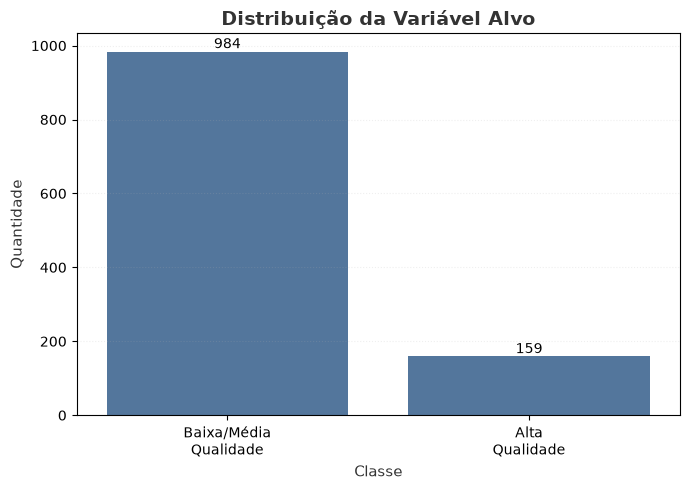

In [167]:
# ==========================================================
# GRÁFICO DA DISTRIBUIÇÃO DAS CLASSES
# ==========================================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="quality_label",
    color=COR_HISTOGRAMA
)

ax.set_xticklabels([
    "Baixa/Média\nQualidade",
    "Alta\nQualidade"
])

grafico_format(
    titulo="Distribuição da Variável Alvo",
    xlabel="Classe",
    ylabel="Quantidade",
    legenda=False
)

for barra in ax.patches:

    altura = barra.get_height()

    ax.annotate(
        f"{int(altura)}",
        (
            barra.get_x() + barra.get_width()/2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=10
    )

salvar_grafico("distribuicao_variavel_alvo")

plt.show()

### Conclusão da transformação da variável alvo

A transformação da variável **`quality`** em **`quality_label`** permitiu adequar o problema a uma tarefa de classificação binária, objetivo adotado neste estudo.

A análise da distribuição das classes demonstra a quantidade de amostras pertencentes a cada categoria e permite avaliar o nível de balanceamento da variável alvo antes do treinamento dos modelos.

Essa verificação é importante porque distribuições muito desbalanceadas podem influenciar o desempenho dos algoritmos supervisionados e a interpretação das métricas de avaliação. No conjunto de dados utilizado, observa-se que a classe **Baixa/Média Qualidade** possui maior quantidade de amostras em relação à classe **Alta Qualidade**, aspecto que será considerado na avaliação dos modelos.

## 5. Conhecendo a Base de Dados

Nesta etapa é realizada uma análise inicial da estrutura do conjunto de dados, com o objetivo de compreender sua composição antes das análises estatísticas e exploratórias.

Serão verificadas informações como a quantidade de registros e variáveis, os tipos de dados de cada coluna, a presença de valores ausentes e a organização geral da base.

Após a etapa de preparação dos dados, o conjunto passou a conter também a variável **`quality_label`**, criada a partir da variável original **`quality`** e utilizada como variável alvo na construção dos modelos supervisionados.

As informações obtidas nesta etapa servirão de base para as análises estatísticas, exploratórias e para a modelagem de Machine Learning apresentadas nas seções seguintes.

### 5.1 Dimensões da Base

Nesta etapa é verificada a quantidade de registros e de variáveis presentes no conjunto de dados.

In [168]:
#Dimensões da Base
df.shape

(1143, 14)

### 5.2 Visualização Inicial dos Dados

Uma inspeção inicial dos primeiros registros permite confirmar que o arquivo foi carregado corretamente e possibilita conhecer a estrutura das informações disponíveis.

In [169]:
# Mostra as 5 primeiras linhas da tabela, para conferirmos se carregou certo
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


### 5.3 Estrutura da Base

Nesta etapa são analisados os tipos das variáveis, a quantidade de valores não nulos e a estrutura geral do conjunto de dados.

In [170]:
#Conhecer a estrutura da base
#Responde: Quantas linhas? Quantas colunas? Quais os tipos de dados? Existem valores nulos?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  quality_label         1143 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 125.1 KB


### 5.4 Verificação de Valores Ausentes

A identificação de valores ausentes é uma etapa importante para avaliar a necessidade de tratamentos como imputação ou remoção de registros antes da construção dos modelos.

In [171]:
#Verificar se há valores nulos na base inteira 
#existem dados faltantes? é necessário tratamento?
df.isnull().sum().sum()

np.int64(0)

In [172]:
#qual coluna possui valores nulos?
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_label           0
dtype: int64

### 5.5 Verificação de Registros Duplicados

Nesta etapa é verificada a existência de registros duplicados que possam influenciar os resultados das análises ou comprometer o desempenho dos modelos de Machine Learning.

In [173]:
#Valores duplicados
df.duplicated().sum()

np.int64(0)

### 5.6 Verificação de Valores Únicos

Nesta etapa é analisada a quantidade de valores distintos presentes em cada variável. Essa verificação auxilia na compreensão da diversidade dos dados e permite identificar possíveis variáveis com baixa variabilidade, além de confirmar características específicas do conjunto de dados.

In [174]:
#verificar valores únicos
df.nunique()

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
quality_label              2
dtype: int64

In [175]:
# Conta quantos valores únicos (distintos) existem em cada coluna do DataFrame
valores_unicos = df.nunique()

# Exibe no console o resultado armazenado na variável
print(valores_unicos)

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
quality_label              2
dtype: int64


### Conclusão

A análise inicial da base de dados permitiu compreender sua estrutura e confirmar que o conjunto de dados está adequado para as etapas seguintes do projeto.

Após a preparação dos dados, a base passou a conter **1.143 registros e 14 variáveis**, sendo 11 características físico-químicas, a variável original **`quality`**, o identificador **`Id`** e a variável **`quality_label`**, criada para representar a variável alvo utilizada na modelagem.

Verificou-se que não existem valores ausentes e que todas as colunas estão armazenadas em formatos numéricos (`float64` e `int64`), facilitando a aplicação das técnicas estatísticas e dos algoritmos de Machine Learning.

Com a estrutura da base validada, as próximas etapas serão dedicadas à análise estatística descritiva e à análise exploratória das variáveis, permitindo compreender suas características e subsidiar a construção dos modelos preditivos.

## 6. Estatística Descritiva

A estatística descritiva tem como objetivo resumir as principais características numéricas das variáveis do conjunto de dados, permitindo compreender sua tendência central, dispersão e amplitude antes da realização das análises exploratórias e da construção dos modelos de Machine Learning.

Nesta etapa serão analisadas medidas como média, mediana, desvio padrão, valores mínimo e máximo, quartis e amplitude, fornecendo uma visão geral do comportamento das características físico-químicas dos vinhos.

### 6.1 Resumo Estatístico

Foi utilizada a função `describe()` do Pandas para calcular as principais estatísticas descritivas das variáveis numéricas da base de dados.

In [176]:
# ==========================================================
# 6.1 RESUMO ESTATÍSTICO DAS VARIÁVEIS
# ==========================================================

# Seleciona as variáveis que serão utilizadas na análise
# estatística, removendo apenas a coluna "Id", por se tratar
# de um identificador dos registros e não de uma variável de
# interesse para a análise.

colunas_analise = df.columns.drop("Id")


# ----------------------------------------------------------
# RESUMO ESTATÍSTICO
# ----------------------------------------------------------

# O método describe() calcula as principais medidas
# descritivas das variáveis numéricas:
#
# • quantidade de observações (count);
# • média (mean);
# • desvio padrão (std);
# • valor mínimo (min);
# • primeiro quartil (25%);
# • mediana (50%);
# • terceiro quartil (75%);
# • valor máximo (max).
#
# A transposição (.T) organiza a visualização com uma
# variável por linha, facilitando a leitura.
#
# Os valores são arredondados para duas casas decimais.

df[colunas_analise].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.31,1.75,4.60,7.10,7.90,9.10,15.90
volatile acidity,1143.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1143.0,0.27,0.20,0.00,0.09,0.25,0.42,1.00
residual sugar,1143.0,2.53,1.36,0.90,1.90,2.20,2.60,15.50
chlorides,1143.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1143.0,15.62,10.25,1.00,7.00,13.00,21.00,68.00
total sulfur dioxide,1143.0,45.91,32.78,6.00,21.00,37.00,61.00,289.00
density,1143.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1143.0,3.31,0.16,2.74,3.20,3.31,3.40,4.01
sulphates,1143.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


### Conclusão

A estatística descritiva permitiu obter uma visão geral das principais características numéricas das variáveis presentes no conjunto de dados.

As medidas de tendência central, dispersão e posição evidenciam que as variáveis físico-químicas apresentam escalas e amplitudes distintas, reforçando a importância de analisar cada atributo individualmente nas etapas seguintes do estudo.

A presença das variáveis **`quality`** e **`quality_label`** no resumo estatístico possibilita observar tanto a distribuição da nota original atribuída pelos especialistas quanto a composição da variável alvo criada para a modelagem.

As informações obtidas nesta etapa servem como base para a análise exploratória dos dados, na qual serão investigados aspectos como distribuição das variáveis, correlação entre atributos e identificação de valores extremos, contribuindo para uma compreensão mais aprofundada do conjunto de dados antes da construção dos modelos de Machine Learning.

## 7. Análise Exploratória dos Dados

A Análise Exploratória dos Dados (Exploratory Data Analysis – EDA) tem como objetivo compreender o comportamento das variáveis do conjunto de dados, identificar padrões, relações e possíveis inconsistências que possam influenciar o desempenho dos modelos de Machine Learning.

Nesta etapa serão investigados aspectos como a distribuição das variáveis, as relações lineares entre os atributos físico-químicos e a presença de valores extremos (outliers). Essas análises complementam a estatística descritiva apresentada anteriormente e fornecem subsídios para as etapas de pré-processamento e modelagem.

As análises serão conduzidas considerando as variáveis explicativas do conjunto de dados, preservando a variável alvo **`quality_label`** para utilização na construção e avaliação dos modelos supervisionados.

### 7.1 Distribuição das Variáveis

Nesta etapa serão analisadas as distribuições das variáveis explicativas por meio de **histogramas e curvas de densidade (KDE)**.

O objetivo é compreender o comportamento de cada variável quanto ao formato da distribuição, à presença de assimetria, ao grau de concentração dos valores e a possíveis indícios de valores extremos.

A análise visual será complementada pelo cálculo da média, mediana, coeficiente de assimetria e curtose. Essas medidas permitem avaliar, de maneira quantitativa, diferenças entre as distribuições antes das etapas de correlação, identificação de outliers e modelagem.

Para garantir consistência visual, será utilizada uma única cor nas barras dos histogramas, enquanto a curva KDE, a média e a mediana serão representadas por elementos visuais específicos.



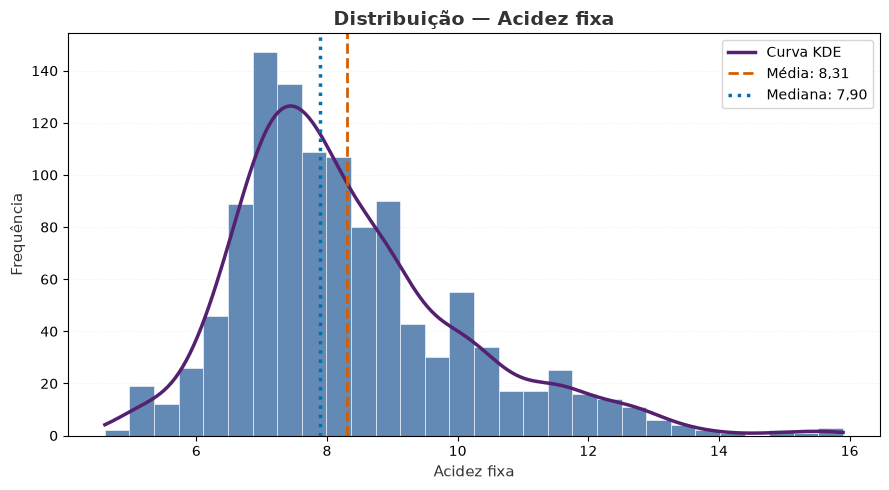

Análise da variável: Acidez fixa
------------------------------------------------------------
Média: 8.3111
Mediana: 7.9000
Assimetria: 1.0449
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 1.3846
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



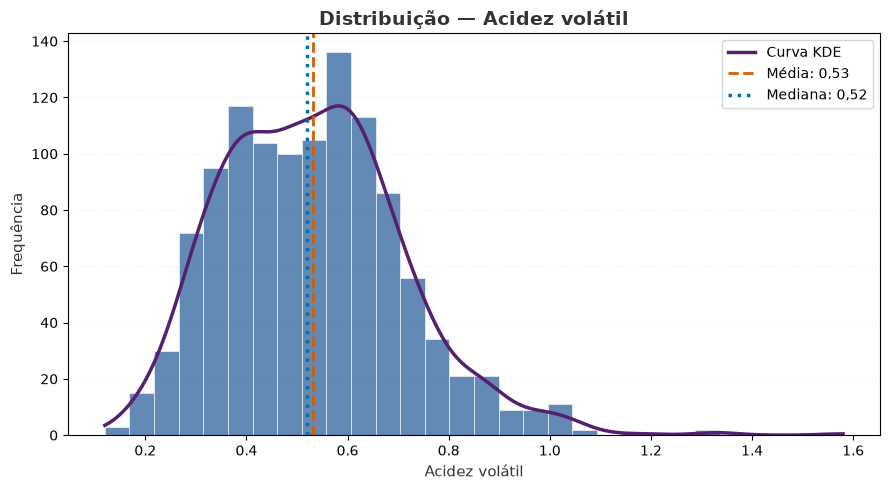

Análise da variável: Acidez volátil
------------------------------------------------------------
Média: 0.5313
Mediana: 0.5200
Assimetria: 0.6815
Classificação: Assimétrica à direita — intensidade moderada.
Curtose: 1.3755
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



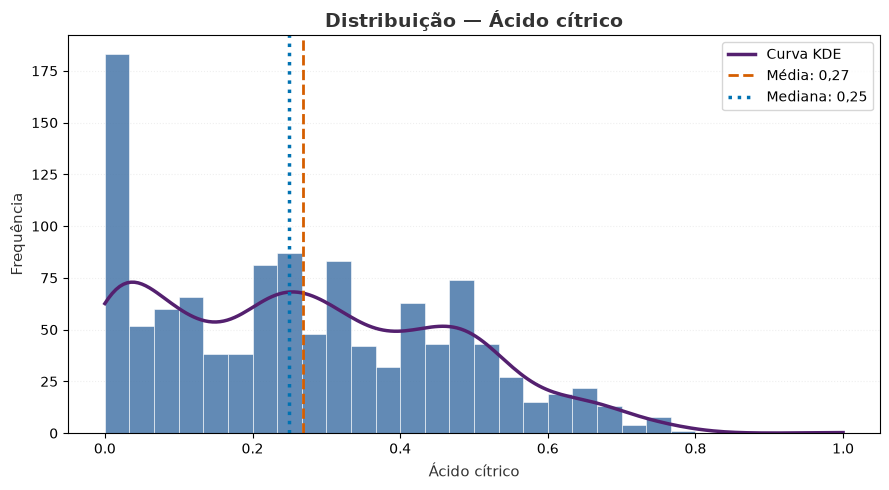

Análise da variável: Ácido cítrico
------------------------------------------------------------
Média: 0.2684
Mediana: 0.2500
Assimetria: 0.3716
Classificação: Aproximadamente simétrica.
Curtose: -0.7147
Classificação: Platicúrtica — distribuição mais achatada.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



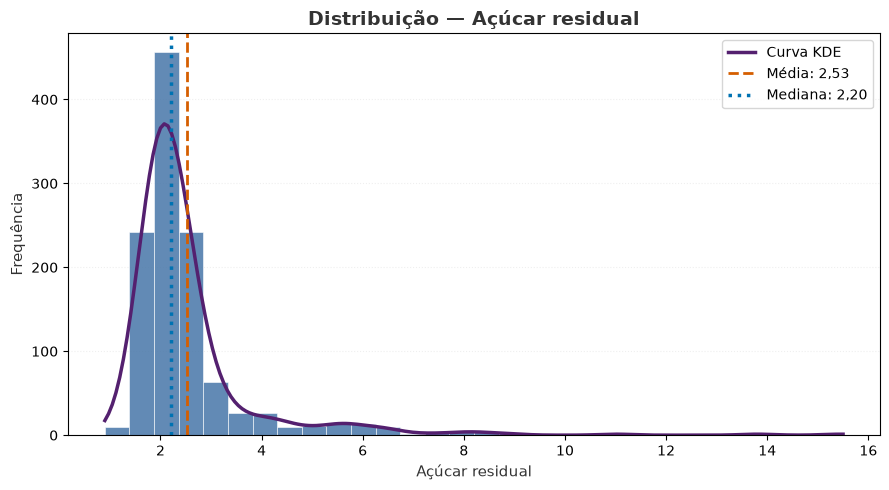

Análise da variável: Açúcar residual
------------------------------------------------------------
Média: 2.5322
Mediana: 2.2000
Assimetria: 4.3611
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 27.6754
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



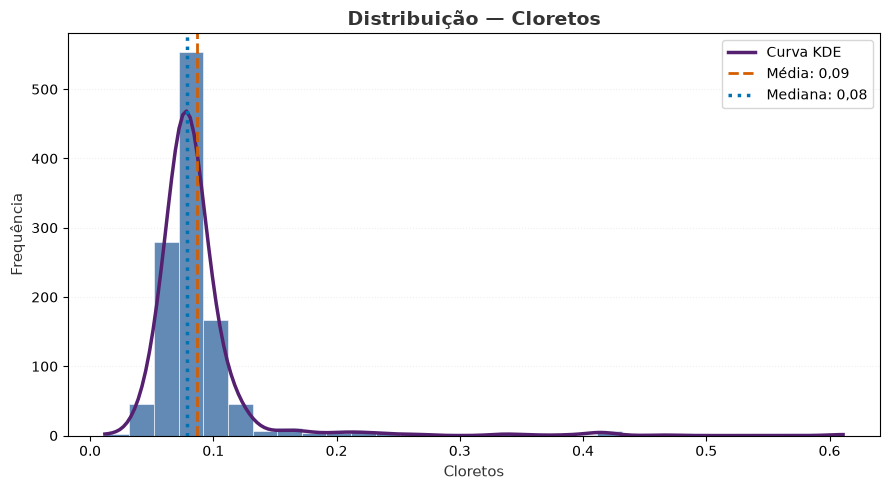

Análise da variável: Cloretos
------------------------------------------------------------
Média: 0.0869
Mediana: 0.0790
Assimetria: 6.0264
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 47.0783
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



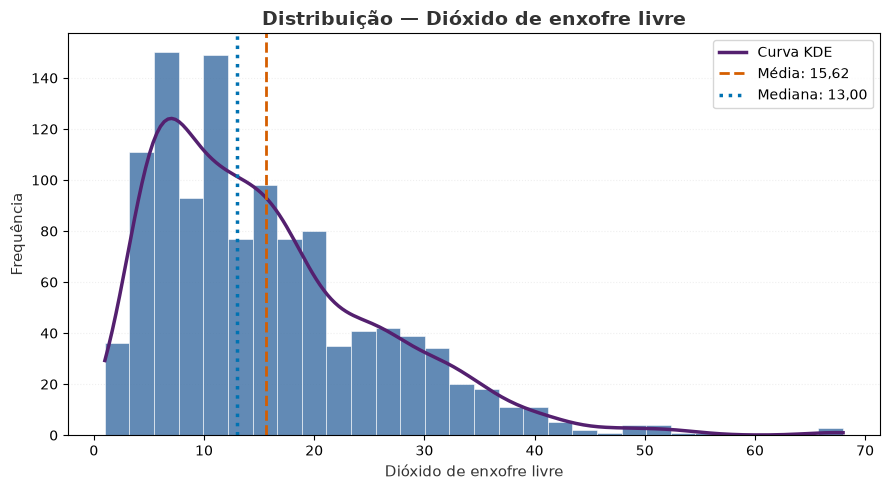

Análise da variável: Dióxido de enxofre livre
------------------------------------------------------------
Média: 15.6155
Mediana: 13.0000
Assimetria: 1.2313
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 1.9322
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



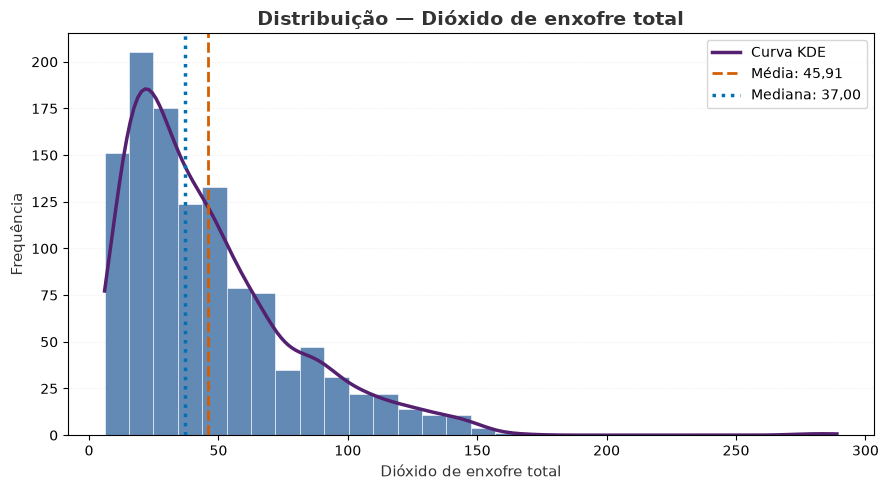

Análise da variável: Dióxido de enxofre total
------------------------------------------------------------
Média: 45.9147
Mediana: 37.0000
Assimetria: 1.6658
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 5.0987
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



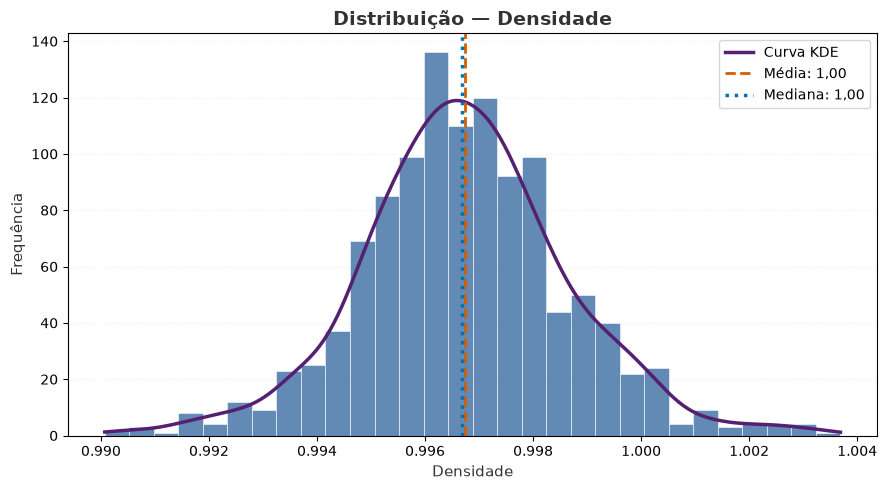

Análise da variável: Densidade
------------------------------------------------------------
Média: 0.9967
Mediana: 0.9967
Assimetria: 0.1024
Classificação: Aproximadamente simétrica.
Curtose: 0.8881
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



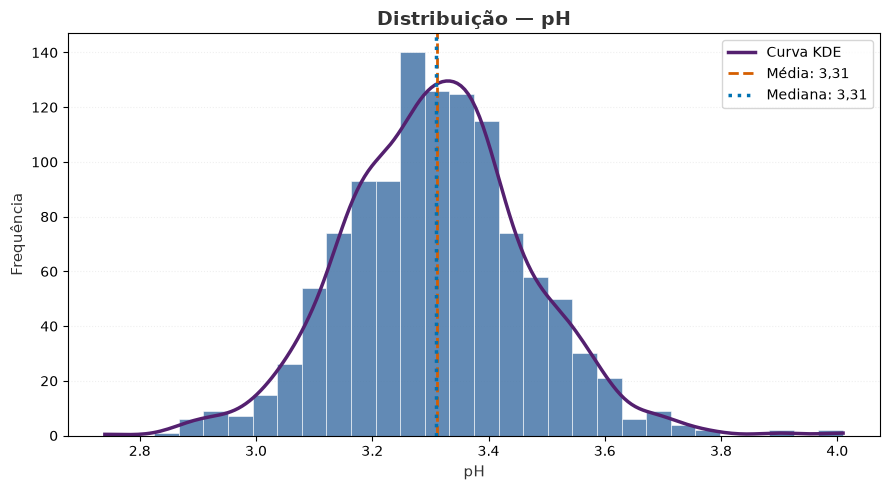

Análise da variável: pH
------------------------------------------------------------
Média: 3.3110
Mediana: 3.3100
Assimetria: 0.2211
Classificação: Aproximadamente simétrica.
Curtose: 0.9258
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



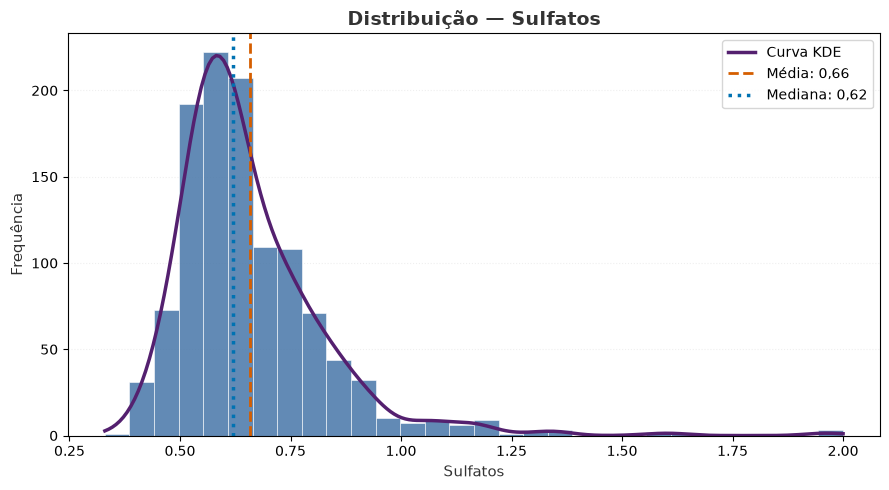

Análise da variável: Sulfatos
------------------------------------------------------------
Média: 0.6577
Mediana: 0.6200
Assimetria: 2.4973
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 12.0174
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



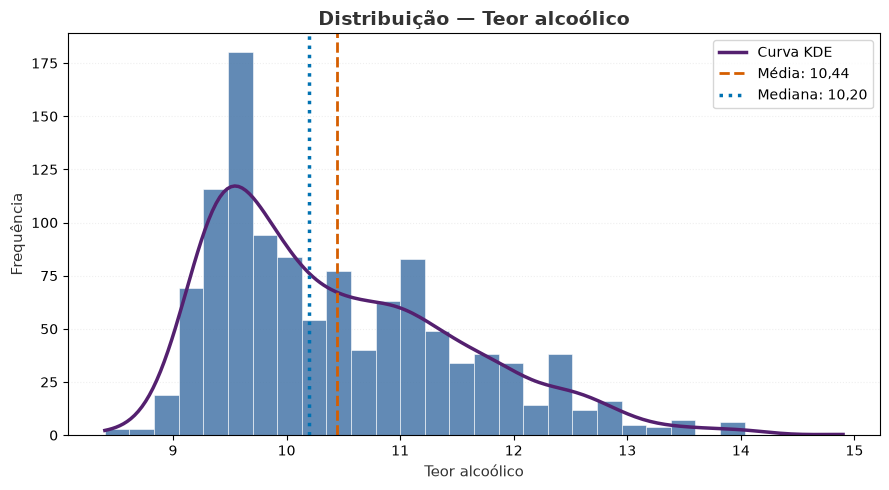

Análise da variável: Teor alcoólico
------------------------------------------------------------
Média: 10.4421
Mediana: 10.2000
Assimetria: 0.8633
Classificação: Assimétrica à direita — intensidade moderada.
Curtose: 0.2212
Classificação: Mesocúrtica ou próxima da Normal.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



In [177]:
# ==========================================================
# 7.1 DISTRIBUIÇÃO DAS VARIÁVEIS EXPLICATIVAS
# ==========================================================


# ----------------------------------------------------------
# SELEÇÃO DAS VARIÁVEIS
# ----------------------------------------------------------

# Seleciona somente as características físico-químicas
# que poderão ser utilizadas como variáveis explicativas
# durante a construção dos modelos.
#
# São excluídas:
#
# Id:
# identificador dos registros, sem significado preditivo.
#
# quality:
# nota original atribuída pelos especialistas e utilizada
# para criar a variável alvo binária.
#
# quality_label:
# variável alvo que será prevista pelos modelos.

features = df.drop(
    columns=[
        "Id",
        "quality",
        "quality_label"
    ],
    errors="ignore"
).columns


# ----------------------------------------------------------
# CONFIGURAÇÃO DO ANALISADOR
# ----------------------------------------------------------

# Cria o objeto responsável pela análise das distribuições,
# utilizando as configurações visuais definidas anteriormente
# no notebook.

analisador_distribuicao = AnalisadorDistribuicao(
    cor_histograma=COR_HISTOGRAMA,
    cor_kde=COR_KDE,
    cor_media=COR_MEDIA,
    cor_mediana=COR_MEDIANA,
    alpha_histograma=ALPHA_HISTOGRAMA,
    espessura_kde=ESPESSURA_KDE,
    bins=30
)


# ----------------------------------------------------------
# GERAÇÃO DOS HISTOGRAMAS
# ----------------------------------------------------------

# Percorre todas as variáveis explicativas selecionadas.
for coluna in features:

    # Obtém o nome da variável em português.
    # Caso não exista uma tradução no dicionário,
    # utiliza o nome original da coluna.
    nome_variavel = NOMES_VARIAVEIS.get(
        coluna,
        coluna
    )

    # Executa a análise completa da variável:
    #
    # - cria o histograma;
    # - adiciona a curva KDE;
    # - identifica média e mediana;
    # - calcula assimetria;
    # - calcula curtose;
    # - apresenta uma interpretação inicial.

    analisador_distribuicao.plotar_histograma(
        df=df,
        coluna=coluna,
        nome=nome_variavel
    )

In [178]:
# ==========================================================
# TABELA-RESUMO DA DISTRIBUIÇÃO DAS VARIÁVEIS
# ==========================================================

# Gera a tabela-resumo utilizando as mesmas variáveis
# explicativas analisadas nos histogramas.

df_resumo_distribuicao = (
    analisador_distribuicao.gerar_tabela_resumo(
        df=df,
        colunas=features,
        nomes_variaveis=NOMES_VARIAVEIS
    )
)

# Exibe a tabela no notebook.
display(df_resumo_distribuicao)

,Variável,Média,Mediana,Assimetria,Classificação da Assimetria,Curtose,Classificação da Curtose
0,Acidez fixa,8.31,7.90,1.04,Assimétrica à direita — intensidade elevada,1.38,Leptocúrtica — maior concentração ou caudas pe...
1,Acidez volátil,0.53,0.52,0.68,Assimétrica à direita — intensidade moderada,1.38,Leptocúrtica — maior concentração ou caudas pe...
2,Ácido cítrico,0.27,0.25,0.37,Aproximadamente simétrica,-0.71,Platicúrtica — distribuição mais achatada
3,Açúcar residual,2.53,2.20,4.36,Assimétrica à direita — intensidade elevada,27.68,Leptocúrtica — maior concentração ou caudas pe...
4,Cloretos,0.09,0.08,6.03,Assimétrica à direita — intensidade elevada,47.08,Leptocúrtica — maior concentração ou caudas pe...
5,Dióxido de enxofre livre,15.62,13.00,1.23,Assimétrica à direita — intensidade elevada,1.93,Leptocúrtica — maior concentração ou caudas pe...
6,Dióxido de enxofre total,45.91,37.00,1.67,Assimétrica à direita — intensidade elevada,5.10,Leptocúrtica — maior concentração ou caudas pe...
7,Densidade,1.00,1.00,0.10,Aproximadamente simétrica,0.89,Leptocúrtica — maior concentração ou caudas pe...
8,pH,3.31,3.31,0.22,Aproximadamente simétrica,0.93,Leptocúrtica — maior concentração ou caudas pe...
9,Sulfatos,0.66,0.62,2.50,Assimétrica à direita — intensidade elevada,12.02,Leptocúrtica — maior concentração ou caudas pe...


### Conclusão da análise da distribuição

A análise da distribuição evidenciou comportamentos distintos entre os atributos físico-químicos dos vinhos. Enquanto algumas variáveis apresentaram distribuição aproximadamente simétrica, outras exibiram assimetria moderada ou elevada, principalmente à direita, indicando maior concentração de observações em determinados intervalos e a presença de caudas mais longas.

Em relação à curtose, foram observadas distribuições mesocúrticas, leptocúrticas e platicúrticas, evidenciando diferentes níveis de concentração dos dados e comportamentos distintos das caudas das distribuições.

De forma geral, as análises gráficas e estatísticas indicam que as variáveis apresentam padrões de distribuição heterogêneos. Essas informações contribuem para a compreensão do comportamento dos dados e servirão de apoio às etapas seguintes de correlação, identificação de outliers, pré-processamento e modelagem de Machine Learning.

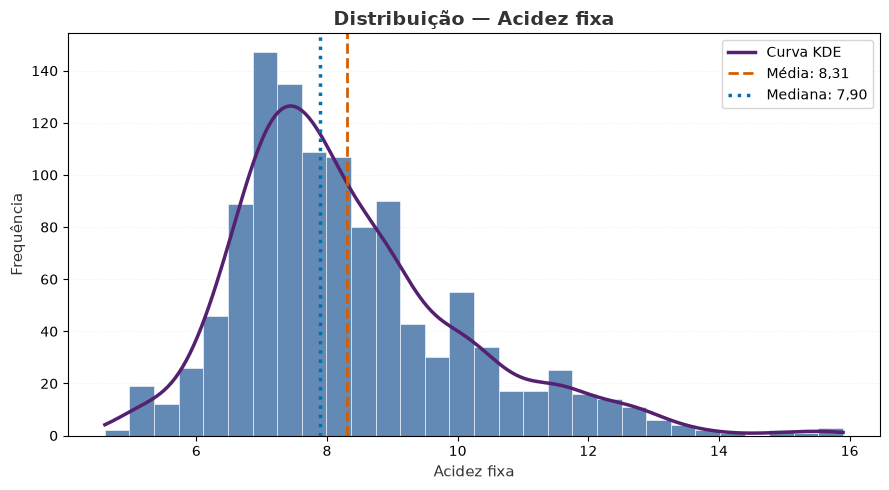

Análise da variável: Acidez fixa
------------------------------------------------------------
Média: 8.3111
Mediana: 7.9000
Assimetria: 1.0449
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 1.3846
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



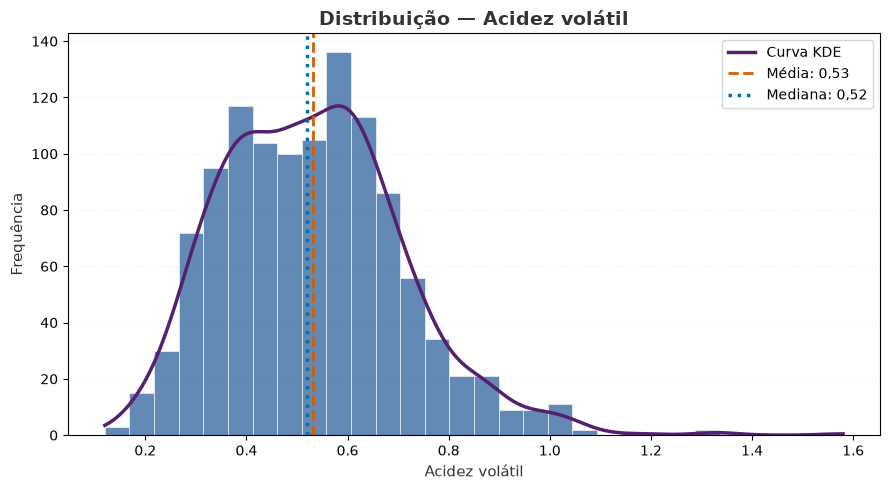

Análise da variável: Acidez volátil
------------------------------------------------------------
Média: 0.5313
Mediana: 0.5200
Assimetria: 0.6815
Classificação: Assimétrica à direita — intensidade moderada.
Curtose: 1.3755
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



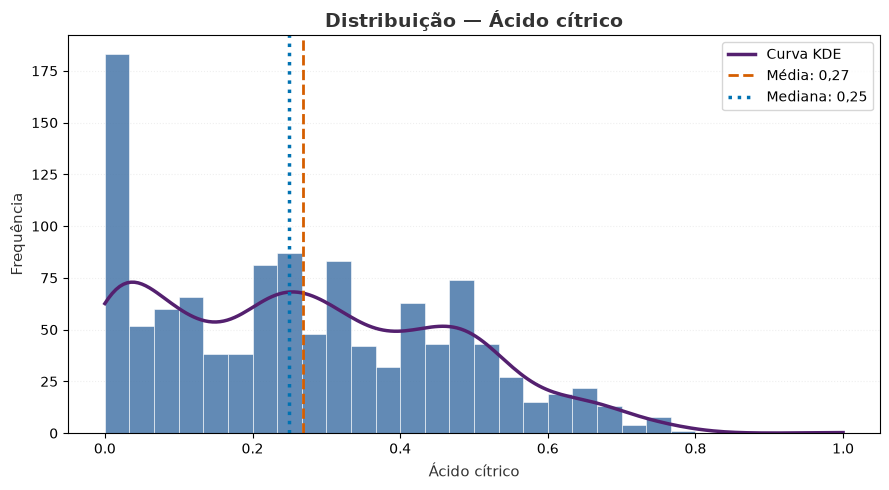

Análise da variável: Ácido cítrico
------------------------------------------------------------
Média: 0.2684
Mediana: 0.2500
Assimetria: 0.3716
Classificação: Aproximadamente simétrica.
Curtose: -0.7147
Classificação: Platicúrtica — distribuição mais achatada.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



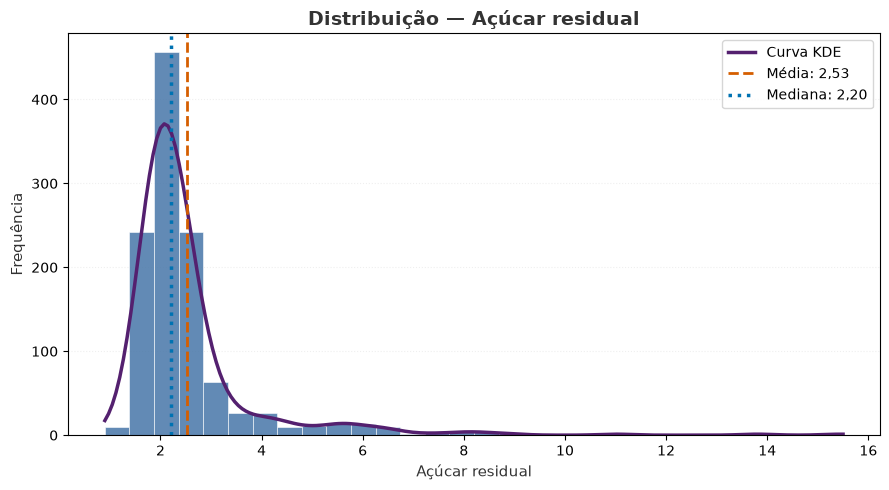

Análise da variável: Açúcar residual
------------------------------------------------------------
Média: 2.5322
Mediana: 2.2000
Assimetria: 4.3611
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 27.6754
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



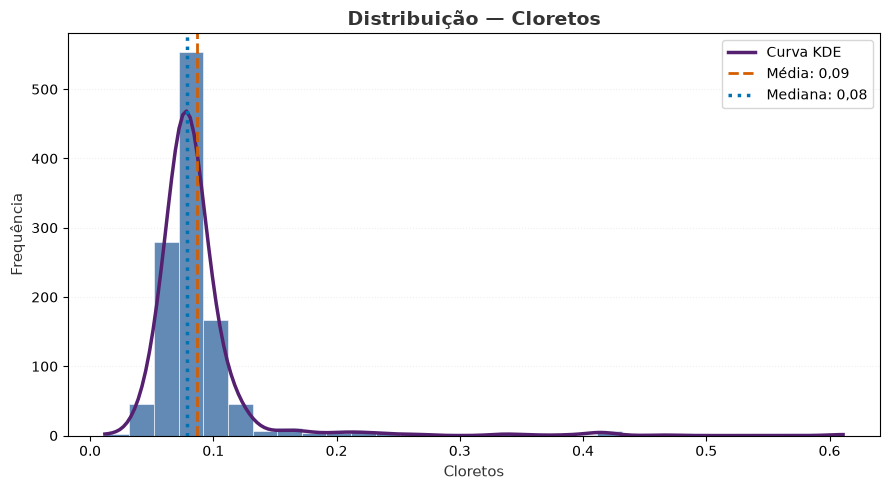

Análise da variável: Cloretos
------------------------------------------------------------
Média: 0.0869
Mediana: 0.0790
Assimetria: 6.0264
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 47.0783
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



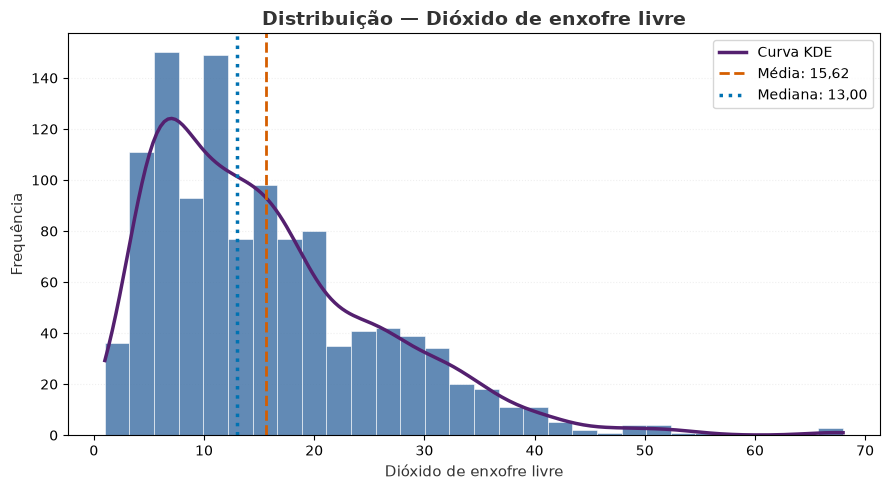

Análise da variável: Dióxido de enxofre livre
------------------------------------------------------------
Média: 15.6155
Mediana: 13.0000
Assimetria: 1.2313
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 1.9322
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



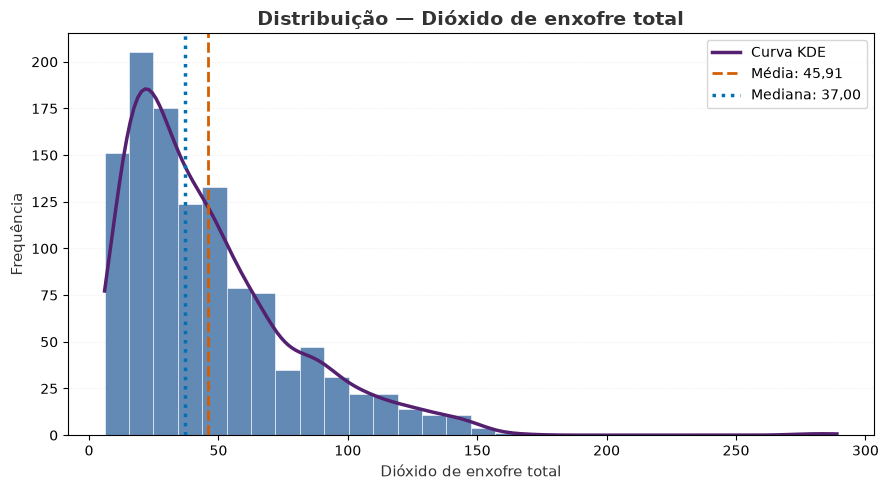

Análise da variável: Dióxido de enxofre total
------------------------------------------------------------
Média: 45.9147
Mediana: 37.0000
Assimetria: 1.6658
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 5.0987
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



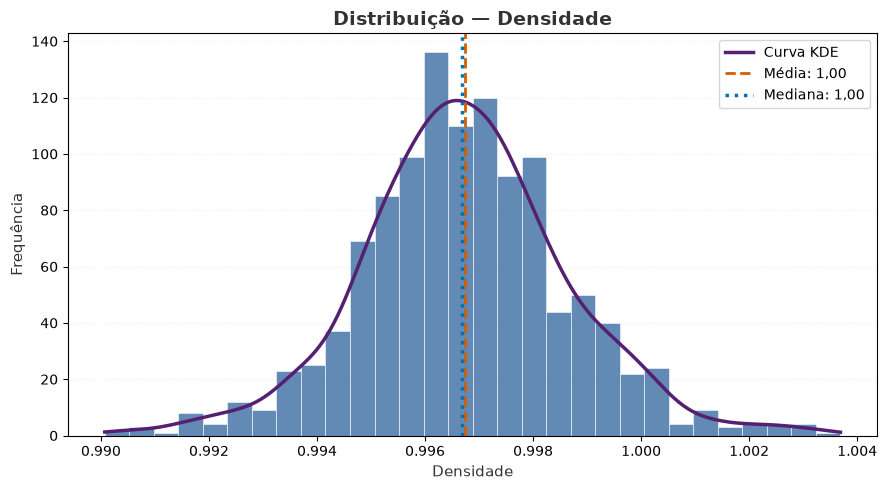

Análise da variável: Densidade
------------------------------------------------------------
Média: 0.9967
Mediana: 0.9967
Assimetria: 0.1024
Classificação: Aproximadamente simétrica.
Curtose: 0.8881
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



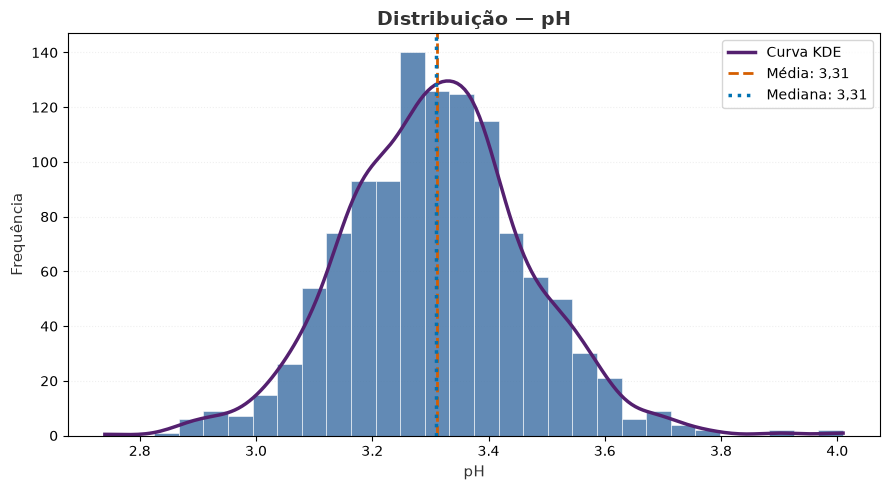

Análise da variável: pH
------------------------------------------------------------
Média: 3.3110
Mediana: 3.3100
Assimetria: 0.2211
Classificação: Aproximadamente simétrica.
Curtose: 0.9258
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



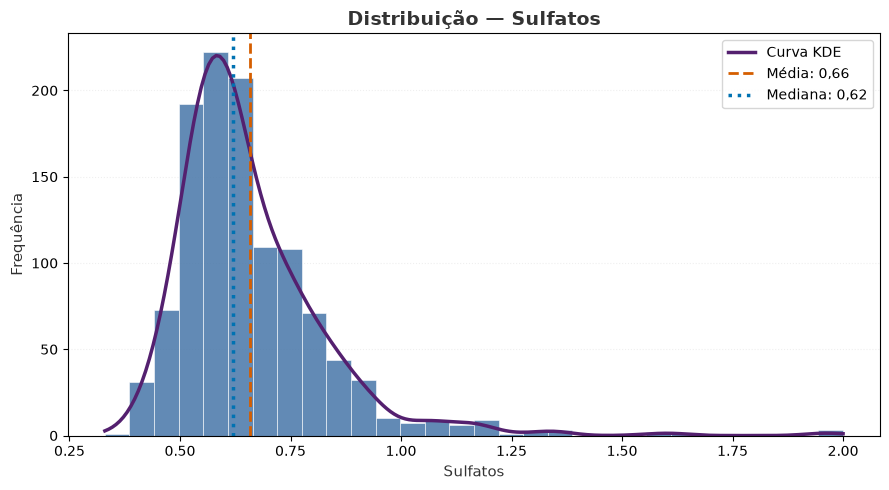

Análise da variável: Sulfatos
------------------------------------------------------------
Média: 0.6577
Mediana: 0.6200
Assimetria: 2.4973
Classificação: Assimétrica à direita — intensidade elevada.
Curtose: 12.0174
Classificação: Leptocúrtica — maior concentração ou caudas pesadas.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



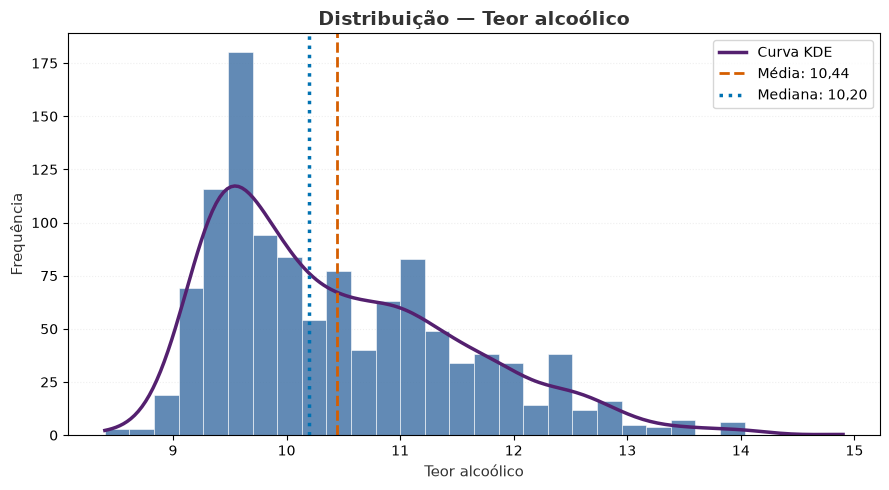

Análise da variável: Teor alcoólico
------------------------------------------------------------
Média: 10.4421
Mediana: 10.2000
Assimetria: 0.8633
Classificação: Assimétrica à direita — intensidade moderada.
Curtose: 0.2212
Classificação: Mesocúrtica ou próxima da Normal.
Observação: a curva KDE fornece um indício visual, mas não confirma sozinha uma distribuição Gaussiana.



In [179]:
# ==========================================================
# 7.1 DISTRIBUIÇÃO DAS VARIÁVEIS EXPLICATIVAS
# ==========================================================


# ----------------------------------------------------------
# SELEÇÃO DAS VARIÁVEIS
# ----------------------------------------------------------

# Seleciona somente as características físico-químicas
# que poderão ser utilizadas posteriormente nos modelos.
#
# São excluídas:
#
# Id:
# identificador do registro.
#
# quality:
# nota original utilizada posteriormente para construir
# a variável alvo.
#
# quality_label:
# variável alvo do problema de classificação.
features = df.drop(
    columns=[
        "Id",
        "quality",
        "quality_label"
    ],
    errors="ignore"
).columns


# ----------------------------------------------------------
# CONFIGURAÇÃO DO ANALISADOR
# ----------------------------------------------------------

# Cria o objeto responsável pela análise das distribuições.
#
# Todas as configurações visuais são provenientes
# do item 2.1.
analisador_distribuicao = AnalisadorDistribuicao(

    # Cor única das barras.
    cor_histograma=COR_HISTOGRAMA,

    # Cor da curva KDE.
    cor_kde=COR_KDE,

    # Cor utilizada para a média.
    cor_media=COR_MEDIA,

    # Cor utilizada para a mediana.
    cor_mediana=COR_MEDIANA,

    # Transparência das barras.
    alpha_histograma=ALPHA_HISTOGRAMA,

    # Espessura da curva KDE.
    espessura_kde=ESPESSURA_KDE,

    # Número de intervalos do histograma.
    bins=30
)


# ----------------------------------------------------------
# GERAÇÃO DOS HISTOGRAMAS
# ----------------------------------------------------------

# Percorre todas as variáveis explicativas selecionadas.
for coluna in features:

    # Obtém o nome da variável em português.
    #
    # Caso a variável não esteja cadastrada no dicionário,
    # será utilizado seu próprio nome original.
    nome_variavel = NOMES_VARIAVEIS.get(
        coluna,
        coluna
    )


    # Executa a análise completa:
    #
    # - cria o histograma com cor uniforme;
    # - adiciona a curva KDE;
    # - identifica média e mediana;
    # - calcula assimetria;
    # - calcula curtose;
    # - apresenta interpretação inicial da distribuição.
    analisador_distribuicao.plotar_histograma(
        df=df,
        coluna=coluna,
        nome=nome_variavel
    )

### Tabela-resumo da distribuição das variáveis

A tabela a seguir consolida as principais estatísticas obtidas durante a análise da distribuição das variáveis explicativas. São apresentados os valores de média, mediana, coeficiente de assimetria e curtose, acompanhados de suas respectivas classificações.

Essa síntese complementa a interpretação visual dos histogramas e das curvas de densidade (KDE), permitindo identificar, de forma objetiva, o comportamento de cada variável quanto à simetria e ao formato da distribuição..

In [180]:
# ==========================================================
# TABELA-RESUMO DA DISTRIBUIÇÃO DAS VARIÁVEIS
# ==========================================================

df_resumo_distribuicao = (
    analisador_distribuicao.gerar_tabela_resumo(
        df=df,
        colunas=features,
        nomes_variaveis=NOMES_VARIAVEIS
    )
)

display(df_resumo_distribuicao)

,Variável,Média,Mediana,Assimetria,Classificação da Assimetria,Curtose,Classificação da Curtose
0,Acidez fixa,8.31,7.90,1.04,Assimétrica à direita — intensidade elevada,1.38,Leptocúrtica — maior concentração ou caudas pe...
1,Acidez volátil,0.53,0.52,0.68,Assimétrica à direita — intensidade moderada,1.38,Leptocúrtica — maior concentração ou caudas pe...
2,Ácido cítrico,0.27,0.25,0.37,Aproximadamente simétrica,-0.71,Platicúrtica — distribuição mais achatada
3,Açúcar residual,2.53,2.20,4.36,Assimétrica à direita — intensidade elevada,27.68,Leptocúrtica — maior concentração ou caudas pe...
4,Cloretos,0.09,0.08,6.03,Assimétrica à direita — intensidade elevada,47.08,Leptocúrtica — maior concentração ou caudas pe...
5,Dióxido de enxofre livre,15.62,13.00,1.23,Assimétrica à direita — intensidade elevada,1.93,Leptocúrtica — maior concentração ou caudas pe...
6,Dióxido de enxofre total,45.91,37.00,1.67,Assimétrica à direita — intensidade elevada,5.10,Leptocúrtica — maior concentração ou caudas pe...
7,Densidade,1.00,1.00,0.10,Aproximadamente simétrica,0.89,Leptocúrtica — maior concentração ou caudas pe...
8,pH,3.31,3.31,0.22,Aproximadamente simétrica,0.93,Leptocúrtica — maior concentração ou caudas pe...
9,Sulfatos,0.66,0.62,2.50,Assimétrica à direita — intensidade elevada,12.02,Leptocúrtica — maior concentração ou caudas pe...


### Conclusão da análise da distribuição

A análise da distribuição das variáveis evidenciou comportamentos distintos entre os atributos físico-químicos dos vinhos. Enquanto algumas variáveis apresentaram distribuição aproximadamente simétrica, outras exibiram assimetria moderada ou elevada, principalmente à direita, indicando maior concentração de observações em determinados intervalos e a presença de caudas mais longas.

Em relação à curtose, observou-se a existência de distribuições mesocúrticas, leptocúrticas e platicúrticas, evidenciando diferentes níveis de concentração dos dados em torno da média e comportamentos distintos das caudas das distribuições.

De forma geral, as análises gráficas e estatísticas indicam que as variáveis apresentam padrões de distribuição heterogêneos, característica frequentemente observada em bases de dados reais. Essas informações contribuem para a compreensão do comportamento dos dados e servirão de apoio à interpretação dos resultados obtidos nas etapas de correlação, identificação de outliers e modelagem dos algoritmos de Machine Learning.

### 7.2 Análise de Correlação

Nesta etapa será analisada a relação linear entre as características físico-químicas dos vinhos e sua associação com a variável **`quality_label`**, utilizada como variável alvo na construção dos modelos de classificação.

O objetivo é compreender como as variáveis se relacionam entre si e identificar quais atributos apresentam maior associação linear com a variável alvo, contribuindo para a interpretação dos dados e para a etapa de modelagem.

Além disso, a análise possibilita identificar correlações elevadas entre variáveis explicativas, situação que pode indicar multicolinearidade e merece atenção durante a construção e interpretação dos modelos.

Será utilizado o coeficiente de correlação de **Pearson**, cujos valores variam entre **-1 e +1**:

- valores próximos de **+1** indicam forte associação linear positiva;
- valores próximos de **-1** indicam forte associação linear negativa;
- valores próximos de **0** indicam pouca ou nenhuma associação linear.

É importante destacar que correlação não implica causalidade. Além disso, o coeficiente de Pearson avalia apenas a intensidade da relação linear entre as variáveis, de modo que uma correlação baixa não significa necessariamente ausência de relação entre elas.

In [181]:
# ==========================================================
# 7.2 ANÁLISE DE CORRELAÇÃO
# ==========================================================

# Calcula a matriz de correlação de Pearson utilizando
# a função auxiliar definida anteriormente.
#
# A análise considera as características físico-químicas
# e a variável "quality", correspondente à nota original
# atribuída pelos especialistas.
#
# A variável "quality_label" não é utilizada nesta etapa,
# pois representa uma transformação binária criada
# especificamente para a modelagem.
#
# Também é excluída a coluna "Id", por se tratar apenas
# de um identificador dos registros.

matriz_correlacao = calcular_matriz_correlacao(df)


# ----------------------------------------------------------
# MATRIZ DE CORRELAÇÃO
# ----------------------------------------------------------

# Exibe a matriz de correlação de Pearson com os coeficientes
# arredondados para duas casas decimais, facilitando a
# leitura e a interpretação dos resultados.

display(
    matriz_correlacao.round(2)
)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.00,-0.25,0.67,0.17,0.11,-0.16,-0.11,0.68,-0.69,0.17,-0.08,0.12
volatile acidity,-0.25,1.00,-0.54,-0.01,0.06,-0.00,0.08,0.02,0.22,-0.28,-0.20,-0.41
citric acid,0.67,-0.54,1.00,0.18,0.25,-0.06,0.04,0.38,-0.55,0.33,0.11,0.24
residual sugar,0.17,-0.01,0.18,1.00,0.07,0.17,0.19,0.38,-0.12,0.02,0.06,0.02
chlorides,0.11,0.06,0.25,0.07,1.00,0.02,0.05,0.21,-0.28,0.37,-0.23,-0.12
free sulfur dioxide,-0.16,-0.00,-0.06,0.17,0.02,1.00,0.66,-0.05,0.07,0.03,-0.05,-0.06
total sulfur dioxide,-0.11,0.08,0.04,0.19,0.05,0.66,1.00,0.05,-0.06,0.03,-0.19,-0.18
density,0.68,0.02,0.38,0.38,0.21,-0.05,0.05,1.00,-0.35,0.14,-0.49,-0.18
pH,-0.69,0.22,-0.55,-0.12,-0.28,0.07,-0.06,-0.35,1.00,-0.19,0.23,-0.05
sulphates,0.17,-0.28,0.33,0.02,0.37,0.03,0.03,0.14,-0.19,1.00,0.09,0.26


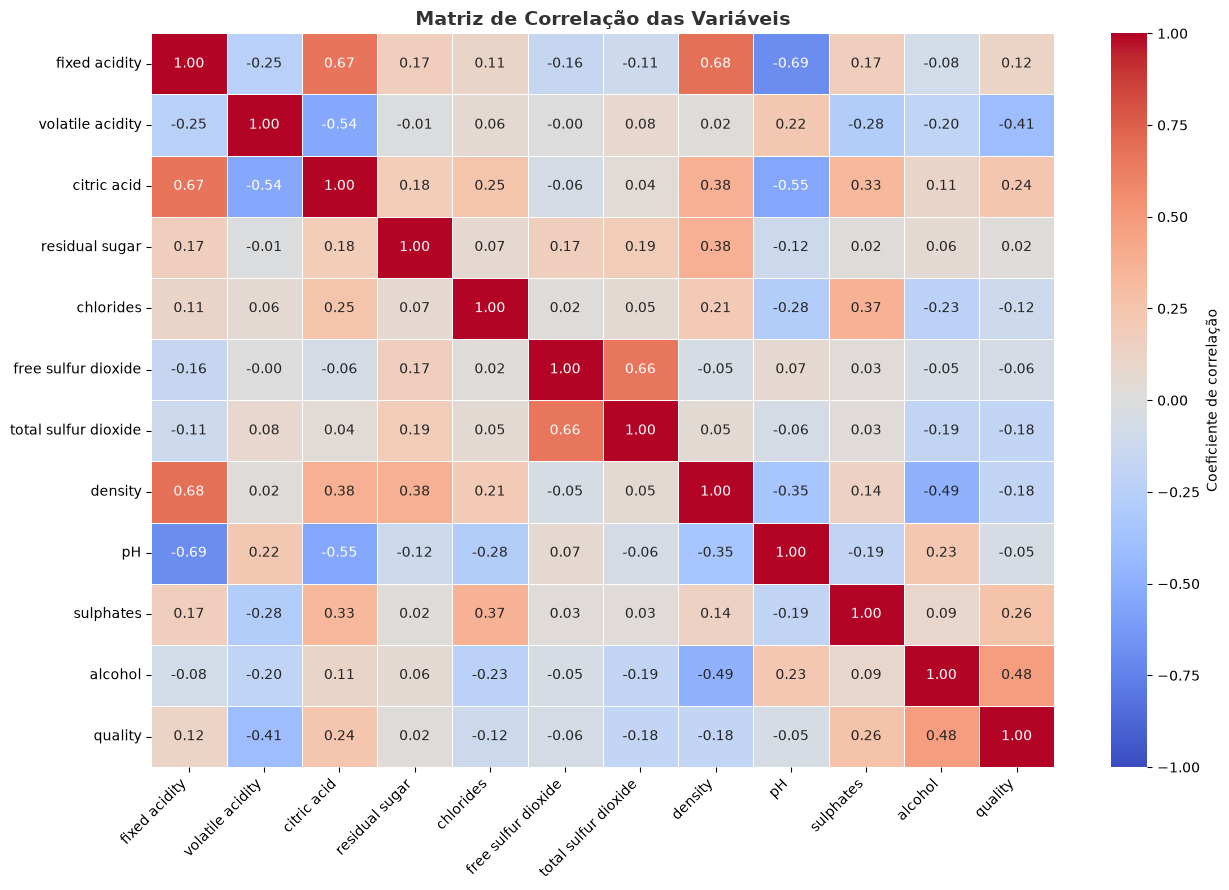

In [182]:
# ==========================================================
# VISUALIZAÇÃO DA MATRIZ DE CORRELAÇÃO
# ==========================================================

# Gera a representação gráfica da matriz de correlação
# por meio de um heatmap.
#
# O mapa de calor facilita a identificação visual da
# intensidade e da direção das correlações entre as
# variáveis analisadas.
#
# Correlações positivas são representadas por uma tonalidade,
# enquanto correlações negativas são representadas por outra,
# permitindo localizar rapidamente associações fortes,
# moderadas ou fracas entre os atributos.

plotar_matriz_correlacao(
    matriz_correlacao.round(2)
)

### 7.3 Análise Visual de Outliers

Será realizada a análise visual de possíveis **outliers** nas variáveis explicativas por meio de boxplots.

O boxplot permite observar a distribuição dos valores, sua região central, dispersão e possíveis observações que se encontram mais afastadas do comportamento predominante de cada variável.

Para manter a consistência visual com os demais gráficos da Análise Exploratória de Dados, os boxplots utilizam a identidade visual definida anteriormente e os nomes das variáveis são apresentados em português.

É importante destacar que a identificação visual de um outlier **não implica sua remoção automática**. Esses valores podem representar observações legítimas do conjunto de dados e devem ser avaliados considerando sua origem, frequência e possível impacto sobre os modelos de Machine Learning.

O objetivo desta etapa é, portanto, **identificar e compreender visualmente a presença de valores extremos**, preservando os dados originais para posterior avaliação.

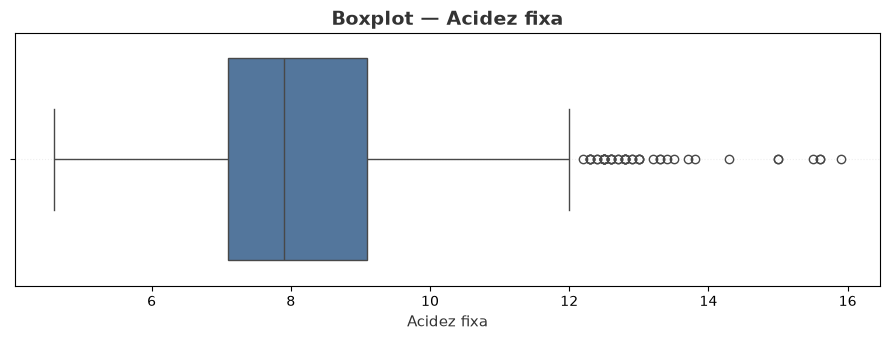

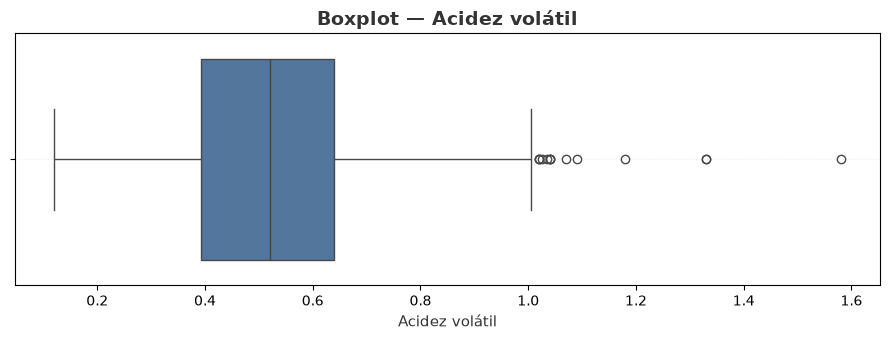

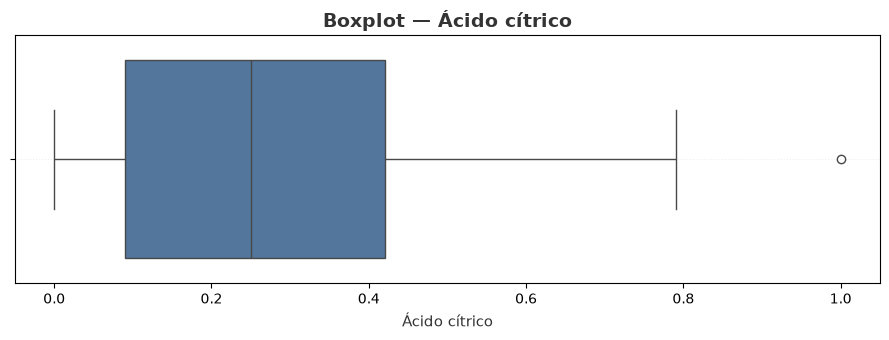

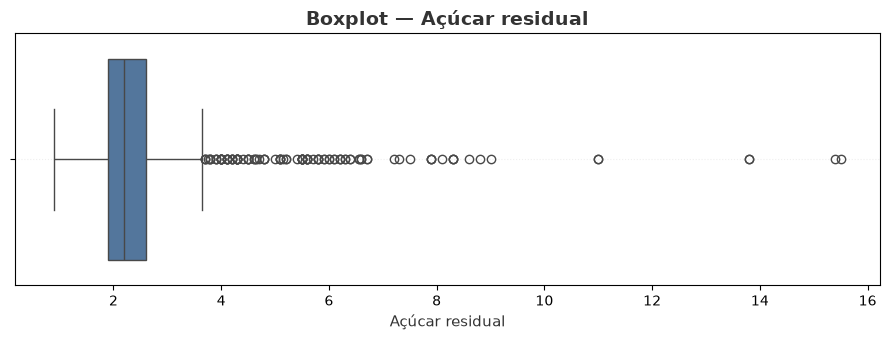

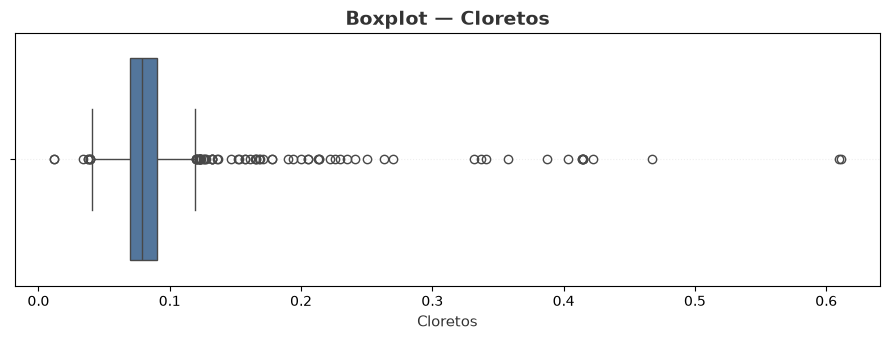

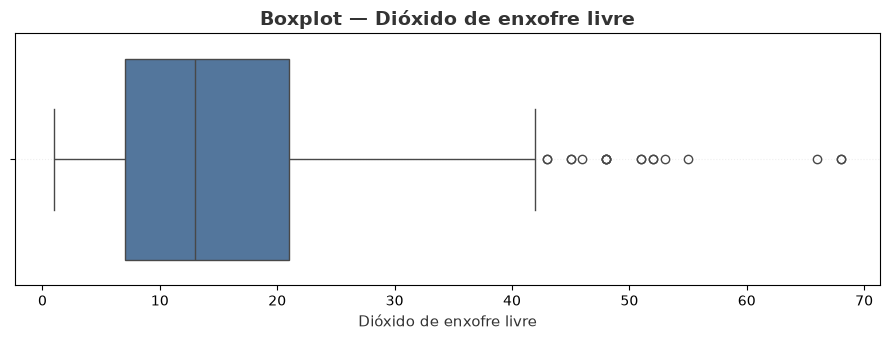

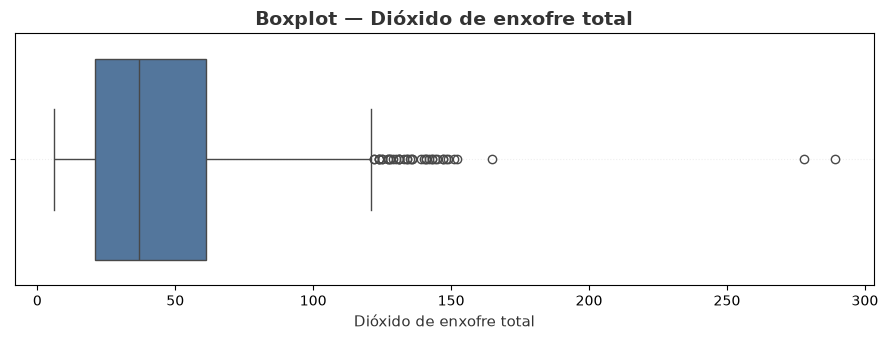

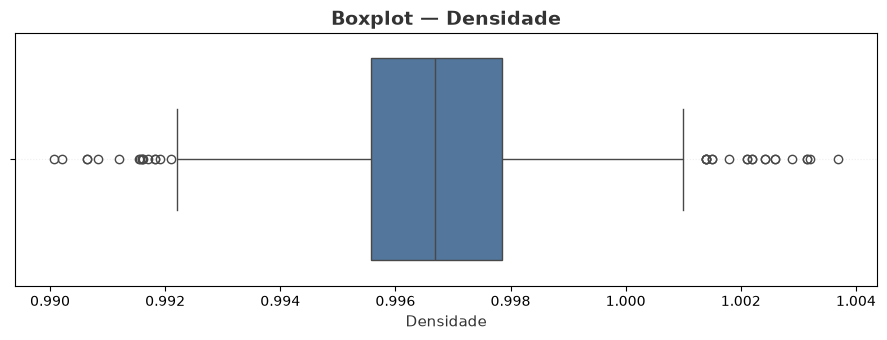

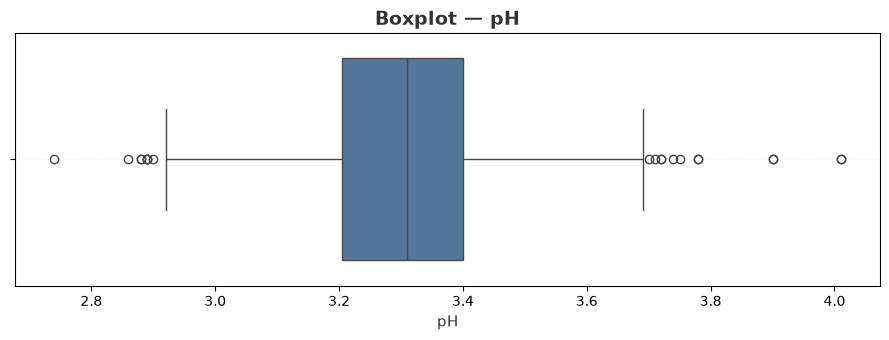

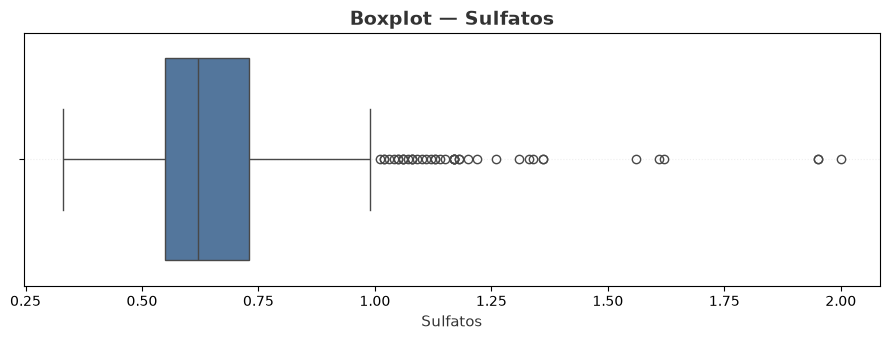

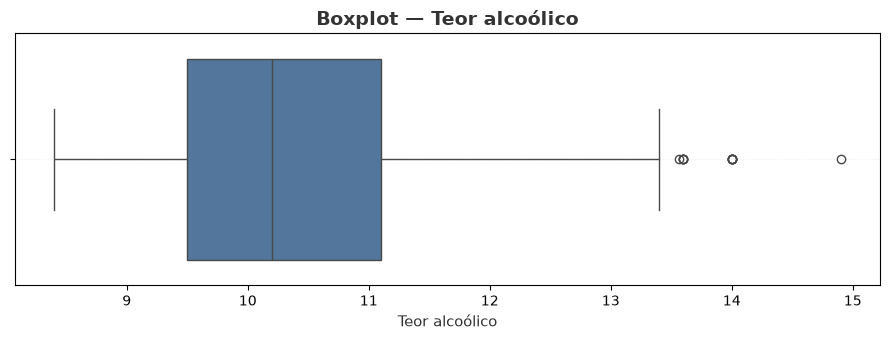

In [183]:
# ==========================================================
# 7.3 ANÁLISE VISUAL DE OUTLIERS
# ==========================================================


# ----------------------------------------------------------
# SELEÇÃO DAS VARIÁVEIS EXPLICATIVAS
# ----------------------------------------------------------

# Reutiliza a lista de variáveis explicativas definida
# anteriormente no item 7.1.
#
# Essa lista contém apenas as características
# físico-químicas utilizadas na modelagem, excluindo:
#
# - Id: identificador dos registros;
# - quality: nota original atribuída pelos especialistas;
# - quality_label: variável alvo da classificação.

colunas_outliers = features


# ----------------------------------------------------------
# GERAÇÃO DOS BOXPLOTS
# ----------------------------------------------------------

# Percorre todas as variáveis explicativas selecionadas.
for coluna in colunas_outliers:

    # Obtém o nome da variável em português.
    #
    # Caso não exista uma tradução cadastrada,
    # utiliza o nome original da coluna.
    nome_variavel = NOMES_VARIAVEIS.get(
        coluna,
        coluna
    )

    # Cria uma nova figura para cada variável.
    plt.figure(
        figsize=(9, 3.5)
    )

    # Cria o boxplot para visualizar:
    #
    # - mediana;
    # - quartis;
    # - amplitude interquartil;
    # - possíveis valores extremos.
    #
    # A cor utilizada foi definida anteriormente
    # para manter a identidade visual do projeto.
    sns.boxplot(
        x=df[coluna],
        color=COR_BOXPLOT
    )

    # Aplica a formatação visual padronizada.
    grafico_format(
        titulo=f"Boxplot — {nome_variavel}",
        xlabel=nome_variavel,
        ylabel=""
    )

    # Salva o gráfico caso o salvamento automático
    # esteja habilitado.
    salvar_grafico(
        f"boxplot_{coluna}"
    )

    # Exibe o gráfico.
    plt.show()

#### Quantificação dos outliers

Além da análise visual por meio dos boxplots, foi realizada a identificação quantitativa dos valores extremos utilizando o método do **Intervalo Interquartil (Interquartile Range – IQR)**.

Para cada variável explicativa foram calculados:

- Primeiro quartil (Q1);
- Terceiro quartil (Q3);
- Intervalo Interquartil (IQR = Q3 − Q1);
- Limites inferior e superior para identificação de outliers;
- Quantidade e percentual de observações classificadas como outliers.

Essa análise complementa a inspeção visual e permite comparar a ocorrência de valores extremos entre as diferentes variáveis do conjunto de dados.

In [184]:
# ==========================================================
# QUANTIFICAÇÃO DOS OUTLIERS PELO MÉTODO IQR
# ==========================================================

resultado_outliers = []

# Percorre todas as variáveis explicativas
for coluna in features:

    # Calcula os quartis
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)

    # Calcula o intervalo interquartil
    iqr = q3 - q1

    # Define os limites inferior e superior
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Identifica os outliers
    quantidade = (
        (
            (df[coluna] < limite_inferior)
            |
            (df[coluna] > limite_superior)
        )
    ).sum()

    percentual = (
        quantidade / len(df)
    ) * 100

    resultado_outliers.append({

        "Variável":
            NOMES_VARIAVEIS.get(coluna, coluna),

        "Outliers":
            quantidade,

        "Percentual (%)":
            round(percentual, 2)

    })

# Cria a tabela
df_outliers = pd.DataFrame(resultado_outliers)

# Ordena pelas variáveis com maior quantidade de outliers
df_outliers = df_outliers.sort_values(
    by="Outliers",
    ascending=False
)

display(df_outliers)

,Variável,Outliers,Percentual (%)
3,Açúcar residual,110,9.62
4,Cloretos,77,6.74
0,Acidez fixa,44,3.85
9,Sulfatos,43,3.76
6,Dióxido de enxofre total,40,3.50
7,Densidade,36,3.15
8,pH,20,1.75
5,Dióxido de enxofre livre,18,1.57
1,Acidez volátil,14,1.22
10,Teor alcoólico,12,1.05


### Resultado da análise

A análise quantitativa dos outliers, realizada pelo método do Intervalo Interquartil (IQR), evidenciou que todas as variáveis explicativas apresentam algum nível de valores extremos, porém com frequências distintas.

As maiores concentrações de outliers foram observadas nas variáveis **Açúcar residual** (110 observações; **9,62%**), **Cloretos** (77 observações; **6,74%**), **Acidez fixa** (44 observações; **3,85%**) e **Sulfatos** (43 observações; **3,76%**). Em contrapartida, **Ácido cítrico** apresentou apenas **1** observação classificada como outlier (**0,09%**), indicando uma distribuição mais homogênea em relação às demais variáveis.

Os boxplots permitiram confirmar visualmente a presença desses valores extremos, enquanto a quantificação pelo método IQR possibilitou identificar sua frequência em cada variável.

É importante destacar que, neste conjunto de dados, a presença de outliers não indica necessariamente erros de medição ou inconsistências. Por se tratar de características físico-químicas de vinhos, esses valores podem representar variações naturais do processo produtivo e, portanto, sua remoção deve ser cuidadosamente avaliada para evitar a perda de informações relevantes.

## 8. Pré-processamento dos Dados


Nesta etapa será realizado o pré-processamento dos dados, com o objetivo de preparar o conjunto para o treinamento dos modelos de Machine Learning.

Serão executadas as seguintes atividades:

1. análise da necessidade de engenharia de atributos;
2. verificação e tratamento de dados faltantes, caso existam;
3. preparação das variáveis explicativas e da variável alvo;
4. divisão estratificada dos dados em treino e teste;
5. padronização das variáveis numéricas.


### 8.1 Engenharia de Atributos (Feature Engineering)

A engenharia de atributos (*Feature Engineering*) consiste na criação de novas variáveis a partir das informações existentes, com o objetivo de fornecer aos modelos de Machine Learning atributos que possam melhorar seu desempenho preditivo.

A variável alvo binária **`quality_label`** já foi criada anteriormente a partir da variável original **`quality`**, permitindo transformar o problema em uma tarefa de classificação supervisionada:

- **0:** vinho de baixa ou média qualidade;
- **1:** vinho de alta qualidade.

Após a Análise Exploratória de Dados (EDA), verificou-se que as variáveis físico-químicas originais já representam adequadamente as características dos vinhos. Por esse motivo, não serão criadas novas variáveis explicativas adicionais nesta etapa.

Essa decisão preserva a interpretação dos atributos originais e reduz o risco de introduzir informações redundantes ou sem justificativa técnica.


In [185]:
# ==========================================================
# 8.1 Engenharia de Atributos (Feature Engineering)
# ==========================================================

# Como não foram identificadas oportunidades de criação de
# novas variáveis com justificativa técnica, serão utilizadas
# as mesmas características físico-químicas definidas
# anteriormente para o treinamento dos modelos.

resumo_feature_engineering = pd.DataFrame({
    "Etapa": [
        "Criação de novas variáveis"
    ],
    "Decisão": [
        "Não realizada"
    ],
    "Justificativa": [
        "As variáveis originais representam adequadamente as características físico-químicas dos vinhos."
    ]
})

# Exibe o resumo da decisão adotada.
display(resumo_feature_engineering)

,Etapa,Decisão,Justificativa
0,Criação de novas variáveis,Não realizada,As variáveis originais representam adequadamen...


#### Conclusão

Após a avaliação do conjunto de dados, optou-se por não realizar a criação de novas variáveis nesta etapa do projeto.

A decisão foi fundamentada na análise exploratória, que demonstrou que as características físico-químicas disponíveis já representam adequadamente o problema de classificação proposto.

Dessa forma, os modelos de Machine Learning serão treinados utilizando as variáveis originais do conjunto de dados, permitindo que seu desempenho seja avaliado sem a introdução de atributos adicionais.

### 8.2 Tratamento de Dados Faltantes
Antes de iniciar o pré-processamento e a construção dos modelos de Machine Learning, é importante verificar a existência de valores faltantes (missing values) no conjunto de dados.

A presença de dados ausentes pode comprometer o desempenho dos modelos e, dependendo da quantidade e da importância das variáveis afetadas, pode exigir técnicas de tratamento, como remoção de registros ou imputação de valores.

Nesta etapa, será realizada a verificação da quantidade de valores nulos em cada variável do dataset.

Pergunta que estamos respondendo:

*Existe alguma informação faltando?*

In [186]:
# ==========================================================
# 8.2 Tratamento de Dados Faltantes
# ==========================================================

# Verifica a quantidade de valores faltantes (NaN) em cada variável do conjunto de dados.
# A função isnull() identifica os valores ausentes e sum() contabiliza a quantidade por coluna.
valores_faltantes = df.isnull().sum()

# Calcula o percentual de valores faltantes em relação ao total de registros.
# Essa informação facilita avaliar se será necessário algum tratamento.
percentual_faltantes = (valores_faltantes / len(df)) * 100

# Cria uma tabela resumo contendo a quantidade e o percentual de valores faltantes.
resumo_faltantes = pd.DataFrame({
    'Valores Faltantes': valores_faltantes,
    'Percentual (%)': percentual_faltantes.round(2)
})

# Exibe o resumo dos valores faltantes.
display(resumo_faltantes)

,Valores Faltantes,Percentual (%)
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


In [187]:
# ==========================================================
# 8.2 Tratamento de Dados Faltantes
# ==========================================================

# Verifica a existência de valores faltantes (NaN) em cada variável do conjunto de dados.
# A função isna() identifica os valores ausentes e sum() contabiliza a quantidade em cada coluna.
valores_faltantes = df.isna().sum()

# Calcula o percentual de valores faltantes em relação ao total de registros.
# Esse indicador auxilia na decisão sobre a necessidade de aplicar técnicas de tratamento,
# como imputação ou remoção de registros.
percentual_faltantes = (valores_faltantes / len(df)) * 100

# Consolida os resultados em um DataFrame para facilitar a visualização e interpretação.
resumo_faltantes = pd.DataFrame({
    "Valores Faltantes": valores_faltantes,
    "Percentual (%)": percentual_faltantes.round(2)
})

# Exibe a tabela resumo com a quantidade e o percentual de valores faltantes por variável.
display(resumo_faltantes)

,Valores Faltantes,Percentual (%)
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


#### Conclusão

A análise identificou que nenhuma das variáveis apresenta valores faltantes. Dessa forma, não foi necessário aplicar técnicas de tratamento, como imputação ou remoção de registros, permitindo que o conjunto de dados seguisse para as próximas etapas de pré-processamento sem necessidade de ajustes.

### 8.3 Preparação das Variáveis para Modelagem

Após verificar a integridade do conjunto de dados, o próximo passo consiste em preparar as informações que serão utilizadas pelos algoritmos de Machine Learning.

Nesta etapa, os dados são separados em dois conjuntos:

- **Variáveis explicativas (features):** representam as características físico-químicas dos vinhos e serão utilizadas pelos modelos para identificar padrões e realizar previsões.
- **Variável alvo (target):** corresponde à coluna `quality_label`, que contém a classificação binária da qualidade do vinho e representa o resultado que o modelo deverá aprender a prever.

Também são removidas as colunas `Id` e `quality`, pois elas não devem participar do treinamento:

- **Id:** é apenas um identificador do registro, não possuindo significado preditivo.
- **quality:** corresponde à nota original atribuída pelos especialistas e foi utilizada para gerar a variável `quality_label`. Sua utilização durante o treinamento provocaria **vazamento de dados (*Data Leakage*)**, permitindo que o modelo tivesse acesso à resposta correta antes da previsão.

Embora essa etapa não altere os dados, ela faz parte do **pré-processamento**, pois organiza o conjunto de dados na estrutura esperada pelas bibliotecas de Machine Learning. Dessa forma, os algoritmos passam a receber apenas as informações necessárias para aprender a relação entre as características do vinho e sua classificação de qualidade.

In [188]:
# ==========================================================
# 8.3 Separação das Variáveis Explicativas e da Variável Alvo
# ==========================================================

# Seleciona as características físico-químicas que serão utilizadas
# pelos modelos para prever a qualidade dos vinhos.
#
# São removidas:
# - Id: identificador do registro, sem valor preditivo;
# - quality: nota original utilizada na criação da variável alvo;
# - quality_label: variável que o modelo deverá prever.
caracteristicas_vinho = df.drop(
    columns=["Id", "quality", "quality_label"]
)

# Define a variável alvo do problema de classificação.
classe_qualidade = df["quality_label"]

# Calcula a quantidade de registros pertencentes a cada classe.
quantidade_por_classe = classe_qualidade.value_counts()

# Cria uma tabela-resumo compacta com as informações essenciais
# para confirmar a separação dos dados.
resumo_separacao = pd.DataFrame({
    "Informação": [
        "Quantidade de registros",
        "Variáveis explicativas",
        "Baixa/Média Qualidade",
        "Alta Qualidade"
    ],
    "Resultado": [
        len(caracteristicas_vinho),
        caracteristicas_vinho.shape[1],
        quantidade_por_classe.get(0, 0),
        quantidade_por_classe.get(1, 0)
    ]
})

# Exibe apenas o resumo essencial da etapa.
display(resumo_separacao)

,Informação,Resultado
0,Quantidade de registros,1143
1,Variáveis explicativas,11
2,Baixa/Média Qualidade,984
3,Alta Qualidade,159


#### Conclusão

Ao final desta etapa, o conjunto de dados foi preparado para as próximas fases da modelagem.

Foram criados dois conjuntos principais:

- **`caracteristicas_vinho`**: contendo exclusivamente as variáveis explicativas que serão utilizadas pelos algoritmos de Machine Learning;
- **`classe_qualidade`**: contendo a variável alvo que deverá ser prevista pelos modelos.

Além disso, foi gerado um resumo da separação dos dados, confirmando a quantidade de registros, o número de variáveis explicativas e a distribuição das classes da variável alvo.

Com essa organização, os dados passam a estar estruturados na forma esperada pelas bibliotecas de Machine Learning, permitindo que a próxima etapa realize a divisão entre os conjuntos de treino e teste.

### 8.4 Divisão dos Dados em Treino e Teste



Após separar as variáveis explicativas da variável alvo, os dados serão divididos em dois conjuntos:

- **Conjunto de treino:** utilizado pelos modelos para aprender os padrões existentes nas características físico-químicas dos vinhos;
- **Conjunto de teste:** reservado para avaliar o desempenho dos modelos em dados que não foram utilizados durante o treinamento.

Neste projeto, serão destinados **80% dos registros para treinamento** e **20% para teste**.

Como a variável alvo apresenta uma quantidade significativamente maior de vinhos classificados como baixa/média qualidade, será utilizada a **estratificação**. Esse procedimento preserva, aproximadamente, a proporção das classes nos conjuntos de treino e teste.

Também será definida uma semente aleatória por meio do parâmetro `random_state`. Isso garante a reprodutibilidade do experimento, permitindo obter a mesma divisão sempre que o código for executado nas mesmas condições.

In [189]:
# ==========================================================
# 8.4 Divisão dos Dados em Treino e Teste
# ==========================================================

# Importa a função responsável por dividir o conjunto
# de dados em treino e teste.
from sklearn.model_selection import train_test_split


# Divide as variáveis explicativas e a variável alvo
# em conjuntos de treino e teste.
#
# test_size=0.20:
# reserva 20% dos registros para teste e utiliza os
# 80% restantes para treinamento dos modelos.
#
# random_state=42:
# garante que a divisão seja reproduzida exatamente
# da mesma forma em futuras execuções.
#
# stratify=classe_qualidade:
# preserva a proporção das classes nos conjuntos
# de treino e teste, evitando distorções na distribuição.
(
    caracteristicas_treino,
    caracteristicas_teste,
    classe_treino,
    classe_teste
) = train_test_split(
    caracteristicas_vinho,
    classe_qualidade,
    test_size=0.20,
    random_state=42,
    stratify=classe_qualidade
)


# Cria um resumo da divisão realizada.
resumo_divisao = pd.DataFrame({
    "Conjunto": [
        "Treino",
        "Teste"
    ],
    "Quantidade de Registros": [
        len(caracteristicas_treino),
        len(caracteristicas_teste)
    ],
    "Percentual da Base": [
        f"{len(caracteristicas_treino) / len(caracteristicas_vinho):.1%}",
        f"{len(caracteristicas_teste) / len(caracteristicas_vinho):.1%}"
    ]
})

# Exibe o resumo da divisão dos dados.
display(resumo_divisao)

,Conjunto,Quantidade de Registros,Percentual da Base
0,Treino,914,80.0%
1,Teste,229,20.0%


#### Conclusão

A divisão dos dados foi realizada preservando a proporção das classes entre os conjuntos de treino e teste. Essa estratégia permite treinar os modelos com uma amostra representativa dos dados e avaliar seu desempenho em registros não utilizados durante o treinamento, reduzindo o risco de superestimar sua capacidade de generalização.

### 8.5 Padronização das Variáveis Numéricas

As características físico-químicas presentes no conjunto de dados possuem escalas distintas. Por exemplo, enquanto a variável **`density`** apresenta valores próximos de 1, a variável **`total sulfur dioxide`** pode assumir valores superiores a 200.

Essa diferença de escala pode influenciar o desempenho de alguns algoritmos de Machine Learning, especialmente aqueles que utilizam medidas de distância ou realizam otimização por gradiente.

Para minimizar esse efeito, foi aplicada a **padronização** das variáveis numéricas utilizando o **`StandardScaler`**, disponível na biblioteca **Scikit-Learn**.

A padronização transforma cada variável para uma distribuição com:

- média aproximadamente igual a **0**;
- desvio-padrão aproximadamente igual a **1**.

O ajuste do padronizador foi realizado **exclusivamente sobre o conjunto de treino**. Em seguida, os mesmos parâmetros foram aplicados ao conjunto de teste.

Esse procedimento evita o **vazamento de dados (Data Leakage)**, garantindo que nenhuma informação do conjunto de teste seja utilizada durante o treinamento dos modelos.

In [190]:
# ==========================================================
# 8.5 Padronização das Variáveis Numéricas
# ==========================================================

# Importa o StandardScaler, responsável por padronizar
# as variáveis numéricas.
from sklearn.preprocessing import StandardScaler


# Cria o objeto responsável pela padronização.
padronizador = StandardScaler()


# Ajusta o padronizador utilizando exclusivamente
# o conjunto de treino e aplica a transformação.
#
# fit():
# aprende a média e o desvio-padrão de cada variável.
#
# transform():
# utiliza esses parâmetros para padronizar os dados.
#
# fit_transform():
# executa as duas etapas de uma única vez.
caracteristicas_treino_padronizadas = padronizador.fit_transform(
    caracteristicas_treino
)


# Aplica ao conjunto de teste exatamente a mesma
# transformação aprendida durante o treinamento.
#
# É utilizado apenas transform(), evitando que
# informações do conjunto de teste sejam utilizadas
# para recalcular média e desvio-padrão
# (Data Leakage).
caracteristicas_teste_padronizadas = padronizador.transform(
    caracteristicas_teste
)


# Converte os resultados novamente para DataFrames,
# preservando os nomes das colunas e os índices
# dos conjuntos originais.
caracteristicas_treino_padronizadas = pd.DataFrame(
    caracteristicas_treino_padronizadas,
    columns=caracteristicas_treino.columns,
    index=caracteristicas_treino.index
)

caracteristicas_teste_padronizadas = pd.DataFrame(
    caracteristicas_teste_padronizadas,
    columns=caracteristicas_teste.columns,
    index=caracteristicas_teste.index
)


# Cria uma tabela comparando as estatísticas
# antes e após a padronização do conjunto de treino.
#
# O objetivo é demonstrar o efeito da transformação,
# evidenciando que as variáveis passaram a apresentar
# média próxima de zero e desvio-padrão próximo de um.
comparacao_padronizacao = pd.DataFrame({
    "Média (Antes)": caracteristicas_treino.mean().round(2),
    "Média (Depois)": caracteristicas_treino_padronizadas.mean().round(2),
    "Desvio-Padrão (Antes)": caracteristicas_treino.std().round(2),
    "Desvio-Padrão (Depois)": caracteristicas_treino_padronizadas.std().round(2)
})


# Exibe a comparação das estatísticas
# antes e após a padronização.
display(comparacao_padronizacao)

,Média (Antes),Média (Depois),Desvio-Padrão (Antes),Desvio-Padrão (Depois)
fixed acidity,8.32,-0.0,1.76,1.0
volatile acidity,0.53,-0.0,0.17,1.0
citric acid,0.27,-0.0,0.19,1.0
residual sugar,2.55,0.0,1.44,1.0
chlorides,0.09,-0.0,0.04,1.0
free sulfur dioxide,15.25,-0.0,9.97,1.0
total sulfur dioxide,45.28,-0.0,33.22,1.0
density,1.00,0.0,0.00,1.0
pH,3.31,-0.0,0.16,1.0
sulphates,0.66,0.0,0.17,1.0


#### Conclusão

A comparação das estatísticas antes e após a padronização confirma que a transformação foi realizada com sucesso.

Observa-se que todas as variáveis passaram a apresentar média próxima de zero e desvio-padrão igual a um, atendendo ao comportamento esperado do `StandardScaler`. Dessa forma, as diferenças de escala entre as características físico-químicas foram eliminadas, evitando que variáveis com magnitudes maiores exerçam influência desproporcional durante o treinamento dos modelos.

Além disso, a padronização foi ajustada exclusivamente com os dados de treino e posteriormente aplicada ao conjunto de teste, preservando a integridade do processo de modelagem e evitando o vazamento de dados (*Data Leakage*).

Com essa etapa concluída, os dados encontram-se adequadamente preparados para o treinamento e a avaliação dos modelos de classificação.

## 9. Modelagem de Machine Learning


Nesta etapa será aplicada a abordagem de **Aprendizado Supervisionado**, na qual os algoritmos são treinados utilizando exemplos previamente rotulados.

Neste projeto:

- as **variáveis de entrada** correspondem às características físico-químicas dos vinhos;
- a **variável alvo** é `quality_label`, que informa se o vinho pertence à classe de baixa/média qualidade (`0`) ou alta qualidade (`1`).

Como o objetivo é prever uma classe conhecida a partir de dados rotulados, o problema caracteriza-se como uma **classificação supervisionada**.

Serão treinados e comparados três algoritmos de classificação: **Regressão Logística**, utilizada como modelo de referência (*baseline*); **Random Forest**, capaz de representar relações não lineares entre as variáveis; e **K-Nearest Neighbors (KNN)**, algoritmo baseado na proximidade entre as observações.

A utilização de modelos com diferentes estratégias de aprendizado permitirá comparar seus desempenhos e avaliar qual abordagem apresenta maior capacidade de classificação da qualidade dos vinhos neste conjunto de dados.


### 9.1 Regressão Logística

A Regressão Logística é um algoritmo supervisionado de classificação utilizado para estimar a probabilidade de ocorrência de uma determinada classe.

Apesar do nome, trata-se de um modelo de **classificação**, sendo amplamente empregado em problemas binários, como o deste projeto, em que o objetivo é prever se um vinho pertence à classe de baixa/média qualidade ou alta qualidade.

Neste estudo, a Regressão Logística será utilizada como modelo de referência (*baseline*), permitindo comparar posteriormente seu desempenho com algoritmos mais complexos.

In [191]:
# ==========================================================
# 9.1 Regressão Logística
# ==========================================================

# Importa o algoritmo de Regressão Logística.
from sklearn.linear_model import LogisticRegression


# Cria o modelo de Regressão Logística.
#
# random_state:
# garante a reprodutibilidade dos resultados.
#
# max_iter:
# aumenta o número máximo de iterações para
# garantir a convergência do algoritmo.
modelo_regressao_logistica = LogisticRegression(
    random_state=42,
    max_iter=1000
)


# Treina o modelo utilizando o conjunto de treino
# previamente padronizado.
modelo_regressao_logistica.fit(
    caracteristicas_treino_padronizadas,
    classe_treino
)


# Realiza as previsões utilizando
# o conjunto de teste.
previsoes_regressao_logistica = modelo_regressao_logistica.predict(
    caracteristicas_teste_padronizadas
)


# Exibe a quantidade de previsões realizadas.
print(
    f"Quantidade de previsões realizadas: {len(previsoes_regressao_logistica)}"
)

Quantidade de previsões realizadas: 229


#### Conclusão

O modelo de Regressão Logística foi treinado com sucesso utilizando o conjunto de treino padronizado e realizou previsões sobre o conjunto de teste.

As previsões obtidas serão utilizadas na próxima etapa para avaliar o desempenho do modelo por meio de métricas de classificação, permitindo posteriormente sua comparação com outros algoritmos de Machine Learning.

### 9.2 Random Forest

O Random Forest é um algoritmo supervisionado de classificação baseado na combinação de múltiplas árvores de decisão.

Assim como a Regressão Logística, ele aprende a partir de exemplos previamente rotulados, relacionando as características físico-químicas dos vinhos à classe de qualidade conhecida durante o treinamento.

Cada árvore é treinada utilizando uma amostra diferente do conjunto de dados e um subconjunto aleatório de variáveis explicativas. Ao final, a classificação é determinada pela votação entre todas as árvores da floresta.

Esse algoritmo apresenta como principais vantagens a capacidade de capturar relações não lineares entre as variáveis, a robustez em relação a ruídos e a menor propensão ao sobreajuste (*overfitting*) quando comparado a uma única árvore de decisão.

Neste projeto, o Random Forest será utilizado para comparar seu desempenho com a Regressão Logística, permitindo avaliar se um modelo baseado em árvores oferece melhores resultados para a classificação da qualidade dos vinhos.

In [192]:
# ==========================================================
# 9.2 Random Forest
# ==========================================================

# Importa o algoritmo Random Forest.
from sklearn.ensemble import RandomForestClassifier


# Cria o modelo Random Forest.
#
# n_estimators:
# define a quantidade de árvores que compõem a floresta.
#
# random_state:
# garante que os resultados possam ser reproduzidos
# em futuras execuções.
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# Treina o modelo utilizando o conjunto de treino.
#
# Embora o Random Forest não necessite obrigatoriamente
# de dados padronizados, será utilizado o mesmo conjunto
# preparado anteriormente para manter a consistência
# do pipeline de modelagem.
modelo_random_forest.fit(
    caracteristicas_treino_padronizadas,
    classe_treino
)


# Realiza as previsões utilizando
# o conjunto de teste.
previsoes_random_forest = modelo_random_forest.predict(
    caracteristicas_teste_padronizadas
)

In [193]:
# Confirma a quantidade de previsões realizadas pelo Random Forest.
print(
    f"Quantidade de previsões realizadas: {len(previsoes_random_forest)}"
)

Quantidade de previsões realizadas: 229


#### Conclusão

O modelo Random Forest foi treinado utilizando o conjunto de treino e realizou previsões sobre os registros do conjunto de teste.

As previsões obtidas serão utilizadas posteriormente na etapa de avaliação, permitindo comparar seu desempenho com os demais algoritmos de classificação utilizados neste projeto.

### 9.3 K-Nearest Neighbors (KNN)

O **K-Nearest Neighbors (KNN)** é um algoritmo de aprendizado supervisionado utilizado em problemas de classificação.

Diferentemente da Regressão Logística e do Random Forest, o KNN realiza a classificação com base na **proximidade entre as observações**. Para classificar um novo registro, o algoritmo identifica os `k` exemplos mais próximos no conjunto de treinamento e atribui a classe predominante entre esses vizinhos.

Neste projeto, cada vinho é representado por suas características físico-químicas. Dessa forma, o KNN compara essas características com as dos vinhos presentes no conjunto de treinamento para determinar se o novo registro deve ser classificado como:

- **0:** vinho de baixa/média qualidade;
- **1:** vinho de alta qualidade.

Como o KNN utiliza medidas de distância, diferenças de escala entre as variáveis podem influenciar diretamente o resultado. Por esse motivo, serão utilizados os conjuntos previamente padronizados com o `StandardScaler` na etapa 8.5.

Inicialmente será utilizado `k = 5`, valor padrão do `KNeighborsClassifier`. Posteriormente, técnicas como validação cruzada e ajuste de hiperparâmetros poderão ser empregadas para avaliar outros valores de `k`.

In [194]:
# ==========================================================
# Função Reutilizável para Treinamento e Predição
# ==========================================================

def treinar_e_prever_modelo(
    modelo,
    caracteristicas_treino_modelo,
    classe_treino_modelo,
    caracteristicas_teste_modelo
):
    """
    Treina um modelo de classificação e realiza previsões
    sobre o conjunto de teste.

    Parâmetros
    ----------
    modelo:
        Modelo de Machine Learning que será treinado.

    caracteristicas_treino_modelo:
        Variáveis explicativas utilizadas no treinamento.

    classe_treino_modelo:
        Variável alvo utilizada no treinamento.

    caracteristicas_teste_modelo:
        Variáveis explicativas utilizadas para realizar
        as previsões.

    Retorno
    -------
    previsoes:
        Classes previstas pelo modelo para o conjunto
        de teste.
    """

    # Treina o modelo utilizando os dados de treinamento.
    modelo.fit(
        caracteristicas_treino_modelo,
        classe_treino_modelo
    )

    # Realiza as previsões sobre o conjunto de teste.
    previsoes = modelo.predict(
        caracteristicas_teste_modelo
    )

    # Retorna as previsões para que possam ser utilizadas
    # posteriormente na avaliação do modelo.
    return previsoes

In [195]:
# ==========================================================
# 9.3 K-Nearest Neighbors (KNN)
# ==========================================================

# Importa o algoritmo K-Nearest Neighbors
# para problemas de classificação.
from sklearn.neighbors import KNeighborsClassifier


# Define a quantidade de vizinhos que será utilizada
# pelo algoritmo.
#
# O valor é armazenado em uma variável separada para
# facilitar sua reutilização e eventual alteração
# em etapas posteriores do projeto.
quantidade_vizinhos_knn = 5


# Cria o modelo KNN.
#
# n_neighbors:
# define quantos vizinhos mais próximos serão considerados
# para determinar a classe de cada nova observação.
modelo_knn = KNeighborsClassifier(
    n_neighbors=quantidade_vizinhos_knn
)


# Treina o modelo e realiza as previsões utilizando
# a função reutilizável criada anteriormente.
#
# Como o KNN utiliza medidas de distância, são utilizados
# os conjuntos previamente padronizados.
previsoes_knn = treinar_e_prever_modelo(
    modelo=modelo_knn,
    caracteristicas_treino_modelo=caracteristicas_treino_padronizadas,
    classe_treino_modelo=classe_treino,
    caracteristicas_teste_modelo=caracteristicas_teste_padronizadas
)


# Confirma a quantidade de previsões realizadas.
print(
    f"Quantidade de previsões realizadas: {len(previsoes_knn)}"
)

print(
    f"Quantidade de vizinhos utilizada no KNN: "
    f"{quantidade_vizinhos_knn}"
)

Quantidade de previsões realizadas: 229
Quantidade de vizinhos utilizada no KNN: 5


#### Conclusão

O modelo **K-Nearest Neighbors (KNN)** foi treinado utilizando as características físico-químicas previamente padronizadas e realizou previsões sobre os registros do conjunto de teste.

A utilização dos dados padronizados é especialmente importante para esse algoritmo, pois sua classificação é baseada na distância entre as observações, evitando que variáveis com escalas maiores tenham influência desproporcional no cálculo da proximidade entre os vinhos.

Com a inclusão do KNN, foram desenvolvidos três modelos de classificação supervisionada: **Regressão Logística, Random Forest e KNN**.

Na próxima etapa, o desempenho do KNN será avaliado utilizando as mesmas métricas aplicadas aos demais modelos, permitindo uma comparação consistente entre as diferentes abordagens.

## 10. Avaliação dos Modelos

### 10.1 Avaliação da Regressão Logística

Após o treinamento do modelo, seu desempenho será avaliado utilizando métricas amplamente empregadas em problemas de classificação.

As métricas analisadas serão:

- **Acurácia (Accuracy):** percentual de classificações corretas realizadas pelo modelo;
- **Precisão (Precision):** proporção de previsões positivas que realmente pertencem à classe positiva;
- **Recall (Sensibilidade):** capacidade do modelo em identificar corretamente os registros da classe positiva.
- **F1-Score:** média harmônica entre Precisão e Recall, sendo especialmente útil em bases com classes desbalanceadas.

Além das métricas numéricas, será apresentada a **Matriz de Confusão**, que permite visualizar a distribuição entre classificações corretas e incorretas realizadas pelo modelo.

In [196]:
# ==========================================================
# Avaliação da Regressão Logística
# Cálculo das Métricas
# ==========================================================

# Importa as métricas utilizadas na avaliação
# de modelos de classificação.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Calcula as principais métricas de desempenho
# da Regressão Logística.
resultados_regressao_logistica = {
    "Acurácia": accuracy_score(
        classe_teste,
        previsoes_regressao_logistica
    ),
    "Precisão": precision_score(
        classe_teste,
        previsoes_regressao_logistica
    ),
    "Recall": recall_score(
        classe_teste,
        previsoes_regressao_logistica
    ),
    "F1-Score": f1_score(
        classe_teste,
        previsoes_regressao_logistica
    )
}

In [197]:
# ==========================================================
# Métricas da Regressão Logística
# ==========================================================

# Organiza as métricas em um DataFrame.
tabela_metricas_regressao = pd.DataFrame(
    resultados_regressao_logistica.items(),
    columns=[
        "Métrica",
        "Resultado (%)"
    ]
)

# Converte os resultados para percentual.
tabela_metricas_regressao["Resultado (%)"] = (
    tabela_metricas_regressao["Resultado (%)"] * 100
)

# Exibe a tabela formatada.
display(
    tabela_metricas_regressao.style
        .hide(axis="index")
        .format({
            "Resultado (%)": "{:.2f}%"
        })
        .set_caption("Tabela Métricas da Regressão Logística")
)

Métrica,Resultado (%)
Acurácia,86.46%
Precisão,52.38%
Recall,34.38%
F1-Score,41.51%


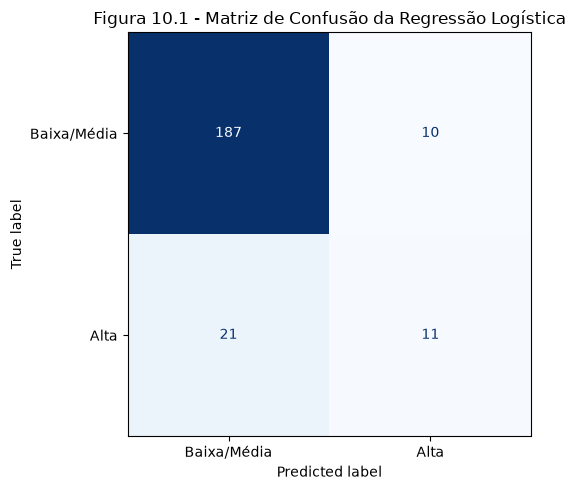

In [198]:
# ==========================================================
# Figura 10.1 - Matriz de Confusão
# ==========================================================

import matplotlib.pyplot as plt

# Cria a figura.
figura, eixo = plt.subplots(figsize=(6,5))

# Gera a matriz de confusão.
ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_regressao_logistica,
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

# Configura o gráfico.
eixo.set_title(
    "Figura 10.1 - Matriz de Confusão da Regressão Logística"
)

plt.tight_layout()
plt.show()

#### Conclusão

A Regressão Logística apresentou **acurácia de 86,46%**, indicando um bom desempenho na classificação geral dos vinhos do conjunto de teste. Entretanto, como a base de dados possui predominância de vinhos classificados como baixa ou média qualidade, a acurácia deve ser interpretada em conjunto com as demais métricas.

A **precisão de 52,38%** indica que aproximadamente metade dos vinhos classificados pelo modelo como de alta qualidade realmente pertenciam a essa classe. Já o **recall de 34,38%** demonstra que o modelo identificou apenas uma parcela dos vinhos de alta qualidade existentes no conjunto de teste.

O **F1-Score de 41,51%** evidencia que ainda há limitações no equilíbrio entre precisão e capacidade de identificação da classe minoritária.

A análise da matriz de confusão reforça esse comportamento, mostrando que o modelo apresentou bom desempenho na identificação de vinhos de baixa ou média qualidade, porém encontrou maior dificuldade para reconhecer corretamente os vinhos de alta qualidade.

Esses resultados servirão como referência para a avaliação do modelo Random Forest, permitindo comparar qual algoritmo apresenta melhor capacidade de classificação para este problema.

### 10.2 Avaliação do Modelo Random Forest

O modelo Random Forest será avaliado utilizando as mesmas métricas apresentadas na seção anterior: **Acurácia, Precisão, Recall e F1-Score**.

A utilização dos mesmos critérios permite comparar diretamente os dois algoritmos. Também serão apresentados a **Matriz de Confusão** e o **Classification Report**, possibilitando uma análise detalhada do desempenho em cada classe.


In [199]:
# ==========================================================
# Avaliação do Modelo Random Forest
# Cálculo das Métricas
# ==========================================================

# Calcula as principais métricas de desempenho
# do modelo Random Forest.
resultados_random_forest = {
    "Acurácia": accuracy_score(
        classe_teste,
        previsoes_random_forest
    ),
    "Precisão": precision_score(
        classe_teste,
        previsoes_random_forest
    ),
    "Recall": recall_score(
        classe_teste,
        previsoes_random_forest
    ),
    "F1-Score": f1_score(
        classe_teste,
        previsoes_random_forest
    )
}

In [200]:
# ==========================================================
# Tabela 10.3 - Métricas do Modelo Random Forest
# ==========================================================

# Organiza as métricas em um DataFrame.
tabela_metricas_random_forest = pd.DataFrame(
    resultados_random_forest.items(),
    columns=[
        "Métrica",
        "Resultado (%)"
    ]
)

# Converte os resultados para percentual.
tabela_metricas_random_forest["Resultado (%)"] = (
    tabela_metricas_random_forest["Resultado (%)"] * 100
)

# Exibe a tabela formatada.
display(
    tabela_metricas_random_forest.style
        .hide(axis="index")
        .format({
            "Resultado (%)": "{:.2f}%"
        })
        .set_caption("Tabela Métricas do Modelo Random Forest")
)

Métrica,Resultado (%)
Acurácia,92.14%
Precisão,79.17%
Recall,59.38%
F1-Score,67.86%


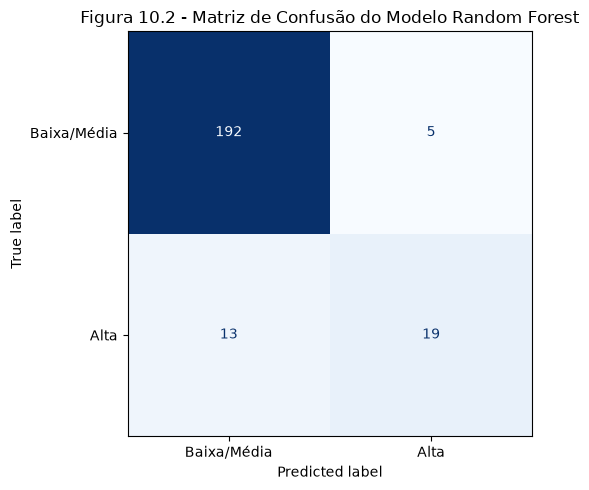

In [201]:
# ==========================================================
# Figura 10.2 - Matriz de Confusão do Modelo Random Forest
# ==========================================================

figura, eixo = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_random_forest,
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

eixo.set_title(
    "Figura 10.2 - Matriz de Confusão do Modelo Random Forest"
)

plt.tight_layout()
plt.show()

In [202]:
# ==========================================================
# Relatório de Classificação do Random Forest
# ==========================================================

# Exibe as métricas detalhadas para cada classe.
print(
    classification_report(
        classe_teste,
        previsoes_random_forest,
        target_names=[
            "Baixa/Média Qualidade",
            "Alta Qualidade"
        ]
    )
)

                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.94      0.97      0.96       197
       Alta Qualidade       0.79      0.59      0.68        32

             accuracy                           0.92       229
            macro avg       0.86      0.78      0.82       229
         weighted avg       0.92      0.92      0.92       229



#### Conclusão

O modelo **Random Forest** apresentou desempenho superior ao observado anteriormente na Regressão Logística, alcançando **92,14% de acurácia**, além de melhorias nas métricas de **Precisão (79,17%)**, **Recall (59,38%)** e **F1-Score (67,86%)**.

A análise da matriz de confusão demonstra que o modelo classificou corretamente **192** vinhos de baixa/média qualidade e **19** vinhos de alta qualidade, reduzindo a quantidade de erros na identificação da classe minoritária quando comparado ao modelo anterior.

O *Classification Report* confirma esse resultado, evidenciando um desempenho elevado para a classe de baixa/média qualidade e uma melhora significativa na identificação dos vinhos de alta qualidade, embora ainda existam casos classificados incorretamente.

De forma geral, o Random Forest apresentou maior capacidade de generalização e melhor equilíbrio entre precisão e recall, mostrando-se mais adequado para o problema de classificação da qualidade dos vinhos.

Na próxima etapa, será realizada uma comparação consolidada entre os modelos treinados, permitindo identificar objetivamente o algoritmo com melhor desempenho para este conjunto de dados.

### 10.3 Avaliação do Modelo K-Nearest Neighbors (KNN)

O modelo **K-Nearest Neighbors (KNN)** será avaliado utilizando as mesmas métricas aplicadas aos modelos anteriores: **Acurácia, Precisão, Recall e F1-Score**.

A utilização dos mesmos critérios de avaliação permite comparar de forma consistente o desempenho dos diferentes algoritmos de classificação utilizados neste projeto.

Como a classe **Alta Qualidade** possui menor quantidade de observações no conjunto de dados, a análise não será baseada apenas na acurácia. As métricas de **Precisão, Recall e F1-Score** também serão consideradas para avaliar a capacidade do modelo em identificar corretamente os vinhos pertencentes à classe minoritária.

Além das métricas numéricas, serão apresentados a **Matriz de Confusão** e o **Classification Report**, permitindo analisar com maior detalhamento os acertos e erros do modelo em cada classe.

In [203]:
# ==========================================================
# Avaliação do Modelo K-Nearest Neighbors (KNN)
# Cálculo das Métricas
# ==========================================================

# Calcula as principais métricas de desempenho
# do modelo KNN.
#
# As métricas comparam as classes reais do conjunto
# de teste com as previsões realizadas pelo modelo.
resultados_knn = {
    "Acurácia": accuracy_score(
        classe_teste,
        previsoes_knn
    ),

    "Precisão": precision_score(
        classe_teste,
        previsoes_knn
    ),

    "Recall": recall_score(
        classe_teste,
        previsoes_knn
    ),

    "F1-Score": f1_score(
        classe_teste,
        previsoes_knn
    )
}

In [204]:
# ==========================================================
# Tabela de Métricas do Modelo KNN
# ==========================================================

# Organiza as métricas calculadas anteriormente
# em um DataFrame para facilitar a visualização.
tabela_metricas_knn = pd.DataFrame(
    resultados_knn.items(),
    columns=[
        "Métrica",
        "Resultado (%)"
    ]
)


# Converte os resultados das métricas
# de valores decimais para percentuais.
tabela_metricas_knn["Resultado (%)"] = (
    tabela_metricas_knn["Resultado (%)"] * 100
)


# Exibe a tabela formatada.
display(
    tabela_metricas_knn.style
        .hide(axis="index")
        .format({
            "Resultado (%)": "{:.2f}%"
        })
        .set_caption(
            "Tabela Métricas do Modelo KNN"
        )
)

Métrica,Resultado (%)
Acurácia,86.46%
Precisão,51.85%
Recall,43.75%
F1-Score,47.46%


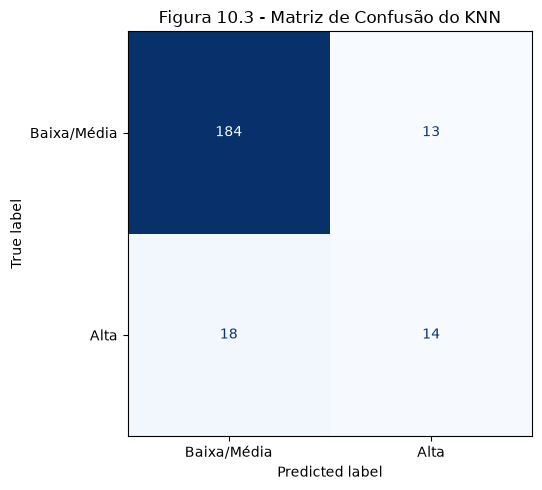

In [205]:
# ==========================================================
# Figura 10.3 - Matriz de Confusão do KNN
# ==========================================================

# Cria a figura que receberá
# a matriz de confusão.
figura, eixo = plt.subplots(
    figsize=(6, 5)
)


# Gera a matriz de confusão comparando
# as classes reais com as previsões do KNN.
ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_knn,

    # Define os nomes apresentados
    # para cada classe.
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],

    # Mantém a mesma identidade visual
    # utilizada nas matrizes anteriores.
    cmap="Blues",

    # Exibe os valores absolutos
    # dentro da matriz.
    values_format="d",

    # Remove a barra lateral de cores.
    colorbar=False,

    # Define o eixo em que o gráfico
    # será apresentado.
    ax=eixo
)


# Define o título da visualização.
eixo.set_title(
    "Figura 10.3 - Matriz de Confusão do KNN"
)


# Ajusta os elementos da figura
# para evitar sobreposição.
plt.tight_layout()

# Exibe a matriz de confusão.
plt.show()

In [206]:
# ==========================================================
# Relatório de Classificação do KNN
# ==========================================================

# Exibe as métricas detalhadas
# separadamente para cada classe.
print(
    classification_report(
        classe_teste,
        previsoes_knn,

        # Define os nomes utilizados
        # para representar cada classe.
        target_names=[
            "Baixa/Média Qualidade",
            "Alta Qualidade"
        ]
    )
)

                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.91      0.93      0.92       197
       Alta Qualidade       0.52      0.44      0.47        32

             accuracy                           0.86       229
            macro avg       0.71      0.69      0.70       229
         weighted avg       0.86      0.86      0.86       229



#### Conclusão

O modelo **K-Nearest Neighbors (KNN)** foi avaliado utilizando as métricas de **Acurácia, Precisão, Recall e F1-Score**, além da Matriz de Confusão e do *Classification Report*.

A análise das métricas permite avaliar tanto o desempenho geral do modelo quanto sua capacidade de identificar os vinhos pertencentes à classe **Alta Qualidade**, que representa a classe minoritária do conjunto de dados.

A Matriz de Confusão possibilita observar a quantidade de classificações corretas e incorretas realizadas pelo modelo para cada uma das classes, enquanto o *Classification Report* apresenta de forma detalhada o desempenho obtido para vinhos de baixa/média e alta qualidade.

Os resultados obtidos pelo KNN serão comparados posteriormente aos resultados da **Regressão Logística** e do **Random Forest**, utilizando os mesmos critérios de avaliação para identificar qual dos três algoritmos apresentou o desempenho mais adequado para o problema de classificação da qualidade dos vinhos.

### 10.4 Comparação entre os Modelos

Após a avaliação individual da **Regressão Logística**, do **Random Forest** e do **K-Nearest Neighbors (KNN)**, os resultados obtidos serão comparados utilizando as mesmas métricas de classificação.

A comparação considera:

- **Acurácia:** proporção total de classificações corretas realizadas pelo modelo;
- **Precisão:** proporção dos vinhos previstos como de alta qualidade que realmente pertencem a essa classe;
- **Recall:** capacidade do modelo em identificar corretamente os vinhos que realmente são de alta qualidade;
- **F1-Score:** medida que combina Precisão e Recall, permitindo avaliar o equilíbrio entre essas duas métricas.

Como a classe **Alta Qualidade** possui menor quantidade de observações no conjunto de dados, a escolha do modelo mais adequado não será baseada apenas na acurácia. As métricas de **Precisão, Recall e F1-Score** também serão consideradas, principalmente para avaliar a capacidade dos modelos em reconhecer corretamente a classe minoritária.

A tabela comparativa apresentada a seguir consolida os resultados dos três modelos, permitindo identificar o algoritmo que apresentou o maior desempenho em cada uma das métricas avaliadas.

In [207]:
# ==========================================================
# 10.4 Comparação entre os Modelos
# ==========================================================

# Reúne os resultados dos modelos em um único dicionário.
#
# Essa estrutura facilita a reutilização do código e permite
# adicionar novos modelos posteriormente com poucas alterações.
resultados_modelos = {
    "Regressão Logística": resultados_regressao_logistica,
    "Random Forest": resultados_random_forest,
    "KNN": resultados_knn
}


# Cria um DataFrame a partir dos resultados dos modelos.
#
# Cada coluna representa um modelo e cada linha corresponde
# a uma das métricas utilizadas na avaliação.
comparacao_modelos = pd.DataFrame(
    resultados_modelos
)


# Converte os resultados para percentual.
comparacao_modelos = comparacao_modelos * 100


# Identifica automaticamente o modelo que apresentou
# o maior resultado em cada métrica.
comparacao_modelos["Melhor Modelo"] = (
    comparacao_modelos.idxmax(axis=1)
)


# Transforma o índice, que contém os nomes das métricas,
# em uma coluna do DataFrame.
comparacao_modelos = (
    comparacao_modelos
    .reset_index()
    .rename(
        columns={
            "index": "Métrica"
        }
    )
)


# Exibe a tabela comparativa formatada.
display(
    comparacao_modelos.style
        .hide(axis="index")
        .format({
            "Regressão Logística": "{:.2f}%",
            "Random Forest": "{:.2f}%",
            "KNN": "{:.2f}%"
        })
        .set_caption(
            "Comparação entre os Modelos de Classificação"
        )
)

Métrica,Regressão Logística,Random Forest,KNN,Melhor Modelo
Acurácia,86.46%,92.14%,86.46%,Random Forest
Precisão,52.38%,79.17%,51.85%,Random Forest
Recall,34.38%,59.38%,43.75%,Random Forest
F1-Score,41.51%,67.86%,47.46%,Random Forest


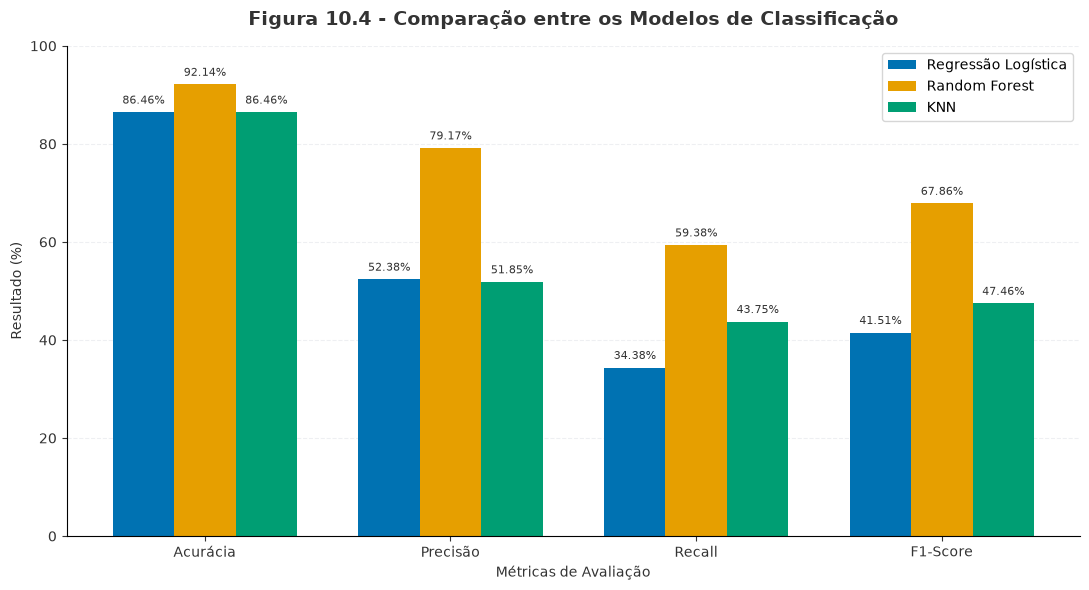

In [208]:
# ==========================================================
# Figura 10.4 - Comparação entre os Modelos de Classificação
# ==========================================================

# Define as posições das métricas no eixo horizontal.
posicoes = np.arange(
    len(comparacao_modelos)
)


# Define a largura das barras.
#
# Como são comparados três modelos, as barras são
# posicionadas lado a lado dentro de cada métrica.
largura_barras = 0.25


# ----------------------------------------------------------
# CORES DOS MODELOS
# ----------------------------------------------------------

# Utiliza a paleta categórica definida anteriormente
# no item 2.1.
#
# Cada modelo recebe uma cor diferente para facilitar
# sua identificação durante a comparação.
cor_regressao_logistica = PALETA_CATEGORICA[0]
cor_random_forest = PALETA_CATEGORICA[1]
cor_knn = PALETA_CATEGORICA[2]


# ----------------------------------------------------------
# CRIAÇÃO DA FIGURA
# ----------------------------------------------------------

# Cria a área do gráfico.
figura, eixo = plt.subplots(
    figsize=(11, 6)
)


# ----------------------------------------------------------
# REGRESSÃO LOGÍSTICA
# ----------------------------------------------------------

barras_regressao = eixo.bar(
    posicoes - largura_barras,
    comparacao_modelos["Regressão Logística"],
    largura_barras,
    label="Regressão Logística",
    color=cor_regressao_logistica
)


# ----------------------------------------------------------
# RANDOM FOREST
# ----------------------------------------------------------

barras_random_forest = eixo.bar(
    posicoes,
    comparacao_modelos["Random Forest"],
    largura_barras,
    label="Random Forest",
    color=cor_random_forest
)


# ----------------------------------------------------------
# KNN
# ----------------------------------------------------------

barras_knn = eixo.bar(
    posicoes + largura_barras,
    comparacao_modelos["KNN"],
    largura_barras,
    label="KNN",
    color=cor_knn
)


# ----------------------------------------------------------
# VALORES SOBRE AS BARRAS
# ----------------------------------------------------------

# Reúne os conjuntos de barras para evitar
# repetição do código de inclusão dos percentuais.
conjuntos_barras = [
    barras_regressao,
    barras_random_forest,
    barras_knn
]


# Adiciona o resultado percentual acima
# de cada barra.
for conjunto_barras in conjuntos_barras:

    for barra in conjunto_barras:

        valor = barra.get_height()

        eixo.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1.2,
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            color=CORES["texto"]
        )


# ----------------------------------------------------------
# FORMATAÇÃO DO GRÁFICO
# ----------------------------------------------------------

# Define o título.
eixo.set_title(
    "Figura 10.4 - Comparação entre os Modelos de Classificação",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"],
    pad=15
)


# Define os títulos dos eixos.
eixo.set_ylabel(
    "Resultado (%)",
    color=CORES["texto"]
)

eixo.set_xlabel(
    "Métricas de Avaliação",
    color=CORES["texto"]
)


# Mantém a escala completa entre 0% e 100%,
# evitando distorções na comparação.
eixo.set_ylim(
    0,
    100
)


# Define as métricas apresentadas
# no eixo horizontal.
eixo.set_xticks(
    posicoes
)

eixo.set_xticklabels(
    comparacao_modelos["Métrica"]
)


# Define a cor dos textos dos eixos.
eixo.tick_params(
    axis="both",
    colors=CORES["texto"]
)


# Adiciona linhas horizontais leves
# para facilitar a comparação dos resultados.
eixo.grid(
    axis="y",
    linestyle="--",
    alpha=0.30,
    color=CORES["contexto"]
)

eixo.set_axisbelow(
    True
)


# Remove bordas que não contribuem
# para a leitura da visualização.
eixo.spines["top"].set_visible(
    False
)

eixo.spines["right"].set_visible(
    False
)


# ----------------------------------------------------------
# LEGENDA
# ----------------------------------------------------------

# Exibe a legenda utilizando as cores
# associadas a cada modelo.
eixo.legend(
    loc="upper right",
    frameon=True
)


# Ajusta automaticamente os espaçamentos.
plt.tight_layout()


# Exibe o gráfico.
plt.show()

#### Conclusão

A comparação entre os três modelos evidencia diferenças importantes em seus desempenhos na classificação da qualidade dos vinhos.

O **Random Forest apresentou o melhor resultado em todas as métricas avaliadas**, alcançando **92,14% de acurácia, 79,17% de precisão, 59,38% de recall e 67,86% de F1-Score**.

A **Regressão Logística** e o **KNN** apresentaram a mesma acurácia, de **86,46%**. Entretanto, a análise das demais métricas mostra diferenças entre os modelos. A Regressão Logística apresentou precisão de **52,38%**, recall de **34,38%** e F1-Score de **41,51%**, enquanto o KNN apresentou precisão de **51,85%**, recall de **43,75%** e F1-Score de **47,46%**.

Embora o KNN tenha apresentado precisão semelhante à Regressão Logística, obteve resultados superiores em **Recall e F1-Score**, demonstrando maior capacidade de identificar os vinhos pertencentes à classe **Alta Qualidade** e melhor equilíbrio entre Precisão e Recall.

Considerando que a classe **Alta Qualidade** é minoritária no conjunto de dados, as métricas de Recall e F1-Score são especialmente relevantes para a análise. Nesse contexto, o **Random Forest apresentou o desempenho mais adequado entre os três modelos avaliados**, principalmente por combinar maior capacidade de identificação dos vinhos de alta qualidade com melhor equilíbrio entre as métricas.

Dessa forma, entre os modelos testados neste projeto, o **Random Forest foi selecionado como o modelo com melhor desempenho para a classificação da qualidade dos vinhos com base em suas características físico-químicas**.

### 10.5 Análise da Classe Alta Qualidade

Além da avaliação do desempenho geral dos modelos, é importante analisar especificamente a capacidade de identificação dos vinhos classificados como **Alta Qualidade**.

Neste projeto, a classe **Alta Qualidade (1)** representa os vinhos com nota igual ou superior a 7 e possui menor representatividade no conjunto de dados. Em problemas com classes desbalanceadas, a acurácia isoladamente pode não representar adequadamente a capacidade do modelo em reconhecer a classe minoritária.

Como o estudo de caso não estabelece qual tipo de erro possui maior impacto para o negócio, será adotada uma análise equilibrada da classe Alta Qualidade, considerando:

- **Precisão:** indica, entre os vinhos classificados pelo modelo como Alta Qualidade, quantos realmente pertencem a essa classe;
- **Recall:** indica, entre todos os vinhos que realmente são de Alta Qualidade, quantos foram corretamente identificados pelo modelo;
- **F1-Score:** representa o equilíbrio entre Precisão e Recall.

Essa análise complementa a avaliação geral dos modelos e contribui para a seleção de uma abordagem capaz de identificar adequadamente os vinhos de Alta Qualidade sem considerar apenas a acurácia total.

In [209]:
# ==========================================================
# Função Auxiliar - Avaliação da Classe Alta Qualidade
# ==========================================================

def avaliar_classe_alta_qualidade(
    classe_real,
    previsoes,
    classe_positiva=1
):
    """
    Calcula Precisão, Recall e F1-Score considerando
    a classe Alta Qualidade como classe positiva.

    Parâmetros
    ----------
    classe_real:
        Valores reais da variável alvo.

    previsoes:
        Classes previstas pelo modelo.

    classe_positiva:
        Classe considerada positiva na avaliação.
        Por padrão, utiliza 1, correspondente à
        classe Alta Qualidade.

    Retorno
    -------
    dict:
        Dicionário contendo Precisão, Recall e
        F1-Score da classe positiva.
    """

    return {
        "Precisão": precision_score(
            classe_real,
            previsoes,
            pos_label=classe_positiva
        ),

        "Recall": recall_score(
            classe_real,
            previsoes,
            pos_label=classe_positiva
        ),

        "F1-Score": f1_score(
            classe_real,
            previsoes,
            pos_label=classe_positiva
        )
    }

In [210]:
# ==========================================================
# 10.5 Análise da Classe Alta Qualidade
# ==========================================================

# Avalia especificamente a classe Alta Qualidade
# para cada um dos modelos desenvolvidos.

avaliacao_alta_regressao = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_regressao_logistica
)


avaliacao_alta_random_forest = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_random_forest
)


avaliacao_alta_knn = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_knn
)

In [211]:
# ==========================================================
# Comparação do Desempenho na Classe Alta Qualidade
# ==========================================================

# Reúne os resultados dos três modelos
# em uma única estrutura.
resultados_classe_alta = {
    "Regressão Logística": avaliacao_alta_regressao,
    "Random Forest": avaliacao_alta_random_forest,
    "KNN": avaliacao_alta_knn
}


# Cria o DataFrame comparativo.
comparacao_classe_alta = pd.DataFrame(
    resultados_classe_alta
)


# Converte os resultados para percentual.
comparacao_classe_alta = (
    comparacao_classe_alta * 100
)


# Identifica automaticamente o modelo com
# o maior resultado em cada métrica.
comparacao_classe_alta["Melhor Modelo"] = (
    comparacao_classe_alta.idxmax(axis=1)
)


# Transforma o índice em uma coluna
# contendo o nome das métricas.
comparacao_classe_alta = (
    comparacao_classe_alta
    .reset_index()
    .rename(
        columns={
            "index": "Métrica"
        }
    )
)


# Exibe a tabela formatada.
display(
    comparacao_classe_alta.style
        .hide(axis="index")
        .format({
            "Regressão Logística": "{:.2f}%",
            "Random Forest": "{:.2f}%",
            "KNN": "{:.2f}%"
        })
        .set_caption(
            "Desempenho dos Modelos na Classe Alta Qualidade"
        )
)

Métrica,Regressão Logística,Random Forest,KNN,Melhor Modelo
Precisão,52.38%,79.17%,51.85%,Random Forest
Recall,34.38%,59.38%,43.75%,Random Forest
F1-Score,41.51%,67.86%,47.46%,Random Forest


#### Conclusão

A análise específica da classe **Alta Qualidade** reforça as diferenças observadas entre os três modelos.

O **Random Forest apresentou o melhor desempenho nas três métricas analisadas**, alcançando **79,17% de Precisão, 59,38% de Recall e 67,86% de F1-Score** para a identificação dos vinhos de Alta Qualidade.

A Regressão Logística apresentou **52,38% de Precisão e 34,38% de Recall**, enquanto o KNN apresentou **51,85% de Precisão e 43,75% de Recall**. Embora os dois modelos tenham obtido resultados semelhantes em Precisão, o KNN conseguiu identificar uma proporção maior dos vinhos que realmente pertencem à classe Alta Qualidade.

Entre os modelos avaliados, o Random Forest apresentou o melhor equilíbrio entre Precisão e Recall, refletido também no maior F1-Score.

Entretanto, o Recall de **59,38%** demonstra que ainda existe espaço para melhoria na identificação da classe Alta Qualidade. Dessa forma, antes da definição do modelo final, podem ser avaliadas estratégias de otimização do modelo e tratamento do desbalanceamento das classes, buscando aumentar a capacidade de identificação dos vinhos de Alta Qualidade sem comprometer excessivamente a Precisão.

## 11. Otimização do Modelo Random Forest

A avaliação realizada anteriormente demonstrou que o **Random Forest** apresentou o melhor desempenho entre os modelos testados para a classificação da qualidade dos vinhos.

Entretanto, a avaliação também mostrou que ainda existem oportunidades de melhoria, principalmente na identificação dos vinhos pertencentes à classe **Alta Qualidade**, que possui menor representatividade no conjunto de dados.

Antes da seleção definitiva do modelo, será realizada uma etapa de otimização com os seguintes objetivos:

1. verificar se o desempenho observado pelo Random Forest é consistente em diferentes subconjuntos dos dados de treinamento;
2. avaliar diferentes configurações do algoritmo;
3. buscar um melhor equilíbrio entre **Precisão e Recall da classe Alta Qualidade**;
4. comparar o modelo otimizado com o Random Forest originalmente utilizado.

A otimização será realizada exclusivamente com os dados de treinamento. O conjunto de teste permanecerá separado e será utilizado somente após a definição da melhor configuração, preservando sua função de avaliar o desempenho final do modelo em dados não utilizados durante o processo de treinamento e ajuste.

### 11.1 Validação Cruzada do Random Forest Original

O desempenho obtido anteriormente pelo Random Forest foi calculado sobre uma única divisão entre dados de treino e teste.

Embora essa estratégia permita avaliar o modelo em dados não utilizados durante o treinamento, o resultado pode sofrer influência da composição específica dos conjuntos gerados.

Para verificar a estabilidade do modelo, será utilizada a técnica de **Validação Cruzada Estratificada (Stratified K-Fold Cross-Validation)**.

Nesse procedimento, o conjunto de treinamento é dividido em diferentes partes (*folds*). O modelo é treinado repetidamente utilizando combinações distintas dessas partes para treinamento e validação.

Será utilizado `StratifiedKFold`, que preserva aproximadamente a proporção das classes em cada divisão. Essa característica é especialmente relevante neste projeto devido à menor quantidade de registros pertencentes à classe Alta Qualidade.

Serão utilizadas **5 divisões (folds)** e avaliadas as métricas de Acurácia, Precisão, Recall e F1-Score.

O conjunto de teste não será utilizado nesta etapa.

In [212]:
# ==========================================================
# 11.1 Validação Cruzada do Random Forest Original
# ==========================================================

# Importa as ferramentas utilizadas para realizar
# a validação cruzada estratificada.
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)


# ----------------------------------------------------------
# CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
# ----------------------------------------------------------

# Cria a estratégia de validação cruzada.
#
# n_splits=5:
# divide os dados de treinamento em cinco partes.
#
# shuffle=True:
# embaralha os registros antes da criação das divisões.
#
# random_state=42:
# garante a reprodutibilidade do experimento.
validacao_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Define as métricas que serão avaliadas
# durante a validação cruzada.
metricas_validacao = {
    "Acurácia": "accuracy",
    "Precisão": "precision",
    "Recall": "recall",
    "F1-Score": "f1"
}


# ----------------------------------------------------------
# EXECUÇÃO DA VALIDAÇÃO CRUZADA
# ----------------------------------------------------------

# Avalia o Random Forest utilizando somente
# os dados de treinamento.
#
# O conjunto de teste permanece separado e não participa
# desta etapa.
resultados_validacao_cruzada = cross_validate(
    estimator=modelo_random_forest,
    X=caracteristicas_treino,
    y=classe_treino,
    cv=validacao_cruzada,
    scoring=metricas_validacao
)

In [213]:
# ==========================================================
# Resultados da Validação Cruzada
# ==========================================================

# Cria uma estrutura para armazenar
# a média e o desvio-padrão de cada métrica.
resumo_validacao_cruzada = []


# Percorre as métricas avaliadas.
for nome_metrica in metricas_validacao:

    # O cross_validate adiciona o prefixo "test_"
    # ao nome de cada métrica.
    chave_resultado = f"test_{nome_metrica}"

    valores = resultados_validacao_cruzada[
        chave_resultado
    ]

    resumo_validacao_cruzada.append({
        "Métrica": nome_metrica,
        "Média (%)": valores.mean() * 100,
        "Desvio-Padrão (%)": valores.std() * 100
    })


# Transforma os resultados em DataFrame.
tabela_validacao_cruzada = pd.DataFrame(
    resumo_validacao_cruzada
)


# Exibe a tabela formatada.
display(
    tabela_validacao_cruzada.style
        .hide(axis="index")
        .format({
            "Média (%)": "{:.2f}%",
            "Desvio-Padrão (%)": "{:.2f}%"
        })
        .set_caption(
            "Validação Cruzada do Random Forest Original"
        )
)

Métrica,Média (%),Desvio-Padrão (%)
Acurácia,90.48%,1.63%
Precisão,74.85%,9.60%
Recall,48.92%,6.10%
F1-Score,58.83%,6.38%


### 11.2 Otimização dos Hiperparâmetros

Os algoritmos de Machine Learning possuem configurações denominadas **hiperparâmetros**, que controlam aspectos do processo de treinamento e podem influenciar diretamente o desempenho do modelo.

No Random Forest, alguns desses hiperparâmetros determinam, por exemplo:

- a quantidade de árvores construídas;
- a profundidade máxima das árvores;
- a quantidade mínima de observações necessária para realizar uma nova divisão;
- a quantidade mínima de observações permitida nas folhas das árvores;
- o peso atribuído às diferentes classes durante o treinamento.

Para avaliar diferentes combinações desses parâmetros será utilizado o **GridSearchCV**.

O procedimento realiza múltiplos treinamentos utilizando diferentes configurações e aplica validação cruzada para avaliar cada combinação.

Como a classe Alta Qualidade possui menor representatividade e o objetivo é buscar equilíbrio entre sua identificação e a confiabilidade das previsões positivas, será utilizado o **F1-Score** como métrica principal para selecionar a melhor configuração.

O conjunto de teste continuará preservado e não será utilizado durante a busca pelos melhores hiperparâmetros.

In [214]:
# ==========================================================
# 11.2 Otimização dos Hiperparâmetros
# ==========================================================

# Importa a ferramenta responsável pela busca
# de hiperparâmetros utilizando validação cruzada.
from sklearn.model_selection import GridSearchCV


# ----------------------------------------------------------
# MODELO BASE
# ----------------------------------------------------------

# Cria um novo Random Forest para a etapa de otimização.
#
# Não reutilizamos diretamente o modelo já treinado,
# pois o GridSearchCV realizará novos treinamentos.
modelo_random_forest_otimizacao = RandomForestClassifier(
    random_state=42
)


# ----------------------------------------------------------
# HIPERPARÂMETROS QUE SERÃO TESTADOS
# ----------------------------------------------------------

parametros_random_forest = {

    # Quantidade de árvores da floresta.
    "n_estimators": [
        100,
        200,
        300
    ],

    # Profundidade máxima permitida para as árvores.
    "max_depth": [
        None,
        10,
        20
    ],

    # Quantidade mínima de registros necessária
    # para dividir um nó.
    "min_samples_split": [
        2,
        5,
        10
    ],

    # Quantidade mínima de registros permitida
    # em uma folha.
    "min_samples_leaf": [
        1,
        2,
        4
    ],

    # Permite avaliar o modelo normal e uma versão
    # que atribui pesos automaticamente às classes
    # de acordo com sua frequência.
    "class_weight": [
        None,
        "balanced"
    ]
}

In [215]:
# ==========================================================
# Busca pela Melhor Configuração
# ==========================================================

# Cria o processo de busca dos hiperparâmetros.
busca_random_forest = GridSearchCV(

    # Modelo que será otimizado.
    estimator=modelo_random_forest_otimizacao,

    # Combinações de hiperparâmetros que serão avaliadas.
    param_grid=parametros_random_forest,

    # Utiliza a mesma estratégia de validação
    # cruzada estratificada criada anteriormente.
    cv=validacao_cruzada,

    # Utiliza o F1-Score como principal critério
    # para selecionar a melhor configuração.
    scoring="f1",

    # Utiliza os núcleos disponíveis do processador
    # para acelerar os treinamentos.
    n_jobs=-1,

    # Ao final, mantém treinado o modelo
    # com a melhor configuração encontrada.
    refit=True
)


# Executa a busca utilizando exclusivamente
# o conjunto de treinamento.
busca_random_forest.fit(
    caracteristicas_treino,
    classe_treino
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.2

In [216]:
# ==========================================================
# Melhor Configuração Encontrada
# ==========================================================

# Recupera a melhor combinação de hiperparâmetros.
melhores_parametros_random_forest = (
    busca_random_forest.best_params_
)


# Recupera o melhor F1-Score médio
# obtido durante a validação cruzada.
melhor_f1_validacao = (
    busca_random_forest.best_score_
)


print(
    "Melhores hiperparâmetros encontrados:"
)

print(
    melhores_parametros_random_forest
)


print(
    "\nMelhor F1-Score médio na validação cruzada: "
    f"{melhor_f1_validacao * 100:.2f}%"
)

Melhores hiperparâmetros encontrados:
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Melhor F1-Score médio na validação cruzada: 64.18%


### 11.3 Avaliação do Random Forest Otimizado

Após a seleção da melhor combinação de hiperparâmetros por meio da validação cruzada, o modelo otimizado será avaliado sobre o conjunto de teste.

Essa etapa permite verificar se as melhorias observadas durante a otimização também se refletem em dados que permaneceram separados durante todo o processo de seleção dos hiperparâmetros.

Serão utilizadas as mesmas métricas aplicadas anteriormente: **Acurácia, Precisão, Recall e F1-Score**, permitindo comparar diretamente o Random Forest otimizado com sua configuração original.

In [217]:
# ==========================================================
# 11.3 Random Forest Otimizado
# ==========================================================

# Recupera o modelo correspondente à melhor
# configuração encontrada pelo GridSearchCV.
modelo_random_forest_otimizado = (
    busca_random_forest.best_estimator_
)


# Realiza previsões sobre o conjunto de teste,
# que não participou da otimização.
previsoes_random_forest_otimizado = (
    modelo_random_forest_otimizado.predict(
        caracteristicas_teste
    )
)

In [218]:
# ==========================================================
# Métricas do Random Forest Otimizado
# ==========================================================

resultados_random_forest_otimizado = {

    "Acurácia": accuracy_score(
        classe_teste,
        previsoes_random_forest_otimizado
    ),

    "Precisão": precision_score(
        classe_teste,
        previsoes_random_forest_otimizado
    ),

    "Recall": recall_score(
        classe_teste,
        previsoes_random_forest_otimizado
    ),

    "F1-Score": f1_score(
        classe_teste,
        previsoes_random_forest_otimizado
    )
}

In [219]:
# ==========================================================
# Tabela de Métricas do Random Forest Otimizado
# ==========================================================

tabela_metricas_random_forest_otimizado = pd.DataFrame(
    resultados_random_forest_otimizado.items(),
    columns=[
        "Métrica",
        "Resultado (%)"
    ]
)


# Converte para percentual.
tabela_metricas_random_forest_otimizado[
    "Resultado (%)"
] = (
    tabela_metricas_random_forest_otimizado[
        "Resultado (%)"
    ] * 100
)


# Exibe os resultados.
display(
    tabela_metricas_random_forest_otimizado.style
        .hide(axis="index")
        .format({
            "Resultado (%)": "{:.2f}%"
        })
        .set_caption(
            "Métricas do Random Forest Otimizado"
        )
)

Métrica,Resultado (%)
Acurácia,88.21%
Precisão,56.41%
Recall,68.75%
F1-Score,61.97%


### 11.4 Comparação entre o Random Forest Original e o Otimizado

Para avaliar o impacto da otimização, serão comparadas as métricas obtidas pelo Random Forest original e pela versão resultante da busca de hiperparâmetros.

A análise permitirá verificar se a otimização proporcionou melhoria efetiva no desempenho do modelo, com atenção especial para **Recall e F1-Score da classe Alta Qualidade**.

Uma eventual redução da acurácia não será considerada necessariamente negativa caso seja acompanhada por uma melhoria relevante na capacidade de identificar corretamente os vinhos de Alta Qualidade e por um melhor equilíbrio entre Precisão e Recall.

In [220]:
# ==========================================================
# 11.4 Comparação: Random Forest Original × Otimizado
# ==========================================================

comparacao_random_forest = pd.DataFrame({

    "Random Forest Original": (
        resultados_random_forest
    ),

    "Random Forest Otimizado": (
        resultados_random_forest_otimizado
    )
})


# Converte os resultados para percentual.
comparacao_random_forest = (
    comparacao_random_forest * 100
)


# Calcula a diferença entre o modelo otimizado
# e o modelo original.
comparacao_random_forest["Diferença"] = (
    comparacao_random_forest[
        "Random Forest Otimizado"
    ]
    -
    comparacao_random_forest[
        "Random Forest Original"
    ]
)


# Transforma o índice em coluna.
comparacao_random_forest = (
    comparacao_random_forest
    .reset_index()
    .rename(
        columns={
            "index": "Métrica"
        }
    )
)


# Exibe a tabela comparativa.
display(
    comparacao_random_forest.style
        .hide(axis="index")
        .format({
            "Random Forest Original": "{:.2f}%",
            "Random Forest Otimizado": "{:.2f}%",
            "Diferença": "{:+.2f} p.p."
        })
        .set_caption(
            "Comparação entre Random Forest Original e Otimizado"
        )
)

Métrica,Random Forest Original,Random Forest Otimizado,Diferença
Acurácia,92.14%,88.21%,-3.93 p.p.
Precisão,79.17%,56.41%,-22.76 p.p.
Recall,59.38%,68.75%,+9.38 p.p.
F1-Score,67.86%,61.97%,-5.89 p.p.


#### Conclusão

A otimização dos hiperparâmetros modificou o comportamento do Random Forest, principalmente em relação à identificação dos vinhos pertencentes à classe **Alta Qualidade**.

O modelo otimizado apresentou aumento do **Recall de 59,38% para 68,75%**, uma melhoria de 9,38 pontos percentuais. Esse resultado demonstra maior capacidade de identificar os vinhos que realmente pertencem à classe Alta Qualidade.

Entretanto, esse ganho foi acompanhado por uma redução expressiva da **Precisão**, que passou de 79,17% para 56,41%. A Acurácia também apresentou redução, de 92,14% para 88,21%, enquanto o F1-Score diminuiu de 67,86% para 61,97%.

Os resultados evidenciam um *trade-off* entre Recall e Precisão: o modelo otimizado passou a identificar uma parcela maior dos vinhos de Alta Qualidade, porém também aumentou a quantidade de classificações positivas incorretas.

Considerando que o estudo de caso não estabelece que a identificação de vinhos de Alta Qualidade deva priorizar Recall em detrimento das demais métricas, o ganho obtido nessa métrica não compensou a redução observada em Precisão, F1-Score e Acurácia.

Dessa forma, entre as duas configurações avaliadas, o **Random Forest original permanece como a alternativa mais equilibrada**, apresentando melhor desempenho geral e maior F1-Score para a classe Alta Qualidade.

A etapa de otimização, entretanto, demonstrou que é possível aumentar a sensibilidade do modelo à classe minoritária, evidenciando que a escolha da configuração final deve considerar os objetivos e os custos associados aos diferentes tipos de erro no contexto de negócio.

## 12. Modelo Gradient Boosting

Após a avaliação e otimização do Random Forest, será testado o algoritmo **Gradient Boosting** como modelo alternativo de classificação.

O Gradient Boosting é um método baseado em árvores de decisão construídas de forma sequencial. Diferentemente do Random Forest, no qual várias árvores são treinadas de maneira mais independente, o Gradient Boosting cria novos modelos com o objetivo de corrigir gradualmente os erros cometidos pelos modelos anteriores.

Essa abordagem pode apresentar bom desempenho em problemas com dados tabulares e relações não lineares entre as variáveis.

Neste projeto, o Gradient Boosting será treinado para prever se um vinho pertence à classe:

- **0:** Baixa/Média Qualidade;
- **1:** Alta Qualidade.

O desempenho será avaliado utilizando as mesmas métricas aplicadas aos demais modelos: **Acurácia, Precisão, Recall e F1-Score**, permitindo uma comparação consistente entre as diferentes abordagens.

### 12.1 Treinamento do Modelo Gradient Boosting

Nesta etapa, será realizado o treinamento do modelo **Gradient Boosting Classifier** para prever a classificação da qualidade dos vinhos com base em suas características físico-químicas.

O Gradient Boosting é um algoritmo de aprendizado supervisionado baseado em um conjunto de árvores de decisão construídas de forma sequencial. A cada nova etapa, o algoritmo busca corrigir parte dos erros cometidos pelas árvores anteriores, permitindo que o modelo aprenda progressivamente padrões mais complexos presentes nos dados.

O modelo será treinado utilizando o mesmo conjunto de treinamento empregado nos algoritmos anteriores, mantendo a variável alvo em sua classificação binária:

- **0:** vinho de Baixa/Média Qualidade;
- **1:** vinho de Alta Qualidade.

Por ser um algoritmo baseado em árvores de decisão, o Gradient Boosting não depende da padronização das características para realizar o treinamento. Dessa forma, serão utilizadas as características originais dos conjuntos de treino e teste.

Para manter a padronização e a reutilização do código desenvolvido no projeto, o treinamento e a geração das previsões serão realizados por meio da função auxiliar `treinar_e_prever_modelo()`.

As previsões geradas nesta etapa serão utilizadas posteriormente para avaliar o desempenho do Gradient Boosting e compará-lo aos demais modelos desenvolvidos no projeto.

In [221]:
# ==========================================================
# 12.1 Treinamento do Modelo Gradient Boosting
# ==========================================================

# Importa o algoritmo Gradient Boosting
# para problemas de classificação.
from sklearn.ensemble import GradientBoostingClassifier


# Cria o modelo Gradient Boosting.
#
# random_state=42:
# garante a reprodutibilidade do experimento.
modelo_gradient_boosting = GradientBoostingClassifier(
    random_state=42
)


# Treina o modelo e realiza as previsões
# utilizando a função reutilizável criada anteriormente.
#
# O Gradient Boosting baseado em árvores não exige
# obrigatoriamente a padronização das variáveis.
previsoes_gradient_boosting = treinar_e_prever_modelo(
    modelo=modelo_gradient_boosting,
    caracteristicas_treino_modelo=caracteristicas_treino,
    classe_treino_modelo=classe_treino,
    caracteristicas_teste_modelo=caracteristicas_teste
)


# Confirma a quantidade de previsões realizadas.
print(
    f"Quantidade de previsões realizadas: "
    f"{len(previsoes_gradient_boosting)}"
)

Quantidade de previsões realizadas: 229


### 12.2 Avaliação do Gradient Boosting

O desempenho do Gradient Boosting será avaliado utilizando as mesmas métricas aplicadas aos modelos anteriores.

Como a classe **Alta Qualidade** possui menor representatividade no conjunto de dados, a análise não será baseada apenas na acurácia.

Serão consideradas:

- **Acurácia:** desempenho geral do modelo;
- **Precisão:** proporção das previsões de Alta Qualidade que estavam corretas;
- **Recall:** capacidade de identificar os vinhos que realmente pertencem à classe Alta Qualidade;
- **F1-Score:** equilíbrio entre Precisão e Recall.

Também serão analisadas a Matriz de Confusão e o *Classification Report*, permitindo observar o desempenho do modelo separadamente para cada classe.

In [222]:
# ==========================================================
# Avaliação do Gradient Boosting
# ==========================================================

resultados_gradient_boosting = {

    "Acurácia": accuracy_score(
        classe_teste,
        previsoes_gradient_boosting
    ),

    "Precisão": precision_score(
        classe_teste,
        previsoes_gradient_boosting
    ),

    "Recall": recall_score(
        classe_teste,
        previsoes_gradient_boosting
    ),

    "F1-Score": f1_score(
        classe_teste,
        previsoes_gradient_boosting
    )
}

In [223]:
# ==========================================================
# Tabela de Métricas do Gradient Boosting
# ==========================================================

tabela_metricas_gradient_boosting = pd.DataFrame(
    resultados_gradient_boosting.items(),
    columns=[
        "Métrica",
        "Resultado (%)"
    ]
)


# Converte os resultados para percentual.
tabela_metricas_gradient_boosting[
    "Resultado (%)"
] = (
    tabela_metricas_gradient_boosting[
        "Resultado (%)"
    ] * 100
)


# Exibe os resultados.
display(
    tabela_metricas_gradient_boosting.style
        .hide(axis="index")
        .format({
            "Resultado (%)": "{:.2f}%"
        })
        .set_caption(
            "Métricas do Modelo Gradient Boosting"
        )
)

Métrica,Resultado (%)
Acurácia,89.96%
Precisão,66.67%
Recall,56.25%
F1-Score,61.02%


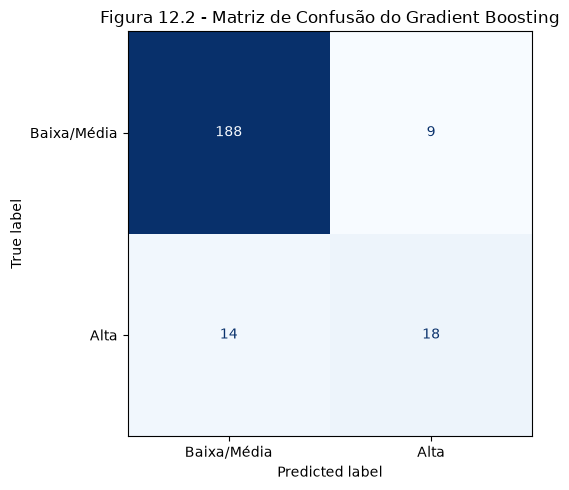

In [224]:
# ==========================================================
# Figura 12.2 - Matriz de Confusão do Gradient Boosting
# ==========================================================

figura, eixo = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_gradient_boosting,

    display_labels=[
        "Baixa/Média",
        "Alta"
    ],

    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

eixo.set_title(
    "Figura 12.2 - Matriz de Confusão do Gradient Boosting"
)

plt.tight_layout()
plt.show()

#### Conclusão

O modelo **Gradient Boosting** apresentou **89,96% de Acurácia, 66,67% de Precisão, 56,25% de Recall e 61,02% de F1-Score**.

Os resultados demonstram que o modelo apresentou bom desempenho geral na classificação dos vinhos. Entretanto, ao considerar especificamente a classe **Alta Qualidade**, observa-se que o Recall de 56,25% indica que uma parcela relevante dos vinhos pertencentes a essa classe ainda não foi corretamente identificada.

Quando comparado ao Random Forest original, que até o momento apresentou o melhor desempenho entre os modelos avaliados, o Gradient Boosting obteve resultados inferiores nas quatro métricas analisadas.

Dessa forma, embora o Gradient Boosting seja uma alternativa válida para o problema de classificação proposto, seus resultados não demonstraram vantagem em relação ao Random Forest original neste conjunto de dados.

O Random Forest permanece, portanto, como o principal candidato à seleção do modelo final, considerando o equilíbrio apresentado entre Acurácia, Precisão, Recall e F1-Score.

### 12.3 Comparação dos Modelos Candidatos

Após o treinamento e a avaliação dos diferentes algoritmos de classificação, os resultados serão consolidados para apoiar a seleção do modelo mais adequado ao problema proposto.

Foram avaliadas quatro abordagens de Machine Learning:

- **Regressão Logística**;
- **K-Nearest Neighbors (KNN)**;
- **Random Forest**;
- **Gradient Boosting**.

Os modelos foram submetidos ao mesmo conjunto de teste e avaliados por meio das métricas de **Acurácia, Precisão, Recall e F1-Score**, permitindo uma comparação consistente entre as diferentes abordagens.

Como a classe **Alta Qualidade** possui menor representatividade no conjunto de dados, a escolha do modelo não será determinada exclusivamente pela Acurácia. Serão considerados também o Recall, a Precisão e, principalmente, o F1-Score, buscando um modelo que apresente bom desempenho geral e equilíbrio na identificação da classe minoritária.

A versão otimizada do Random Forest, avaliada anteriormente, será considerada como um experimento de otimização do algoritmo e não como um modelo independente nesta comparação.

In [225]:
# ==========================================================
# 12.3 Comparação dos Modelos Candidatos
# ==========================================================

# Reúne os resultados dos quatro algoritmos
# avaliados no projeto.
resultados_modelos_finais = {
    "Regressão Logística": resultados_regressao_logistica,
    "KNN": resultados_knn,
    "Random Forest": resultados_random_forest,
    "Gradient Boosting": resultados_gradient_boosting
}


# Cria o DataFrame comparativo.
comparacao_modelos_finais = pd.DataFrame(
    resultados_modelos_finais
)


# Converte os resultados para percentual.
comparacao_modelos_finais = (
    comparacao_modelos_finais * 100
)


# Identifica automaticamente o modelo com
# o maior resultado para cada métrica.
comparacao_modelos_finais["Melhor Modelo"] = (
    comparacao_modelos_finais.idxmax(axis=1)
)


# Transforma o índice em uma coluna
# contendo o nome das métricas.
comparacao_modelos_finais = (
    comparacao_modelos_finais
    .reset_index()
    .rename(
        columns={
            "index": "Métrica"
        }
    )
)


# Exibe a tabela comparativa.
display(
    comparacao_modelos_finais.style
        .hide(axis="index")
        .format({
            "Regressão Logística": "{:.2f}%",
            "KNN": "{:.2f}%",
            "Random Forest": "{:.2f}%",
            "Gradient Boosting": "{:.2f}%"
        })
        .set_caption(
            "Comparação Final dos Modelos de Classificação"
        )
)

Métrica,Regressão Logística,KNN,Random Forest,Gradient Boosting,Melhor Modelo
Acurácia,86.46%,86.46%,92.14%,89.96%,Random Forest
Precisão,52.38%,51.85%,79.17%,66.67%,Random Forest
Recall,34.38%,43.75%,59.38%,56.25%,Random Forest
F1-Score,41.51%,47.46%,67.86%,61.02%,Random Forest


#### Conclusão

A comparação final entre os quatro algoritmos avaliados demonstra que o **Random Forest apresentou o melhor desempenho em todas as métricas analisadas**.

O modelo alcançou **92,14% de Acurácia, 79,17% de Precisão, 59,38% de Recall e 67,86% de F1-Score**, superando Regressão Logística, KNN e Gradient Boosting.

A Regressão Logística e o KNN apresentaram a mesma Acurácia, de 86,46%, porém resultados inferiores nas métricas relacionadas à identificação da classe Alta Qualidade. O Gradient Boosting apresentou desempenho intermediário, com 89,96% de Acurácia e 61,02% de F1-Score, mas também não superou o Random Forest.

A análise é especialmente relevante porque a classe **Alta Qualidade** possui menor representatividade no conjunto de dados. Nesse contexto, o Random Forest não apresentou apenas a maior Acurácia geral, mas também a maior Precisão, Recall e F1-Score para a classe positiva.

Dessa forma, os resultados fornecem evidências para manter o **Random Forest original como principal candidato à seleção do modelo final**.

### 12.4 Seleção do Modelo Final

A seleção do modelo final considera não apenas o desempenho geral dos algoritmos, mas também sua capacidade de identificar corretamente os vinhos pertencentes à classe **Alta Qualidade**.

Foram avaliados quatro algoritmos de classificação: Regressão Logística, KNN, Random Forest e Gradient Boosting. Além disso, foi realizado um experimento de otimização dos hiperparâmetros do Random Forest.

Entre os algoritmos avaliados, o **Random Forest original apresentou o melhor desempenho**, alcançando:

- **Acurácia:** 92,14%;
- **Precisão:** 79,17%;
- **Recall:** 59,38%;
- **F1-Score:** 67,86%.

A otimização do Random Forest demonstrou que é possível aumentar o Recall para 68,75%, ampliando a capacidade de identificar vinhos de Alta Qualidade. Entretanto, essa melhoria foi acompanhada por redução expressiva da Precisão, de 79,17% para 56,41%, e do F1-Score, de 67,86% para 61,97%.

Como o estudo de caso não estabelece que a identificação da classe Alta Qualidade deva priorizar Recall em detrimento das demais métricas, optou-se pelo modelo que apresentou o melhor equilíbrio entre os diferentes critérios de avaliação.

Dessa forma, o **Random Forest original foi selecionado como modelo final** para a classificação da qualidade dos vinhos com base em suas características físico-químicas.

A escolha considera seu desempenho superior no conjunto de teste e o melhor equilíbrio observado entre Acurácia, Precisão, Recall e F1-Score entre os modelos avaliados.

Embora o modelo apresente bom desempenho, o Recall de 59,38% demonstra que ainda existe oportunidade de melhoria na identificação dos vinhos de Alta Qualidade. Em uma aplicação real, a definição do custo associado aos falsos positivos e falsos negativos pelo negócio permitiria ajustar o modelo de acordo com as prioridades da empresa.

## 13. Interpretação do Modelo Final

Após a comparação dos diferentes algoritmos, o **Random Forest original** foi selecionado como modelo final para a classificação da qualidade dos vinhos.

Além de avaliar a capacidade preditiva do modelo, é importante compreender quais características físico-químicas tiveram maior participação em suas decisões.

O Random Forest permite calcular a **importância das variáveis**, indicando quanto cada característica contribuiu para as divisões realizadas pelas árvores que compõem o modelo.

Quanto maior o valor de importância atribuído a uma variável, maior foi sua participação nas decisões utilizadas pelo modelo para classificar os vinhos.

Essa análise não indica, entretanto, se uma característica influencia a qualidade de forma positiva ou negativa. Ela demonstra apenas sua **relevância relativa para as previsões do modelo**.

A interpretação será realizada em três etapas:

1. cálculo da importância das características;
2. análise das variáveis com maior relevância para o modelo;
3. discussão das possíveis implicações para o contexto do negócio.

### 13.1 Importância das Variáveis no Random Forest

Nesta etapa, será analisada a importância atribuída pelo Random Forest a cada uma das características físico-químicas utilizadas na classificação.

O atributo `feature_importances_` do modelo fornece um valor de importância para cada variável explicativa. Esses valores são normalizados e, em conjunto, correspondem a 100% da importância considerada pelo modelo.

As variáveis serão organizadas da maior para a menor importância, facilitando a identificação das características que mais contribuíram para as decisões do Random Forest.

In [226]:
# ==========================================================
# 13.1 Importância das Variáveis no Random Forest
# ==========================================================

# Obtém os valores de importância calculados
# pelo modelo Random Forest selecionado.
importancias_variaveis = (
    modelo_random_forest.feature_importances_
)


# Organiza os nomes das características e seus
# respectivos valores de importância.
tabela_importancia_variaveis = pd.DataFrame({
    "Variável": caracteristicas_treino.columns,
    "Importância": importancias_variaveis
})


# Ordena as características da maior
# para a menor importância.
tabela_importancia_variaveis = (
    tabela_importancia_variaveis
    .sort_values(
        by="Importância",
        ascending=False
    )
    .reset_index(drop=True)
)


# Converte os valores para percentual.
tabela_importancia_variaveis[
    "Importância (%)"
] = (
    tabela_importancia_variaveis[
        "Importância"
    ] * 100
)


# Exibe a tabela formatada.
display(
    tabela_importancia_variaveis[
        [
            "Variável",
            "Importância (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format({
        "Importância (%)": "{:.2f}%"
    })
    .set_caption(
        "Importância das Variáveis no Modelo Random Forest"
    )
)

Variável,Importância (%)
alcohol,16.71%
sulphates,12.10%
volatile acidity,11.56%
citric acid,10.77%
density,9.68%
fixed acidity,7.53%
total sulfur dioxide,7.23%
pH,6.84%
residual sugar,6.25%
chlorides,5.91%


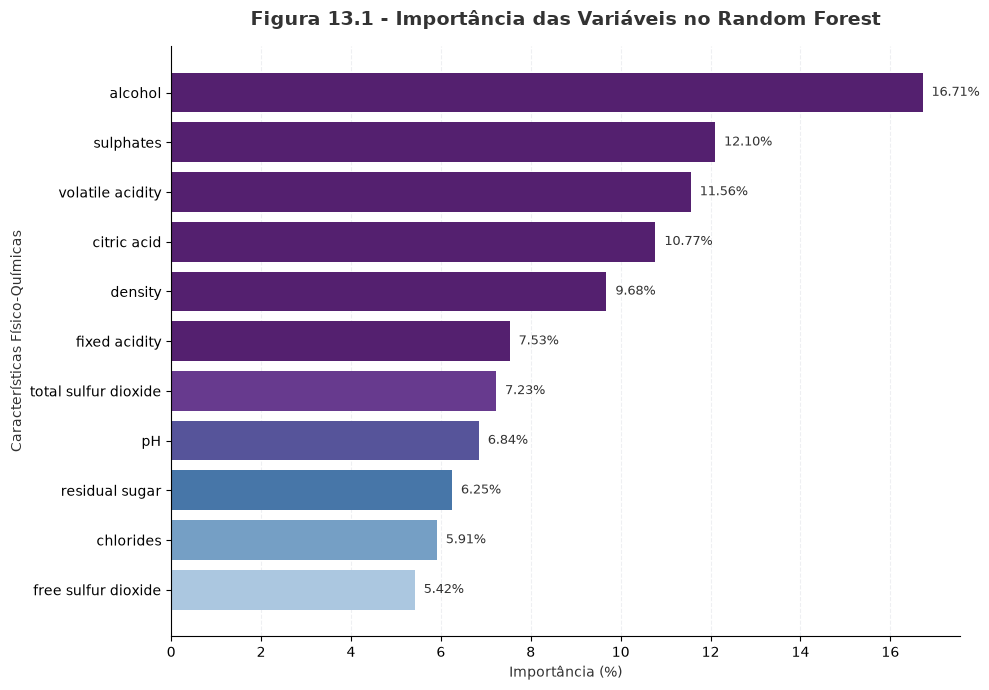

In [227]:
# ==========================================================
# Figura 13.1 - Importância das Variáveis
# ==========================================================

# Cria uma cópia ordenada da tabela
# para utilização no gráfico.
dados_grafico_importancia = (
    tabela_importancia_variaveis
    .sort_values(
        by="Importância (%)",
        ascending=True
    )
)


# Define as cores utilizando a paleta
# visual centralizada no item 2.
cores_barras = [
    PALETA_BARRAS[
        min(
            indice,
            len(PALETA_BARRAS) - 1
        )
    ]
    for indice in range(
        len(dados_grafico_importancia)
    )
]


# Cria a figura.
figura, eixo = plt.subplots(
    figsize=(10, 7)
)


# Cria o gráfico horizontal.
barras = eixo.barh(
    dados_grafico_importancia["Variável"],
    dados_grafico_importancia["Importância (%)"],
    color=cores_barras
)


# Adiciona o percentual ao lado
# de cada barra.
for barra in barras:

    valor = barra.get_width()

    eixo.text(
        valor + 0.2,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=9,
        color=CORES["texto"]
    )


# Define o título.
eixo.set_title(
    "Figura 13.1 - Importância das Variáveis no Random Forest",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"],
    pad=15
)


# Define os títulos dos eixos.
eixo.set_xlabel(
    "Importância (%)",
    color=CORES["texto"]
)

eixo.set_ylabel(
    "Características Físico-Químicas",
    color=CORES["texto"]
)


# Adiciona linhas de apoio.
eixo.grid(
    axis="x",
    linestyle="--",
    alpha=0.30,
    color=CORES["contexto"]
)

eixo.set_axisbelow(True)


# Remove bordas desnecessárias.
eixo.spines["top"].set_visible(False)
eixo.spines["right"].set_visible(False)


# Ajusta os espaçamentos.
plt.tight_layout()


# Exibe o gráfico.
plt.show()

### 13.2 Análise das Principais Variáveis

A análise da importância das características demonstra que algumas variáveis físico-químicas tiveram maior participação nas decisões realizadas pelo modelo Random Forest.

As cinco características com maior importância foram:

- **Alcohol:** 16,71%;
- **Sulphates:** 12,10%;
- **Volatile Acidity:** 11,56%;
- **Citric Acid:** 10,77%;
- **Density:** 9,68%.

Entre elas, o teor alcoólico apresentou a maior importância individual, indicando que essa característica foi utilizada com maior frequência ou relevância nas divisões realizadas pelas árvores que compõem o modelo.

Entretanto, a importância calculada pelo Random Forest representa a contribuição relativa de cada variável para as decisões do modelo e não permite determinar, isoladamente, se valores maiores ou menores de uma característica estão associados à classificação de Alta Qualidade.

Dessa forma, para complementar a interpretação do modelo, será analisada a distribuição das principais características entre as classes **Baixa/Média Qualidade** e **Alta Qualidade**, permitindo observar como seus valores se comportam em cada grupo.

### 13.3 Comportamento das Principais Variáveis por Classe

A análise de importância realizada anteriormente identificou as características físico-químicas que tiveram maior participação nas decisões do Random Forest.

Entretanto, a importância de uma variável não indica a direção de sua relação com a qualidade. Uma característica pode ser relevante para o modelo tanto por apresentar valores maiores quanto menores em determinada classe.

Para complementar essa interpretação, serão analisadas as distribuições das cinco características de maior importância:

- **Alcohol**;
- **Sulphates**;
- **Volatile Acidity**;
- **Citric Acid**;
- **Density**.

A comparação será realizada entre as classes **Baixa/Média Qualidade** e **Alta Qualidade**.

Essa análise permitirá observar diferenças no comportamento das características entre os dois grupos, sem assumir que essas relações representam causalidade.

In [228]:
# ==========================================================
# 13.3 Comportamento das Principais Variáveis por Classe
# ==========================================================

# Seleciona automaticamente as cinco características
# com maior importância para o Random Forest.
principais_variaveis = (
    tabela_importancia_variaveis
    .head(5)["Variável"]
    .tolist()
)


# ----------------------------------------------------------
# RECONSTRUÇÃO DA BASE PARA ANÁLISE
# ----------------------------------------------------------

# Reúne novamente as características de treino e teste.
#
# O objetivo aqui é utilizar todos os registros disponíveis
# para analisar o comportamento das características
# físico-químicas entre as duas classes.
caracteristicas_analise = pd.concat(
    [
        caracteristicas_treino,
        caracteristicas_teste
    ],
    axis=0
)


# Reúne também a variável alvo correspondente
# aos conjuntos de treino e teste.
classe_analise = pd.concat(
    [
        classe_treino,
        classe_teste
    ],
    axis=0
)


# Cria uma base contendo somente as cinco
# características mais importantes.
dados_analise_principais = (
    caracteristicas_analise[
        principais_variaveis
    ]
    .copy()
)


# Adiciona a classificação da qualidade.
dados_analise_principais[
    "classificacao_qualidade"
] = classe_analise


# Substitui os valores numéricos por nomes
# mais intuitivos para apresentação.
dados_analise_principais[
    "Classe de Qualidade"
] = (
    dados_analise_principais[
        "classificacao_qualidade"
    ]
    .map({
        0: "Baixa/Média Qualidade",
        1: "Alta Qualidade"
    })
)


# Exibe as características selecionadas.
print(
    "Características selecionadas para análise:"
)

for variavel in principais_variaveis:
    print(
        f"- {variavel}"
    )

Características selecionadas para análise:
- alcohol
- sulphates
- volatile acidity
- citric acid
- density


In [229]:
# ==========================================================
# Resumo das Principais Variáveis por Classe
# ==========================================================

# Calcula a média das cinco principais características
# separadamente para cada classe de qualidade.
resumo_principais_variaveis = (
    dados_analise_principais
    .groupby(
        "Classe de Qualidade"
    )[principais_variaveis]
    .mean()
    .T
    .reset_index()
)


# Renomeia a coluna das características.
resumo_principais_variaveis = (
    resumo_principais_variaveis
    .rename(
        columns={
            "index": "Variável"
        }
    )
)


# Organiza a ordem das colunas.
resumo_principais_variaveis = (
    resumo_principais_variaveis[
        [
            "Variável",
            "Baixa/Média Qualidade",
            "Alta Qualidade"
        ]
    ]
)


# Exibe a tabela formatada.
display(
    resumo_principais_variaveis.style
        .hide(axis="index")
        .format({
            "Baixa/Média Qualidade": "{:.3f}",
            "Alta Qualidade": "{:.3f}"
        })
        .set_caption(
            "Média das Principais Características por Classe"
        )
)

Variável,Baixa/Média Qualidade,Alta Qualidade
alcohol,10.267,11.528
sulphates,0.643,0.746
volatile acidity,0.553,0.395
citric acid,0.249,0.391
density,0.997,0.996


#### Conclusão

A análise das cinco características mais importantes para o Random Forest mostra diferenças relevantes entre os vinhos classificados como **Baixa/Média Qualidade** e **Alta Qualidade**.

O teor alcoólico apresentou média mais elevada entre os vinhos de Alta Qualidade, passando de **10,267** na classe Baixa/Média para **11,528** na classe Alta. Esse resultado reforça a relevância observada anteriormente para a variável `alcohol`, que apresentou a maior importância no modelo.

A variável `sulphates` também apresentou média superior entre os vinhos de Alta Qualidade, com valor médio de **0,746**, em comparação a **0,643** na classe Baixa/Média.

Em sentido oposto, a `volatile acidity` apresentou média menor entre os vinhos de Alta Qualidade, com **0,395**, enquanto os vinhos de Baixa/Média Qualidade apresentaram média de **0,553**. Essa diferença indica que valores mais baixos dessa característica estão mais presentes no grupo de maior qualidade observado neste conjunto de dados.

O `citric acid` apresentou comportamento semelhante ao teor alcoólico e aos sulfatos, com média superior nos vinhos de Alta Qualidade: **0,391**, em comparação a **0,249** nos demais vinhos.

Já a `density` apresentou médias muito próximas entre as duas classes, de **0,996** para Alta Qualidade e **0,997** para Baixa/Média Qualidade. Embora a variável tenha apresentado importância relevante no Random Forest, a pequena diferença entre as médias indica que sua contribuição pode estar relacionada a combinações, faixas específicas de valores ou interações com outras características, e não apenas à diferença de média entre as classes.

De forma geral, os resultados indicam que, neste conjunto de dados, os vinhos de Alta Qualidade tendem a apresentar **maior teor alcoólico, maiores níveis de sulfatos e ácido cítrico e menor acidez volátil**.

Essas relações são descritivas e associadas aos dados analisados, não devendo ser interpretadas como relações de causa e efeito.

### 13.4 Implicações para o Negócio

Os resultados obtidos demonstram que as características físico-químicas podem ser utilizadas para apoiar a identificação de vinhos com maior probabilidade de pertencer à classe **Alta Qualidade**.

O Random Forest selecionado como modelo final alcançou **92,14% de Acurácia**, além de apresentar o melhor desempenho entre os algoritmos avaliados nas métricas de Precisão, Recall e F1-Score.

A interpretação do modelo mostrou que `alcohol`, `sulphates`, `volatile acidity`, `citric acid` e `density` foram as cinco características com maior importância para suas decisões.

A análise descritiva dessas variáveis também revelou diferenças entre as classes. No conjunto de dados analisado, os vinhos de Alta Qualidade apresentaram, em média, maior teor alcoólico, maiores níveis de sulfatos e ácido cítrico e menor acidez volátil.

Em um contexto empresarial, essas informações podem apoiar o acompanhamento das características físico-químicas dos vinhos e servir como uma ferramenta adicional para identificação de produtos com perfil semelhante aos vinhos classificados como Alta Qualidade.

O modelo pode ser utilizado como um **instrumento de apoio à decisão**, recebendo as características físico-químicas de um vinho e retornando uma classificação estimada entre Baixa/Média Qualidade e Alta Qualidade.

Entretanto, os resultados não devem ser interpretados como regras de produção ou relações de causa e efeito. A importância atribuída às características representa padrões aprendidos pelo modelo a partir dos dados disponíveis.

Além disso, o Recall de **59,38%** para a classe Alta Qualidade demonstra que o modelo ainda deixa de identificar parte dos vinhos pertencentes a essa classe. Dessa forma, sua utilização em um cenário real deve ser complementar à avaliação dos especialistas e acompanhada por monitoramento contínuo de desempenho.

Com a disponibilidade de novos dados de produção e avaliações de qualidade, o modelo poderá ser reavaliado e retreinado periodicamente, permitindo verificar sua capacidade de generalização e buscar melhorias em seu desempenho.

## 14. Conclusão

Este projeto teve como objetivo desenvolver um modelo de classificação capaz de prever a qualidade de um vinho a partir de suas características físico-químicas, transformando a variável de qualidade em um problema de classificação binária:

- **Baixa/Média Qualidade:** nota inferior a 7;
- **Alta Qualidade:** nota igual ou superior a 7.

Ao longo do desenvolvimento, foram realizadas etapas de exploração, preparação e análise dos dados, seguidas pelo treinamento e avaliação de diferentes algoritmos de Machine Learning.

Foram avaliados quatro modelos de classificação:

- **Regressão Logística**;
- **K-Nearest Neighbors (KNN)**;
- **Random Forest**;
- **Gradient Boosting**.

A comparação foi realizada utilizando **Acurácia, Precisão, Recall e F1-Score**, considerando não apenas o desempenho geral dos modelos, mas também sua capacidade de identificar corretamente os vinhos pertencentes à classe Alta Qualidade, que possui menor representatividade no conjunto de dados.

Entre os algoritmos avaliados, o **Random Forest apresentou o melhor desempenho em todas as métricas**, alcançando:

- **Acurácia:** 92,14%;
- **Precisão:** 79,17%;
- **Recall:** 59,38%;
- **F1-Score:** 67,86%.

Também foi realizada uma etapa de otimização do Random Forest. O modelo otimizado aumentou o Recall para **68,75%**, demonstrando maior capacidade de identificar vinhos de Alta Qualidade. Entretanto, esse ganho foi acompanhado por reduções relevantes na Precisão, Acurácia e F1-Score.

Diante desse trade-off, e considerando que o problema de negócio não estabelece um custo específico para falsos positivos e falsos negativos, o **Random Forest original foi selecionado como modelo final**, por apresentar o melhor equilíbrio entre as métricas avaliadas.

A interpretação do modelo mostrou que as características com maior importância para suas decisões foram **alcohol, sulphates, volatile acidity, citric acid e density**.

A análise dessas características revelou ainda que, no conjunto de dados estudado, os vinhos classificados como Alta Qualidade apresentaram, em média, **maior teor alcoólico, maiores níveis de sulfatos e ácido cítrico e menor acidez volátil**. A densidade apresentou valores médios muito próximos entre as duas classes.

Esses resultados demonstram que as características físico-químicas contêm informações relevantes para a classificação da qualidade e podem ser utilizadas na construção de uma ferramenta de apoio à decisão.

Em uma aplicação empresarial, o modelo poderia receber as medições físico-químicas de um vinho e fornecer uma estimativa de sua classificação de qualidade, auxiliando especialistas no acompanhamento e avaliação dos produtos.

Entretanto, o modelo não deve ser interpretado como substituto da avaliação de especialistas. O Recall de 59,38% demonstra que ainda existem vinhos de Alta Qualidade que não são corretamente identificados. Além disso, as relações encontradas representam padrões presentes nos dados analisados e não estabelecem relações de causa e efeito.

Como evolução do projeto, a incorporação de novos dados de produção, o acompanhamento do desempenho do modelo ao longo do tempo e a definição dos custos associados aos diferentes tipos de erro poderão contribuir para novos ajustes e para o desenvolvimento de uma solução ainda mais adequada às necessidades do negócio.

Dessa forma, o projeto demonstra não apenas a viabilidade da aplicação de técnicas de Machine Learning para classificação da qualidade dos vinhos, mas também a importância de avaliar os modelos de forma alinhada ao contexto de negócio, considerando suas métricas, limitações e possibilidades de aplicação.

# Glossário

## A

**Acurácia (Accuracy):** métrica que indica a proporção total de previsões corretas realizadas pelo modelo, considerando todas as classes. Responde a pergunta: **"De todas previsões realizadas quantas o modelo acertou?"

**Assimetria:** medida estatística que indica se os dados estão distribuídos de forma equilibrada ou se há maior concentração de valores em um dos lados da distribuição.

- **Assimetria positiva:** a cauda da distribuição é mais longa à direita, indicando a presença de alguns valores maiores que a maioria.

- **Assimetria negativa:** a cauda da distribuição é mais longa à esquerda, indicando a presença de alguns valores menores que a maioria.

- **Assimetria próxima de zero:** indica uma distribuição aproximadamente simétrica, com os dados distribuídos de forma mais equilibrada em torno da média.

In [230]:
# ==========================================================
# Cálculo das Métricas da Regressão Logística
# ==========================================================

# Importa as métricas utilizadas na avaliação
# de modelos de classificação.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Calcula as métricas de desempenho da Regressão Logística.
resultados_regressao_logistica = {
    "Acurácia": accuracy_score(
        classe_teste,
        previsoes_regressao_logistica
    ),
    "Precisão": precision_score(
        classe_teste,
        previsoes_regressao_logistica
    ),
    "Recall": recall_score(
        classe_teste,
        previsoes_regressao_logistica
    ),
    "F1-Score": f1_score(
        classe_teste,
        previsoes_regressao_logistica
    )
}

In [231]:
import sys
print(sys.executable)

c:\Users\erika\OneDrive\Documents\_Cursos\_DATA_ANALYTICS_FIAP\wine-quality-classification\venv\Scripts\python.exe


In [232]:
# ==========================================================
# Tabela das Métricas
# ==========================================================

# Organiza as métricas em um DataFrame.
tabela_metricas_regressao = pd.DataFrame(
    resultados_regressao_logistica.items(),
    columns=[
        "Métrica",
        "Resultado (%)"
    ]
)

# Converte os resultados para percentual.
tabela_metricas_regressao["Resultado (%)"] = (
    tabela_metricas_regressao["Resultado (%)"] * 100
).round(2)

# Exibe a tabela sem índice numérico.
display(
    tabela_metricas_regressao
        .style
        .hide(axis="index")
)

Métrica,Resultado (%)
Acurácia,86.460000
Precisão,52.380000
Recall,34.380000
F1-Score,41.510000


## C

**Caudas mais pesadas:** indicam que a distribuição possui uma quantidade maior de valores extremos (outliers) quando comparada a uma distribuição Normal.

**Curtose:** medida estatística que indica se os dados possuem muitos ou poucos valores muito distantes da média (valores extremos ou outliers). Ela ajuda a entender o formato da distribuição e a identificar a presença de observações incomuns. Classificações:

- **Mesocúrtica:** distribuição semelhante à distribuição Normal, apresentando uma quantidade esperada de valores extremos (outliers).

- **Leptocúrtica:** distribuição que apresenta maior quantidade de valores extremos (outliers) do que uma distribuição Normal.

- **Platicúrtica:** distribuição que apresenta menor quantidade de valores extremos (outliers) do que uma distribuição Normal.


## D

**Dados faltantes (Missing Values):** Valores que não possuem informação registrada em uma ou mais observações do conjunto de dados. No Pandas, normalmente são representados por `NaN` (Not a Number). Antes da modelagem, é importante verificar sua existência, pois podem impactar o desempenho dos algoritmos de Machine Learning. Em Python, utilizando a biblioteca Pandas, esses valores normalmente são representados por `NaN` (*Not a Number*).
**Sinônimos:**
- Valores faltantes
- Valores ausentes
- Missing values

**Data Leakage (Vazamento de Dados):** Situação em que informações do conjunto de teste ou da variável alvo são utilizadas durante o treinamento do modelo, gerando resultados artificialmente melhores e comprometendo a avaliação do algoritmo.

**Desbalanceamento de classes:** situação em um problema de classificação na qual uma classe possui significativamente mais registros do que outra. Esse desequilíbrio pode fazer com que o modelo favoreça a classe mais frequente, apresentando bom desempenho geral, mas dificuldade para identificar corretamente a classe minoritária.

**Distribuição aproximadamente simétrica:** distribuição em que os dados estão distribuídos de forma equilibrada em torno da média, indicando baixa assimetria.

**Distribuição assimétrica à direita:** distribuição que possui uma cauda mais longa à direita, indicando a presença de alguns valores maiores que a maioria dos dados.

**Distribuição assimétrica à esquerda:** distribuição que possui uma cauda mais longa à esquerda, indicando a presença de alguns valores menores que a maioria dos dados.

## F

**Feature (Variável Explicativa):** Também denominada variável explicativa ou atributo, corresponde a cada informação utilizada pelo modelo de Machine Learning para realizar previsões. Neste projeto, as features representam as características físico-químicas dos vinhos, como acidez, pH, densidade e teor alcoólico.

**F1-score:** métrica que combina Precisão e Recall em um único valor por meio da média harmônica. Um F1-score elevado indica que o modelo apresenta um bom equilíbrio entre encontrar os casos positivos e evitar classificações positivas incorretas.

## K

**KDE (Kernel Density Estimation):** significa *Kernel Density Estimation*, em português **Estimativa de Densidade por Kernel**. É uma técnica estatística utilizada para estimar, de forma suavizada, a distribuição dos dados. É especialmente útil na **Análise Exploratória de Dados (EDA)** para compreender o comportamento de variáveis numéricas contínuas.

* **Curva KDE:** representação gráfica da estimativa produzida pela KDE. A curva facilita a visualização do formato da distribuição, permitindo identificar regiões de maior concentração dos dados, assimetrias e possíveis picos. É frequentemente apresentada em conjunto com histogramas, complementando a análise da distribuição. Apesar de auxiliar na interpretação visual, a curva KDE **não constitui, isoladamente, um teste de normalidade**.


## L

**Leptocúrtica:** distribuição que apresenta maior concentração de valores próximos ao centro e maior presença de valores extremos (outliers) em comparação com uma distribuição Normal.

## M

**Machine Learning (Aprendizado de Máquina):** 
Área da Inteligência Artificial que desenvolve algoritmos capazes de aprender padrões a partir dos dados para realizar previsões ou tomar decisões sem serem explicitamente programados para cada situação.

**Matriz de Confusão:** é uma tabela utilizada para avaliar modelos de classificação, comparando a classe real com a classe prevista pelo modelo. Ela mostra não apenas quantas previsões foram corretas ou incorretas, mas também qual tipo de acerto ou erro ocorreu.

**Média harmônica:** tipo de média que atribui maior impacto aos valores mais baixos. No F1-score, isso significa que uma precisão muito alta não compensa facilmente um recall muito baixo, e vice-versa. Por esse motivo, o F1-score só será elevado quando Precisão e Recall apresentarem conjuntamente bons resultados.

**Métricas de avaliação:** medidas utilizadas para quantificar e analisar o desempenho de um modelo de Machine Learning, permitindo verificar sua capacidade de realizar previsões ou classificações corretamente. Diferentes métricas avaliam diferentes aspectos do desempenho do modelo e devem ser analisadas de acordo com o objetivo do problema.

***Modelo de Classificação:** Algoritmo de Machine Learning cujo objetivo é prever a qual categoria uma observação pertence. Neste projeto, os modelos classificam os vinhos em duas categorias: baixa/média qualidade e alta qualidade.

## N

**NaN (Not a Number):** Representação utilizada pelo Pandas para indicar um valor faltante em um conjunto de dados. Apesar do nome significar "Não é um Número", o NaN é utilizado para representar informações ausentes em variáveis numéricas e, em alguns casos, também em outros tipos de dados.

## P

**Padronização (Standardization):**
Transformação que faz com que as variáveis tenham média igual a zero e desvio padrão igual a um. É frequentemente utilizada para melhorar o desempenho de algoritmos sensíveis à escala das variáveis.

**Platicúrtica:** Distribuição que apresenta menos valores extremos (outliers) do que uma distribuição Normal, resultando em um formato mais espalhado e achatado.

**Precisão (Precision):** Indica, entre os registros que o modelo classificou como pertencentes à classe positiva, quantos realmente pertenciam a essa classe. Responde a pergunta: **"De tudo que o modelo disse ser positivo, quanto realmente era positivo?**

**Predição (Prediction):** Resultado produzido por um modelo de Machine Learning após analisar um conjunto de dados. Neste projeto, corresponde à classificação prevista para cada vinho do conjunto de teste.

**Pré-processamento:** Conjunto de técnicas aplicadas aos dados antes do treinamento dos modelos, incluindo tratamento de dados faltantes, padronização, criação de novas variáveis e preparação dos conjuntos de treino e teste.


## R

**Random Forest:** é um algoritmo de Machine Learning que utiliza várias árvores de decisão. Cada árvore faz sua própria classificação e, no final, o conjunto das árvores determina a previsão do modelo. Combina as decisões de várias árvores para chegar à classificação.

**Recall (Sensibilidade):** indica, entre todos os registros que realmente pertencem à classe positiva, quantos foram corretamente identificados pelo modelo. Responde a pergunta: **"De tudo que realmente era positivo, quanto o modelo conseguiu encontrar?"**

**Regressão Logística:** é um algoritmo de Machine Learning usado principalmente para classificação. É usada para classificar uma observação em uma categoria, e para isso ela primeiro estima probabilidades. Ou seja, estimar a probabilidade de pertencer a uma classe e, a partir dela, realizar uma classificação. E, ela também pode trabalhar com mais de duas classes (classificação multiclasse), não apenas 0 e 1.

**Relação Linear:** acontece quando a mudança de uma variável está associada a uma mudança relativamente constante em outra.

**Relação não linear:** relação entre variáveis na qual uma mudança em uma característica não produz necessariamente um efeito constante ou proporcional no resultado. O efeito pode variar conforme o valor da própria variável ou sua interação com outras características.

## S

**Scikit-Learn:** Biblioteca de código aberto da linguagem Python amplamente utilizada em projetos de Ciência de Dados e Machine Learning. Disponibiliza algoritmos de classificação, regressão, agrupamento, pré-processamento, avaliação de modelos e diversas ferramentas para construção de pipelines de aprendizado de máquina.

Neste projeto, o Scikit-Learn será utilizado para realizar o pré-processamento dos dados, dividir os conjuntos de treino e teste, treinar os modelos de classificação e avaliar seu desempenho.


**Split (Divisão dos Dados):** Em Machine Learning, **split** é o termo utilizado para representar a divisão do conjunto de dados em subconjuntos com finalidades distintas.

Neste projeto, foi realizado um **train-test split**, separando:
- **80%** dos registros para treinamento dos modelos (*conjunto de treino*);
- **20%** dos registros para avaliação (*conjunto de teste*).

Essa estratégia permite que o desempenho dos modelos seja avaliado utilizando dados que não participaram do processo de treinamento, reduzindo o risco de superestimar sua capacidade de generalização.

## T

**Target (Variável Alvo):** É a variável que o modelo de Machine Learning deve aprender a prever. Neste projeto, a variável alvo é `quality_label`, responsável por classificar os vinhos em baixa/média ou alta qualidade.

**Trade-off:** situação em que a melhora de um aspecto do modelo ocorre acompanhada da piora de outro. Na modelagem, representa uma relação de compromisso entre diferentes objetivos ou métricas.

**Treinamento (Training):** Etapa em que o algoritmo aprende os padrões existentes nos dados de treino, ajustando seus parâmetros internos para realizar previsões sobre novos dados.

## V 

**Variável alvo (Target)**:É a variável que o modelo de Machine Learning deve aprender a prever. Neste projeto, a variável alvo é `quality_label`, que classifica os vinhos em alta ou baixa/média qualidade.


**Variáveis explicativas:** são as características ou informações utilizadas para ajudar um modelo a prever ou explicar um resultado. Também são conhecidas como variáveis independentes, preditoras ou features. No contexto deste projeto, exemplos de variáveis explicativas são: acidez fixa, teor alcoólico, pH e densidade, que são utilizadas para prever a qualidade do vinho.